# Loading and prepping self other X and Y 

In [9]:
!hostnamectl

   Static hostname: (unset)                                 
Transient hostname: bc11u11n1
         Icon name: computer-server
           Chassis: server 🖳
        Machine ID: a46c2acfd59f4908bc8cf0f3bd99bde4
           Boot ID: c10248eb91664fd880070e1b43a63629
  Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
       CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
            Kernel: Linux 5.14.0-427.13.1.el9_4.x86_64
      Architecture: x86-64
   Hardware Vendor: HPE
    Hardware Model: ProLiant XL190r Gen10
  Firmware Version: U38


In [2]:
from joblib import delayed, Parallel
import warnings
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.simplefilter("ignore", PerfectSeparationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerfectSeparationWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [3]:
# === Loading and dim reducing embeddings=== 

import pandas as pd
import numpy as np
import ast
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def load_and_reduce_embeddings(embedding_csv_path, n_components=100):
    df = pd.read_csv(embedding_csv_path)
    df['Parsed_Embedding'] = df['Embedding'].apply(ast.literal_eval)
    embedding_matrix = np.array(df['Parsed_Embedding'].tolist())

    if 'onset' in df.columns:
        df = df.sort_values(by='onset').reset_index(drop=True)

    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(embedding_matrix)
    pcs_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(n_components)])

    return df.reset_index(drop=True), pcs_df

# def load_and_reduce_embeddings(embedding_csv_path, n_components=100):
#     # Load CSV with fallback engine and handle malformed lines
#     try:
#         df = pd.read_csv(embedding_csv_path, engine='python', on_bad_lines='warn')
#     except Exception as e:
#         print(f"❌ Failed to read embedding file: {embedding_csv_path}")
#         raise e

#     # Parse embedding strings safely
#     if 'Embedding' not in df.columns:
#         raise ValueError("❌ 'Embedding' column missing from embedding CSV")

#     df['Parsed_Embedding'] = df['Embedding'].apply(ast.literal_eval)
#     embedding_matrix = np.array(df['Parsed_Embedding'].tolist())

#     # Sort by onset time if present
#     if 'onset' in df.columns:
#         df = df.sort_values(by='onset').reset_index(drop=True)

#     # Standardize speaker column if present
#     if 'Speaker' in df.columns:
#         df['Speaker'] = df['Speaker'].astype(str).str.extract(r'(SPK\d+)', expand=False)

#     # Dimensionality reduction
#     pca = PCA(n_components=n_components)
#     pcs = pca.fit_transform(embedding_matrix)
#     pcs_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(n_components)])

#     return df.reset_index(drop=True), pcs_df



def build_feature_matrix(pcs_df, df_metadata, duration_file, target_speaker="SPK1"):
    if duration_file.endswith(".xlsx"):
        durations_df = pd.read_excel(duration_file)
    else:
        durations_df = pd.read_csv(duration_file)

    durations_df = durations_df.reset_index(drop=True)
    durations = durations_df.loc[df_metadata.index, 'regress_dur'].reset_index(drop=True)
    # durations = durations_df.loc[df_metadata.index, 'Duration'].reset_index(drop=True)   

    if target_speaker is not None:
        mask = df_metadata['Speaker'] == target_speaker
    else:
        mask = df_metadata['Speaker'] != "SPK1"

    pcs_sub = pcs_df[mask.values].reset_index(drop=True)
    durations_sub = durations[mask.values].reset_index(drop=True)

    if pcs_sub.shape[0] != durations_sub.shape[0]:
        raise ValueError(f"Row mismatch: {pcs_sub.shape[0]} PCs vs {durations_sub.shape[0]} durations")

    pcs = pcs_sub.values
    durations_arr = durations_sub.values.reshape(-1, 1)
    interactions = pcs * durations_arr
    X_full = np.hstack([pcs, durations_arr, interactions])

    if X_full.shape[0] == 0:
        raise ValueError("No samples found for selected speaker subset (likely a mismatch in Speaker labels).")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_full)
    return X_scaled

def split_feature_matrices(embedding_csv_path, duration_csv_path, n_components=100, target_speaker="SPK1"):
    df_metadata, pcs_df = load_and_reduce_embeddings(embedding_csv_path, n_components)
    X_self = build_feature_matrix(pcs_df, df_metadata, duration_csv_path, target_speaker=target_speaker)
    X_other = build_feature_matrix(pcs_df, df_metadata, duration_csv_path, target_speaker=None)
    return X_self, X_other, df_metadata


def build_Y_matrices(df_metadata, spike_data, regions, target_speaker="SPK1"):
    speakers_in_data = list(spike_data.keys())
    speaker_tag_map = {f"SPK{spk.replace('Speaker','').strip()}": spk.strip() for spk in speakers_in_data}


    region_Ys = {}

    for region in regions:
        print(f"\n🔍 Processing region: {region}")
        Y_self, Y_other = [], []
        W_self, W_other = [], []

        kept_self_indices = []
        kept_other_indices = []

        speaker_counters = {spk: 0 for spk in speakers_in_data}

        for idx, row in df_metadata.iterrows():
            spk = row['Speaker']
            word = row['Word']
            speaker_name = speaker_tag_map.get(spk)

            if speaker_name is None or region not in spike_data[speaker_name]:
                continue

            current_idx = speaker_counters[speaker_name]
            max_rows = spike_data[speaker_name][region].shape[0]

            if current_idx >= max_rows:
                continue

            row_data = spike_data[speaker_name][region][current_idx, :]

            if spk == target_speaker:
                Y_self.append(row_data)
                W_self.append(word)
                kept_self_indices.append(idx)
            else:
                Y_other.append(row_data)
                W_other.append(word)
                kept_other_indices.append(idx)

            speaker_counters[speaker_name] += 1

        print(f"✅ Y_self rows: {len(Y_self)}")
        print(f"✅ Y_other rows: {len(Y_other)}")

        region_Ys[region] = {
            'self': np.vstack(Y_self) if Y_self else np.empty((0,)),
            'other': np.vstack(Y_other) if Y_other else np.empty((0,)),
            'word_ref_self': W_self,
            'word_ref_other': W_other,
            'indices_self': kept_self_indices,
            'indices_other': kept_other_indices
        }

    return region_Ys


def get_self_and_other_features(embedding_file, duration_file, n_components=100, target_speaker="SPK1"):
    df_metadata, pcs_df = load_and_reduce_embeddings(embedding_file, n_components)
    print(f"✅ EMBEDDING CSV rows: {len(df_metadata)} unique words")
    print("✅ Speakers in CSV:", df_metadata['Speaker'].unique())
    # Make sure durations match the original metadata
    if duration_file.endswith(".xlsx"):
        durations_df = pd.read_excel(duration_file)
    else:
        durations_df = pd.read_csv(duration_file)
    print(f"✅ DURATION file rows: {len(durations_df)}")
    durations_df = durations_df.reset_index(drop=True)
    df_metadata = df_metadata.reset_index(drop=True)

    # Attach duration column
    # df_metadata["Duration"] = durations_df["Duration"]
    df_metadata["regress_dur"] = durations_df["regress_dur"]
    # Separate
    mask_self = df_metadata['Speaker'] == target_speaker
    mask_other = df_metadata['Speaker'] != target_speaker

    # Filter everything
    pcs_self = pcs_df[mask_self].reset_index(drop=True)
    pcs_other = pcs_df[mask_other].reset_index(drop=True)
    # dur_self = df_metadata.loc[mask_self, "Duration"].reset_index(drop=True)
    # dur_other = df_metadata.loc[mask_other, "Duration"].reset_index(drop=True)
    dur_self = df_metadata.loc[mask_self, "regress_dur"].reset_index(drop=True)
    dur_other = df_metadata.loc[mask_other, "regress_dur"].reset_index(drop=True)

    words_self = df_metadata.loc[mask_self, "Word"].reset_index(drop=True)
    words_other = df_metadata.loc[mask_other, "Word"].reset_index(drop=True)

    # Build final matrices
    X_self = build_feature_matrix_core(pcs_self, dur_self)
    X_other = build_feature_matrix_core(pcs_other, dur_other)

    return X_self, X_other, df_metadata, words_self, words_other


def build_feature_matrix_core(pcs_df, durations):
    pcs = pcs_df.values
    durations_arr = durations.values.reshape(-1, 1)
    interactions = pcs * durations_arr
    X_full = np.hstack([pcs, durations_arr, interactions])

    if X_full.shape[0] == 0:
        raise ValueError("No samples found for selected speaker subset.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_full)
    return X_scaled



Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [4]:
# neural_rate_loader.py (Flexible for *_spike_sum.npy or *_spike_rates.npy)
import os
import numpy as np
#very olde version
# def load_spike_data(base_output_dir, speakers, regions):
#     """
#     Load spike count matrices for each speaker and region.

#     Tries flexible file naming:
#     - "{region}_spike_rates.npy"
#     - "{region}_spikes_rates.npy"
#     - "{region}_spike_sum.npy"

#     Returns:
#         dict[speaker][region] = np.array (neurons x time/trials)
#     """
#     spike_data = {}
#     base_dirs = os.listdir(base_output_dir)

#     for speaker in speakers:
#         speaker_folder = next((f for f in base_dirs if f.strip().lower() == speaker.strip().lower()), None)
#         if not speaker_folder:
#             print(f"[WARN] Folder not found for speaker {speaker}")
#             continue

#         speaker_path = os.path.join(base_output_dir, speaker_folder)
#         spike_data[speaker] = {}

#         for region in regions:
#             region_variants = [region, region.upper(), region.lower()]
#             matched = False
#             for variant in region_variants:
#                 file_candidates = [
#                     os.path.join(speaker_path, f"{variant}_spike_counts_shift-150.npy"),
#                     # os.path.join(speaker_path, f"{variant}_spike_rates.npy"),
#                     # os.path.join(speaker_path, f"{variant}_spikes_rates.npy")
#                 ]
#                 for file_path in file_candidates:
#                     if os.path.exists(file_path):
#                         spike_data[speaker][region] = np.load(file_path)
#                         print(f"Loaded {speaker} - {region}: {spike_data[speaker][region].shape} from {os.path.basename(file_path)}")
#                         matched = True
#                         break
#                 if matched:
#                     break
#             if not matched:
#                 print(f"[WARN] No spike file found for {speaker} - {region}")

#     return spike_data
 #version from JUl 8 

# def load_spike_data(speakers, regions,
#                     self_base_dir, other_base_dir,
#                     self_shift_tag, other_shift_tag,
#                     target_speaker="Speaker1"):
#     """
#     Load spike count matrices for each speaker and region.
#     Uses different base directories and shift tags for self vs. other speakers.
#     """

#     spike_data = {}

#     for speaker in speakers:
#         if speaker == target_speaker:
#             base_dir = self_base_dir
#             shift_tag = self_shift_tag
#         else:
#             base_dir = other_base_dir
#             shift_tag = other_shift_tag

#         # Check if speaker folder exists
#         try:
#             all_speaker_folders = os.listdir(base_dir)
#         except FileNotFoundError:
#             print(f"[ERROR] Base dir not found: {base_dir}")
#             continue

#         speaker_folder = next(
#             (f for f in all_speaker_folders if f.strip().lower() == speaker.strip().lower()),
#             None
#         )
#         if not speaker_folder:
#             print(f"[WARN] Folder not found for speaker {speaker} in {base_dir}")
#             continue

#         speaker_path = os.path.join(base_dir, speaker_folder)
#         spike_data[speaker] = {}

#         for region in regions:
#             region_variants = [region, region.upper(), region.lower()]
#             matched = False
#             for variant in region_variants:
#                 file_name = f"{variant}_spike_counts_shift{shift_tag}.npy"
#                 file_path = os.path.join(speaker_path, file_name)
#                 if os.path.exists(file_path):
#                     spike_data[speaker][region] = np.load(file_path)
#                     print(f"✅ Loaded {speaker} - {region}: {spike_data[speaker][region].shape} from {file_name}")
#                     matched = True
#                     break
#             if not matched:
#                 print(f"[WARN] No spike file found for {speaker} - {region} in {speaker_path}")

#     return spike_data

def load_spike_data(speakers, regions,
                    self_base_dir, other_base_dir=None,
                    self_shift_tag=None, other_shift_tag=None,
                    target_speaker="Speaker1",
                    mode="split"):
    """
    Load spike count matrices for each speaker and region.
    
    Modes:
        - "split": self and other speakers come from different base dirs, need shift tags
        - "unified": same base dir, but different shift tags for self vs. other
        - "auto": same base dir for all, no shift tag used (just grab whatever is in folder)
    """
    import os
    import numpy as np

    spike_data = {}

    for speaker in speakers:
        if mode == "split":
            if speaker == target_speaker:
                base_dir = self_base_dir
                shift_tag = self_shift_tag
            else:
                base_dir = other_base_dir
                shift_tag = other_shift_tag

        elif mode == "unified":
            base_dir = self_base_dir
            shift_tag = self_shift_tag if speaker == target_speaker else other_shift_tag

        elif mode == "auto":
            base_dir = self_base_dir
            shift_tag = None  # Ignore shift tag entirely

        else:
            raise ValueError(f"Invalid mode '{mode}'. Choose 'split', 'unified', or 'auto'.")

        # Check if speaker folder exists
        try:
            all_speaker_folders = os.listdir(base_dir)
        except FileNotFoundError:
            print(f"[ERROR] Base dir not found: {base_dir}")
            continue

        speaker_folder = next(
            (f for f in all_speaker_folders if f.strip().lower() == speaker.strip().lower()),
            None
        )
        if not speaker_folder:
            print(f"[WARN] Folder not found for speaker {speaker} in {base_dir}")
            continue

        speaker_path = os.path.join(base_dir, speaker_folder)
        spike_data[speaker] = {}

        for region in regions:
            region_variants = [region, region.upper(), region.lower()]
            matched = False

            if mode in ["split", "unified"]:
                # Strict file naming with shift tag
                for variant in region_variants:
                    file_name = f"{variant}_spike_counts_shift{shift_tag}.npy"
                    file_path = os.path.join(speaker_path, file_name)
                    if os.path.exists(file_path):
                        spike_data[speaker][region] = np.load(file_path)
                        print(f"✅ Loaded {speaker} - {region}: {spike_data[speaker][region].shape} from {file_name}")
                        matched = True
                        break

            elif mode == "auto":
                # Looser: load *any* .npy for this region in this speaker folder
                for variant in region_variants:
                    candidates = [f for f in os.listdir(speaker_path) if f.startswith(variant) and f.endswith('.npy')]
                    if candidates:
                        file_path = os.path.join(speaker_path, candidates[0])
                        spike_data[speaker][region] = np.load(file_path)
                        print(f"✅ Auto-loaded {speaker} - {region}: {spike_data[speaker][region].shape} from {candidates[0]}")
                        matched = True
                        break

            if not matched:
                print(f"[WARN] No spike file found for {speaker} - {region} in {speaker_path}")

    return spike_data



# Loading the data

In [19]:
# === Configuration ===
embedding_file = "/projects/bhayden/anilu/Language_docs/Regression/PTYFC_task28_words_english_only/PTYFC_task28_aligned_embeddings_withNP.csv"
# duration_file  = "/projects/bhayden/anilu/Language_docs/Regression/May2025_Spikes_words_BERT/output_ptYFC_task28_english_only_dur/ptYFC_task028_with_regress_dur.xlsx"
# spike_base_dir = "/projects/bhayden/anilu/Language_docs/Regression/May2025_Spikes_words_BERT/output_ptYFC_task28_english_only_dur/"

duration_file  = "/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYFC_task28_english_only_dur_150_200_500/ptYFC_task28_with_regress_dur.xlsx"
spike_base_dir = "/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYFC_task28_english_only_dur_150_200_500/"
# === Configuration ===
# patient_ID = "PTYFG_task18"
# patient = "ptYFG_task18"

# embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_aligned_embeddings_withNP.csv"

# duration_file = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_{patient}_english_only_dur/{patient}_with_regress_dur.xlsx"
# spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_{patient}_english_only_dur/"

# embedding_file="projects/bhayden/anilu/Language_docs/Regression/final_word2vec/PTYFG_task18_words_word2vec/PTYFG_task18_aligned_word2vec_embeddings.csv"
# duration_file="projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_ptYFG_task18_english_only_w2v/ptYFG_task18_with_regress_dur.xlsx"
# spike_base_dir="projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_ptYFG_task18_english_only_w2v/"
# === Configuration ===
# embedding_file = "/scratch/agc10/LanguageRegressions/DataBert/Final_words_english_only_BERT/PTYEU_task147_words_english_only/PTYEU_task147_aligned_embeddings_withNP.csv"

# duration_file = "/scratch/agc10/LanguageRegressions/DataBert/SpikeOutputs/output_PTYEU_task147_english_only_shiftp0ms/ptYEU_task147_with_regress_dur_shiftp0ms.xlsx"

# # Speaker-specific base dirs
# self_base_dir = "/scratch/agc10/LanguageRegressions/DataBert/SpikeOutputs/output_PTYEU_task147_english_only_shiftp0ms"
# other_base_dir = "/scratch/agc10/LanguageRegressions/DataBert/SpikeOutputs/output_PTYEU_task147_english_only_shiftp200ms"

# # Shift tags for file naming
# self_shift_tag = "0"
# other_shift_tag = "200"

# Other settings
speakers = ["Speaker1", "Speaker2", "Speaker3", "Speaker4", "Speaker5", "Speaker6", "Speaker7", "Speaker8","Speaker9","Speaker10","Speaker11","Speaker12"]
regions = ["hippocampus","ACC"] #"ACC"
target_speaker = "SPK1"
n_components=10

X_self, X_other, df_metadata, X_words_self, X_words_other = get_self_and_other_features(
    embedding_file,
    duration_file,
    n_components=n_components,
    target_speaker=target_speaker
)

print("X_self shape:", X_self.shape)
print("X_other shape:", X_other.shape)
print("X_words_SELF:", X_words_self)
print("X_words_OTHER:", X_words_other)


✅ EMBEDDING CSV rows: 3541 unique words
✅ Speakers in CSV: ['SPK2' 'SPK1' 'SPK5' 'SPK3' 'SPK4' 'SPK6']
✅ DURATION file rows: 3541
X_self shape: (1204, 21)
X_other shape: (2337, 21)
X_words_SELF: 0              Some
1              were
2       interesting
3                Uh
4               the
           ...     
1199          Hello
1200           Good
1201             to
1202            see
1203            you
Name: Word, Length: 1204, dtype: object
X_words_OTHER: 0               Um
1            hello
2            could
3               we
4             come
           ...    
2332       surgery
2333           And
2334    everything
2335          went
2336         great
Name: Word, Length: 2337, dtype: object


In [20]:
# spike_data = load_spike_data(
#     speakers=speakers,
#     regions=regions,
#     self_base_dir=self_base_dir,
#     other_base_dir=other_base_dir,
#     self_shift_tag=self_shift_tag,
#     other_shift_tag=other_shift_tag,
#     target_speaker="Speaker1"  # here match the speaker folder names
# )
spike_data = load_spike_data(
    speakers=speakers,
    regions=regions,
    self_base_dir=spike_base_dir,
    mode="auto"
)

region_Ys = build_Y_matrices(
    df_metadata,
    spike_data,
    regions,
    target_speaker="SPK1"
)

Y_self_ACC = region_Ys["ACC"]["self"]
Y_other_ACC = region_Ys["ACC"]["other"]

Y_self_hippo = region_Ys["hippocampus"]["self"]
Y_other_hippo = region_Ys["hippocampus"]["other"]

print("Y_self_ACC shape:", Y_self_ACC.shape)
print("Y_other_ACC shape:", Y_other_ACC.shape)

print("Y_self_hippo shape:", Y_self_hippo.shape)
print("Y_other_hippo shape:", Y_other_hippo.shape)


✅ Auto-loaded Speaker1 - hippocampus: (1204, 34) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker1 - ACC: (1204, 31) from ACC_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (2081, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - ACC: (2081, 31) from ACC_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (31, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - ACC: (31, 31) from ACC_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (77, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - ACC: (77, 31) from ACC_spike_rates.npy
✅ Auto-loaded Speaker5 - hippocampus: (107, 34) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker5 - ACC: (107, 31) from ACC_spike_sum.npy
✅ Auto-loaded Speaker6 - hippocampus: (44, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker6 - ACC: (44, 31) from ACC_spike_rates.npy
[WARN] Folder not found for speaker Speaker7 in /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output

# Checking for any nans or cleaning overall before feeding to regression

In [21]:
print("\n✅ Checking and cleaning NaNs in all X/Y conditions (joint dropping)...\n")

for region in regions:
    for condition in ["self", "other"]:
        print(f"🔎 {region} - {condition}")

        # Select X
        if condition == "self":
            X = X_self
        else:
            X = X_other

        Y = region_Ys[region][condition]

        # Sanity shape check
        if X.shape[0] != Y.shape[0]:
            print(f"⚠️  Skipping {region}_{condition}: shape mismatch before cleaning (X={X.shape[0]}, Y={Y.shape[0]})")
            continue

        # Create joint mask
        nan_mask_X = np.isnan(X).any(axis=1)
        nan_mask_Y = np.isnan(Y).any(axis=1)
        joint_mask = ~(nan_mask_X | nan_mask_Y)

        n_before = X.shape[0]
        n_after = joint_mask.sum()
        n_dropped = n_before - n_after

        if n_dropped > 0:
            print(f"⚠️  Dropping {n_dropped} rows with NaNs in X or Y")
        else:
            print(f"✅ No NaNs detected")

        # Apply joint mask to both
        X_clean = X[joint_mask]
        Y_clean = Y[joint_mask]

        # Save back
        if condition == "self":
            if region == "ACC":
                X_self_ACC_clean = X_clean
            elif region == "hippocampus":
                X_self_hippo_clean = X_clean
        else:
            if region == "ACC":
                X_other_ACC_clean = X_clean
            elif region == "hippocampus":
                X_other_hippo_clean = X_clean

        region_Ys[region][condition] = Y_clean

        print(f"✅ Cleaned shapes: X={X_clean.shape}, Y={Y_clean.shape}\n")



✅ Checking and cleaning NaNs in all X/Y conditions (joint dropping)...

🔎 hippocampus - self
✅ No NaNs detected
✅ Cleaned shapes: X=(1204, 21), Y=(1204, 34)

🔎 hippocampus - other
⚠️  Dropping 1 rows with NaNs in X or Y
✅ Cleaned shapes: X=(2336, 21), Y=(2336, 34)

🔎 ACC - self
✅ No NaNs detected
✅ Cleaned shapes: X=(1204, 21), Y=(1204, 31)

🔎 ACC - other
⚠️  Dropping 1 rows with NaNs in X or Y
✅ Cleaned shapes: X=(2336, 21), Y=(2336, 31)



# Running regression (legacy)

In [9]:
def run_poisson_ridge(
    X, Y,
    patient_id,
    neuron_idx,
    region_name,
    n_semantic_dims,
    results_dir="/projects/bhayden/anilu/Language_docs/RegressionRESULTS",
    n_iterations=10,
    test_size=0.3,
    use_clusters=False,
    fast_beta_only=False,
    save_results=True,
):
    import os
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import PoissonRegressor
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import r2_score
    from scipy.stats import pearsonr
    from scipy.special import gammaln
    import statsmodels.api as sm
    import warnings
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    from sklearn.exceptions import ConvergenceWarning

    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.simplefilter("ignore", PerfectSeparationWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=PerfectSeparationWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    if use_clusters:
        results_dir = os.path.join(results_dir, "clusterwise")
    else:
        results_dir = os.path.join(results_dir, "allwords")
    
    output_dir = None
    if save_results:
        output_dir = os.path.join(results_dir, f"{patient_id}_{region_name}")
        os.makedirs(output_dir, exist_ok=True)

    n_words, n_neurons = Y.shape
    y = Y[:, neuron_idx]
    n_predictors = X.shape[1]

    # print(f"✅ Detected {n_semantic_dims} semantic embedding dimensions (excluding duration/interactions)")

    all_results = []
    significant_predictors = []
    summary_predictors = []
    ridge_coeff_accumulator = {neuron_idx: []}
    ridge_support_flags = {neuron_idx: set()}

    y_true_all = []
    y_pred_all = []
    train_lls = []
    test_lls = []
    train_corrs = []
    test_corrs = []

    y = Y[:, neuron_idx]
    neuron_predictor_records = []

    # # === Define your alpha grid
    # param_grid = {
    #     'alpha': np.unique(np.concatenate([
    #         [0.1],
    #         np.logspace(0, 2.5, 10),
    #         [1000.0],
    #         np.logspace(-2, 4, 20)
    #     ]))
    # }
    param_grid = {'alpha': np.logspace(-3, 3, 30)}

    model = PoissonRegressor(max_iter=1000)
    grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_poisson_deviance', n_jobs=1)
    grid.fit(X, y)
    best_alpha = grid.best_params_['alpha']
    print(f"✅ Best alpha selected: {best_alpha}")

    if fast_beta_only:
        final_model = PoissonRegressor(alpha=best_alpha, max_iter=1000)
        final_model.fit(X, y)
        coefs = final_model.coef_
        coef_df = pd.DataFrame([coefs], columns=[f"beta_{i}" for i in range(len(coefs))])
        coef_df.insert(0, "neuron", neuron_idx)
        coef_df.insert(1, "region", region_name)
        return coef_df

    for iter_idx in range(n_iterations):
        adaptive_test_size = test_size
        split_point = int((1 - adaptive_test_size) * n_words)
        offset = (iter_idx * int(n_words * adaptive_test_size)) % n_words
        idx_range = np.roll(np.arange(n_words), -offset)
        train_idx = idx_range[:split_point]
        test_idx = idx_range[split_point:]

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        n, k = len(y_test), X_test.shape[1]
        if k >= n - 1:
            adaptive_test_size = 0.4
            split_point = int((1 - adaptive_test_size) * n_words)
            offset = (iter_idx * int(n_words * adaptive_test_size)) % n_words
            idx_range = np.roll(np.arange(n_words), -offset)
            train_idx = idx_range[:split_point]
            test_idx = idx_range[split_point:]
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]
            n, k = len(y_test), X_test.shape[1]

        # === Real model
        ridge_model = PoissonRegressor(alpha=best_alpha, max_iter=1000)
        ridge_model.fit(X_train, y_train)
        pred_train = np.clip(ridge_model.predict(X_train), 1e-10, None)
        pred_test = np.clip(ridge_model.predict(X_test), 1e-10, None)

        ll_train = np.sum(y_train * np.log(pred_train) - pred_train - gammaln(y_train + 1))
        ll_real = np.sum(y_test * np.log(pred_test) - pred_test - gammaln(y_test + 1))
        r_train, _ = pearsonr(y_train, pred_train)
        r_test, corr_p = pearsonr(y_test, pred_test)
        r2 = r2_score(y_test, pred_test)
        adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - k - 1) if n > k + 1 else r2

        y_true_all.extend(y_test)
        y_pred_all.extend(pred_test)
        train_lls.append(ll_train)
        test_lls.append(ll_real)
        train_corrs.append(r_train)
        test_corrs.append(r_test)
        ridge_coeff_accumulator[neuron_idx].append(ridge_model.coef_)

        # === Y-shuffled null model
        y_train_shuf = np.random.permutation(y_train)
        null_model = PoissonRegressor(alpha=best_alpha, max_iter=1000)
        null_model.fit(X_train, y_train_shuf)
        null_pred = np.clip(null_model.predict(X_test), 1e-10, None)
        ll_shuf = np.sum(y_test * np.log(null_pred) - null_pred - gammaln(y_test + 1))
        corr_shuf, corr_p_shuf = pearsonr(y_test, null_pred)
        r2_shuf = r2_score(y_test, null_pred)
        adj_r2_shuf = 1 - ((1 - r2_shuf) * (n - 1)) / (n - k - 1) if n > k + 1 else r2_shuf
        ll_diff = ll_real - ll_shuf

        # === X-shuffled null model (only shuffling semantic embeddings)
        X_train_shuf = X_train.copy()
        X_test_shuf = X_test.copy()
        for col in range(n_semantic_dims):
            np.random.shuffle(X_train_shuf[:, col])
            np.random.shuffle(X_test_shuf[:, col])

        xshuf_model = PoissonRegressor(alpha=best_alpha, max_iter=1000)
        xshuf_model.fit(X_train_shuf, y_train)
        pred_xshuf = np.clip(xshuf_model.predict(X_test_shuf), 1e-10, None)
        ll_xshuf = np.sum(y_test * np.log(pred_xshuf) - pred_xshuf - gammaln(y_test + 1))
        ll_diff_xshuf = ll_real - ll_xshuf

        # === Record results
        all_results.append({
            'neuron': neuron_idx,
            'iteration': iter_idx,
            'best_alpha': best_alpha,
            'll_real': ll_real,
            'll_shuf': ll_shuf,
            'll_diff': ll_diff,
            'll_xshuf': ll_xshuf,
            'll_diff_xshuf': ll_diff_xshuf,
            'adj_r2': adj_r2,
            'adj_r2_shuf': adj_r2_shuf,
            'corr': r_test,
            'corr_p': corr_p,
            'corr_shuf': corr_shuf,
            'corr_p_shuf': corr_p_shuf
        })

        try:
            glm = sm.GLM(y_train, X_train, family=sm.families.Poisson())
            result = glm.fit()
            for idx, (coef, pval) in enumerate(zip(result.params, result.pvalues)):
                if pval < 0.05:
                    ridge_support_flags[neuron_idx].add(idx)
                    significant_predictors.append({
                        'neuron': neuron_idx,
                        'iteration': iter_idx,
                        'predictor_index': idx,
                        'coefficient': coef,
                        'p_value': pval
                    })
                neuron_predictor_records.append((idx, coef, pval))
        except:
            continue

    # === Post-processing results
    df_neuron = pd.DataFrame(neuron_predictor_records, columns=['predictor_index', 'coefficient', 'p_value'])
    grouped = df_neuron.groupby('predictor_index')
    mean_ridge_coef = np.mean(ridge_coeff_accumulator[neuron_idx], axis=0)

    for pred_idx, group in grouped:
        median_p = group['p_value'].median()
        if median_p < 0.05:
            ridge_support = 1 if pred_idx in ridge_support_flags[neuron_idx] else 0
            summary_predictors.append({
                'neuron': neuron_idx,
                'predictor_index': pred_idx,
                'mean_coefficient': group['coefficient'].mean(),
                'median_p_value': median_p,
                'times_significant': (group['p_value'] < 0.05).sum(),
                'ridge_support': ridge_support
            })

    df = pd.DataFrame(all_results)
    summary_df = df.groupby('neuron').agg({
        'll_real': 'mean',
        'll_shuf': 'mean',
        'll_diff': 'mean',
        'll_xshuf': 'mean',
        'll_diff_xshuf': 'mean',
        'adj_r2': 'mean',
        'adj_r2_shuf': 'mean',
        'corr': 'mean',
        'corr_shuf': 'mean',
        'corr_p': 'median',
        'corr_p_shuf': 'median',
        'best_alpha': 'mean'
    }).reset_index()

    final_sig_df = pd.DataFrame(summary_predictors)
    ridge_rows = []
    coef_matrix = []
    valid_neuron_indices = []

    for neuron_idx, coefs in ridge_coeff_accumulator.items():
        if len(coefs) > 0:
            mean_coef = np.mean(coefs, axis=0)
            if np.isscalar(mean_coef):
                mean_coef = np.array([mean_coef])
            coef_matrix.append(mean_coef)
            valid_neuron_indices.append(neuron_idx)
            for pred_idx, val in enumerate(mean_coef):
                support_flag = 1 if pred_idx in ridge_support_flags[neuron_idx] else 0
                ridge_rows.append({
                    'neuron': neuron_idx,
                    'predictor_index': pred_idx,
                    'mean_ridge_coef': val,
                    'ridge_support': support_flag
                })

    ridge_df = pd.DataFrame(ridge_rows)
    coef_matrix = np.vstack(coef_matrix)
    coef_df = pd.DataFrame(coef_matrix, index=valid_neuron_indices,
                           columns=[f'Predictor_{i}' for i in range(coef_matrix.shape[1])])

    if save_results and output_dir is not None:
        df.to_csv(os.path.join(output_dir, "full_results.csv"), index=False)
        summary_df.to_csv(os.path.join(output_dir, "summary_metrics.csv"), index=False)
        final_sig_df.to_csv(os.path.join(output_dir, "significant_predictors.csv"), index=False)
        ridge_df.to_csv(os.path.join(output_dir, "ridge_mean_coefs.csv"), index=False)
        coef_df.to_csv(os.path.join(output_dir, "neuron_by_predictor_coef_matrix.csv"))

        np.savez(os.path.join(output_dir, "diagnostics.npz"),
                y_true=np.array(y_true_all),
                y_pred=np.array(y_pred_all),
                train_lls=train_lls,
                test_lls=test_lls,
                train_corrs=train_corrs,
                test_corrs=test_corrs)

        print(f"✅ Results saved to: {output_dir}")

    return df, summary_df, final_sig_df, ridge_df, coef_df


# updated regression

In [5]:
def run_poisson_ridge(
    X, Y,
    patient_id,
    neuron_idx,
    region_name,
    n_semantic_dims,
    results_dir="/projects/bhayden/anilu/Language_docs/RegressionRESULTS",
    n_iterations=10,
    test_size=0.3,
    use_clusters=False,
    fast_beta_only=False,
    save_results=True,
    n_shuf_x=100,
    alpha_grid=None
):
    import os
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import PoissonRegressor
    from sklearn.model_selection import KFold
    from sklearn.metrics import r2_score
    from scipy.stats import pearsonr
    from scipy.special import gammaln
    import statsmodels.api as sm
    import warnings
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    from sklearn.exceptions import ConvergenceWarning

    # --- helper: safe integer casting
    def safe_int(x):
        """Cast to int safely if tuple/list."""
        if isinstance(x, (list, tuple, np.ndarray)) and len(x) == 1:
            return int(x[0])
        elif isinstance(x, (list, tuple, np.ndarray)) and len(x) > 1:
            return int(x[0])  # take first element if multiple
        else:
            return int(x)

    # --- suppress warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.simplefilter("ignore", PerfectSeparationWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    if use_clusters:
        results_dir = os.path.join(results_dir, "clusterwise")
    else:
        results_dir = os.path.join(results_dir, "allwords")

    output_dir = None
    if save_results:
        output_dir = os.path.join(results_dir, f"{patient_id}_{region_name}")
        os.makedirs(output_dir, exist_ok=True)

    # --- shapes & safety
    n_words, n_neurons = Y.shape
    neuron_idx = safe_int(neuron_idx)
    if neuron_idx >= n_neurons:
        raise IndexError(f"neuron_idx {neuron_idx} out of range for Y with {n_neurons} neurons")

    y = Y[:, neuron_idx].astype(float)
    X = np.asarray(X, dtype=float)
    n_predictors = X.shape[1]

    if np.std(y) == 0 or np.all(y == 0):
        empty = pd.DataFrame()
        return empty, empty, empty, empty, empty

    if alpha_grid is None:
        alpha_grid = np.logspace(-3, 3, 30)

    # --- containers
    results_per_iter = []
    coef_pval_rows = []
    deviance_records = []
    ridge_coeff_accumulator = {neuron_idx: []}
    ridge_support_flags = {neuron_idx: set()}

    # --- helpers
    def poisson_ll(y_true, mu):
        mu = np.clip(mu, 1e-10, None)
        return float(np.sum(y_true * np.log(mu) - mu - gammaln(y_true + 1)))

    def effective_dof_ridge(Xm, mu, alpha):
        mu = np.clip(mu, 1e-8, None)
        W_sqrt = np.sqrt(mu)
        Xw = Xm * W_sqrt[:, None]
        U, s, _ = np.linalg.svd(Xw, full_matrices=False)
        s2 = s**2
        return float(np.sum(s2 / (s2 + alpha)))

    def choose_alpha_cv(X_train, y_train, alphas, seed):
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        best_alpha, best_ll = None, -np.inf
        for alpha in alphas:
            ll_scores = []
            for tr_idx, va_idx in kf.split(X_train):
                Xt, Xv = X_train[tr_idx], X_train[va_idx]
                yt, yv = y_train[tr_idx], y_train[va_idx]
                m = PoissonRegressor(alpha=alpha, max_iter=1000)
                m.fit(Xt, yt)
                ll_scores.append(poisson_ll(yv, m.predict(Xv)))
            avg_ll = np.mean(ll_scores) if ll_scores else -np.inf
            if avg_ll > best_ll:
                best_ll, best_alpha = avg_ll, alpha
        return best_alpha if best_alpha is not None else alphas[0]

    def make_adaptive_split(n_words, base_test_size, k, iter_idx):
        ts = base_test_size
        for _ in range(4):
            split_point = int((1 - ts) * n_words)
            offset = (iter_idx * int(n_words * ts)) % n_words
            idx_range = np.roll(np.arange(n_words), -offset)
            train_idx = idx_range[:split_point]
            test_idx = idx_range[split_point:]
            n_test = len(test_idx)
            if n_test > (k + 1):
                return train_idx, test_idx, ts
            ts = min(0.6, ts + 0.1)
        return train_idx, test_idx, ts

    # --- fast beta only
    if fast_beta_only:
        best_alpha = choose_alpha_cv(X, y, alpha_grid, seed=0)
        final_model = PoissonRegressor(alpha=best_alpha, max_iter=1000).fit(X, y)
        coefs = final_model.coef_
        coef_df = pd.DataFrame([coefs], columns=[f"beta_{i}" for i in range(len(coefs))])
        coef_df.insert(0, "neuron", neuron_idx)
        coef_df.insert(1, "region", region_name)
        return coef_df

    # --- iterations
    for iter_idx in range(n_iterations):
        train_idx, test_idx, used_ts = make_adaptive_split(n_words, test_size, n_predictors, iter_idx)
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        best_alpha = choose_alpha_cv(X_train, y_train, alpha_grid, seed=safe_int(iter_idx))

        ridge_model = PoissonRegressor(alpha=best_alpha, max_iter=1000)
        ridge_model.fit(X_train, y_train)
        pred_train = ridge_model.predict(X_train)
        pred_test = ridge_model.predict(X_test)

        ll_real = poisson_ll(y_test, pred_test)
        ll_null = poisson_ll(y_test, np.full_like(y_test, np.mean(y_test)))
        pseudo_r2 = 1 - (ll_real / ll_null)
        r_train, _ = pearsonr(y_train, np.clip(pred_train, 1e-10, None))
        r_test, corr_p = pearsonr(y_test, np.clip(pred_test, 1e-10, None))
        edf = effective_dof_ridge(X_train, np.clip(pred_train, 1e-10, None), best_alpha)
        AIC_real = 2 * edf - 2 * ll_real

        ridge_coeff_accumulator[neuron_idx].append(ridge_model.coef_)

        # per-word deviance
        deviance_vals = 2 * (y_test * np.log((y_test + 1e-10) / np.clip(pred_test, 1e-10, None))
                             - (y_test - pred_test))
        for i, idx in enumerate(test_idx):
            deviance_records.append({
                'neuron': safe_int(neuron_idx),
                'word_index': safe_int(idx),
                'iteration': safe_int(iter_idx),
                'deviance': float(deviance_vals[i])
            })

        # X-shuffled null
        # --- X-shuffled null (n_shuf_x permutations)
        ll_xshuf_list = []
        edf_shuf_list = []
        for _ in range(n_shuf_x):
            X_train_shuf = X_train.copy()
            for c in range(min(n_semantic_dims, X_train_shuf.shape[1])):
                np.random.shuffle(X_train_shuf[:, c])
            m_shuf = PoissonRegressor(alpha=best_alpha, max_iter=1000)
            m_shuf.fit(X_train_shuf, y_train)
            pred_xshuf = m_shuf.predict(X_test)
            ll_xshuf_list.append(poisson_ll(y_test, pred_xshuf))

            # edf for this shuffle (on train)
            edf_shuf_list.append(effective_dof_ridge(
                X_train_shuf, np.clip(m_shuf.predict(X_train_shuf), 1e-10, None), best_alpha
            ))

        ll_xshuf = float(np.mean(ll_xshuf_list))
        edf_shuf = float(np.mean(edf_shuf_list))
        pseudo_r2_shuf = 1 - (ll_xshuf / ll_null)
        AIC_xshuf = 2 * edf_shuf - 2 * ll_xshuf
        ll_diff_xshuf = ll_real - ll_xshuf
        p_val_ll_diff_xshuf = float(np.mean(np.array(ll_xshuf_list) >= ll_real))

        # GLM p-values
        try:
            X_train_sm = sm.add_constant(X_train, has_constant='add')
            glm_model = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson()).fit()
            pvals = glm_model.pvalues[1:]
            for idx_p, (coef, pval) in enumerate(zip(ridge_model.coef_, pvals)):
                coef_pval_rows.append({
                    'neuron': safe_int(neuron_idx),
                    'predictor_index': safe_int(idx_p),
                    'iteration': safe_int(iter_idx),
                    'coefficient': float(coef),
                    'p_value': float(pval)
                })
                if pval < 0.05:
                    ridge_support_flags[neuron_idx].add(idx_p)
        except Exception:
            pass

        results_per_iter.append({
            'neuron': safe_int(neuron_idx),
            'iteration': safe_int(iter_idx),
            'best_alpha': float(best_alpha),
            'test_size_used': float(used_ts),
            'll_real': float(ll_real),
            'll_null': float(ll_null),
            'll_xshuf': float(ll_xshuf),
            'll_diff_xshuf': float(ll_diff_xshuf),
            'pseudo_r2': float(pseudo_r2),
            'pseudo_r2_shuf': float(pseudo_r2_shuf),
            'corr_train': float(r_train),
            'corr_test': float(r_test),
            'corr_p': float(corr_p),
            'edf': float(edf),
            'edf_shuf': float(edf_shuf),
            'AIC': float(AIC_real),
            'AIC_xshuf': float(AIC_xshuf),
            'p_val_ll_diff_xshuf': float(p_val_ll_diff_xshuf)
        })


    # post-processing is unchanged...
    df = pd.DataFrame(results_per_iter)
    summary_df = df.groupby('neuron').median(numeric_only=True).reset_index()

    coef_df_all = pd.DataFrame(coef_pval_rows)
    summary_predictors = []
    if not coef_df_all.empty:
        grouped = coef_df_all.groupby(['predictor_index'])
        for pred_idx, group in grouped:
            median_p = group['p_value'].median()
            if median_p < 0.05:
                summary_predictors.append({
                    'neuron': safe_int(neuron_idx),
                    'predictor_index': safe_int(pred_idx),
                    'mean_coefficient': float(group['coefficient'].mean()),
                    'median_p_value': float(median_p),
                    'times_significant': int((group['p_value'] < 0.05).sum()),
                    'ridge_support': int(pred_idx in ridge_support_flags[neuron_idx])
                })
    final_sig_df = pd.DataFrame(summary_predictors)

    ridge_rows = []
    coef_matrix = []
    coefs_list = ridge_coeff_accumulator.get(neuron_idx, [])
    if len(coefs_list) > 0:
        mean_coef = np.mean(coefs_list, axis=0)
        coef_matrix.append(mean_coef)
        for pred_idx, val in enumerate(mean_coef):
            ridge_rows.append({
                'neuron': safe_int(neuron_idx),
                'predictor_index': safe_int(pred_idx),
                'mean_ridge_coef': float(val),
                'ridge_support': int(pred_idx in ridge_support_flags[neuron_idx])
            })

    ridge_df = pd.DataFrame(ridge_rows)
    coef_df = pd.DataFrame(coef_matrix, index=[safe_int(neuron_idx)],
                           columns=[f'Predictor_{i}' for i in range(mean_coef.shape[0])]) if coef_matrix else pd.DataFrame()

    if save_results and output_dir is not None:
        df.to_csv(os.path.join(output_dir, "full_results.csv"), index=False)
        summary_df.to_csv(os.path.join(output_dir, "summary_metrics.csv"), index=False)
        final_sig_df.to_csv(os.path.join(output_dir, "significant_predictors.csv"), index=False)
        ridge_df.to_csv(os.path.join(output_dir, "ridge_mean_coefs.csv"), index=False)
        if not coef_df.empty:
            coef_df.to_csv(os.path.join(output_dir, "neuron_by_predictor_coef_matrix.csv"))
        deviance_df = pd.DataFrame(deviance_records)
        deviance_df.to_csv(os.path.join(output_dir, "per_word_deviance.csv"), index=False)
        print(f"✅ Results saved to: {output_dir}")

    return df, summary_df, final_sig_df, ridge_df, coef_df


# Run all conditions legacy

In [11]:
# Run all data conditions for patient
import os
import pickle
from joblib import Parallel, delayed
import pandas as pd

def run_all_conditions_for_patient(X_dict, Y_dict, patient_id, region_list, n_semantic_dims,n_iterations=10, n_jobs=-1):
    """
    Runs Poisson Ridge regression for each (region × condition × neuron) in parallel and aggregates results.

    Args:
        X_dict: Dict of design matrices keyed by 'REGION_condition'
        Y_dict: Dict of spike count matrices keyed by 'REGION_condition'
        patient_id: Unique string for patient
        region_list: List of brain regions (e.g., ['ACC', 'hippocampus'])
        n_iterations: Cross-validated fit iterations (default=10)
        n_jobs: Number of parallel workers (default=-1 = all cores)

    Returns:
        results_dict: Dict of condition results with keys like 'ACC_self'
    """

    results_dict = {}

    for region in region_list:
        for condition in ["self", "other"]:
            key = f"{region}_{condition}"
            X = X_dict.get(key)
            Y = Y_dict.get(key)

            if X is None or Y is None:
                print(f"⚠️ Missing data for {key}, skipping...")
                continue

            print(f"🚀 Running {patient_id} - {region} ({condition})")
            n_neurons = Y.shape[1]

            # === Parallel execution over neurons
            def run_single_neuron(neuron_idx):
                print(f"  ➤ Neuron {neuron_idx}")
                return run_poisson_ridge(
                    X=X,
                    Y=Y,
                    patient_id=patient_id,
                    neuron_idx=neuron_idx,
                    region_name=key,
                    n_semantic_dims=n_semantic_dims,
                    n_iterations=n_iterations
                )

            outputs = Parallel(n_jobs=n_jobs)(
                delayed(run_single_neuron)(neuron_idx)
                for neuron_idx in range(n_neurons)
            )

            # Unpack all neuron results for this condition
            all_df, all_summary, all_sig, all_ridge, all_coef = [], [], [], [], []

            for neuron_idx, (df, summary_df, sig_df, ridge_df, coef_df) in enumerate(outputs):
                coef_df.index = [neuron_idx]
                all_df.append(df)
                all_summary.append(summary_df)
                all_sig.append(sig_df)
                all_ridge.append(ridge_df)
                all_coef.append(coef_df)

            # Aggregate into single DataFrames
            results_dict[key] = {
                "df": pd.concat(all_df, ignore_index=True),
                "summary": pd.concat(all_summary, ignore_index=True),
                "significant": pd.concat(all_sig, ignore_index=True),
                "ridge": pd.concat(all_ridge, ignore_index=True),
                "coef": pd.concat(all_coef)
            }

    # ============ SAVE FULL DICTIONARY FOR THIS PATIENT ==============
    root_results_dir = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords"
    patient_dir = os.path.join(root_results_dir, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    save_path = os.path.join(patient_dir, "ALL_CONDITIONS_RESULTS.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(results_dict, f)

    print(f"✅ Saved combined results for {patient_id} to {save_path}")

    return results_dict



# X_dict = {
#     "ACC_self": X_self_ACC_clean,
#     "ACC_other": X_other_ACC_clean,
#     "hippocampus_self": X_self_hippo_clean,
#     "hippocampus_other": X_other_hippo_clean
# }


# Y_dict = {
#     "ACC_self": region_Ys["ACC"]["self"],
#     "ACC_other": region_Ys["ACC"]["other"],
#     "hippocampus_self": region_Ys["hippocampus"]["self"],
#     "hippocampus_other": region_Ys["hippocampus"]["other"]
# }

# results = run_all_conditions_for_patient(
#     X_dict=X_dict,
#     Y_dict=Y_dict,
#     patient_id="YFC_28",
#     region_list=["hippocampus","ACC"] , #"ACC"
#     n_semantic_dims=n_components,
#     n_iterations=10
# )




# Run all conditions with new regression

In [23]:
import os
import pickle
from joblib import Parallel, delayed
import pandas as pd

def run_all_conditions_for_patient(
    X_dict, Y_dict,
    patient_id,
    region_list,
    n_semantic_dims,
    n_iterations=10,
    n_jobs=-1
):
    """
    Runs Poisson Ridge regression for each (region × condition × neuron) in parallel and aggregates results.
    Compatible with updated run_poisson_ridge output.
    """

    results_dict = {}

    for region in region_list:
        for condition in ["self", "other"]:
            key = f"{region}_{condition}"
            X = X_dict.get(key)
            Y = Y_dict.get(key)

            if X is None or Y is None:
                print(f"⚠️ Missing data for {key}, skipping...")
                continue

            print(f"🚀 Running {patient_id} - {region} ({condition})")
            n_neurons = Y.shape[1]

            # === Parallel execution over neurons
            def run_single_neuron(neuron_id):
                print(f"  ➤ Neuron {neuron_id}")
                return run_poisson_ridge(
                    X=X,
                    Y=Y,
                    patient_id=patient_id,
                    neuron_idx=neuron_id,
                    region_name=key,
                    n_semantic_dims=n_semantic_dims,
                    n_iterations=n_iterations
                )

            # Each element in outputs is: (df, summary_df, sig_df, ridge_df, coef_df)
            outputs = Parallel(n_jobs=n_jobs)(
                delayed(run_single_neuron)(nid)
                for nid in range(n_neurons)
            )

            # Unpack all neuron results for this condition
            all_df, all_summary, all_sig, all_ridge, all_coef = [], [], [], [], []

            for neuron_id, result_tuple in enumerate(outputs):
                if not isinstance(result_tuple, tuple) or len(result_tuple) != 5:
                    print(f"⚠️ Unexpected output format for neuron {neuron_id}, skipping")
                    continue

                df, summary_df, sig_df, ridge_df, coef_df = result_tuple

                # Set the index of coef_df to the actual neuron_id for clarity
                try:
                    coef_df.index = [neuron_id]
                except Exception:
                    pass  # coef_df may be empty

                all_df.append(df)
                all_summary.append(summary_df)
                all_sig.append(sig_df)
                all_ridge.append(ridge_df)
                all_coef.append(coef_df)

            # Aggregate into single DataFrames for this condition
            results_dict[key] = {
                "df": pd.concat(all_df, ignore_index=True) if all_df else pd.DataFrame(),
                "summary": pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame(),
                "significant": pd.concat(all_sig, ignore_index=True) if all_sig else pd.DataFrame(),
                "ridge": pd.concat(all_ridge, ignore_index=True) if all_ridge else pd.DataFrame(),
                "coef": pd.concat(all_coef) if all_coef else pd.DataFrame()
            }

    # ============ SAVE FULL DICTIONARY FOR THIS PATIENT ==============
    root_results_dir = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords"
    patient_dir = os.path.join(root_results_dir, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    save_path = os.path.join(patient_dir, "ALL_CONDITIONS_RESULTS.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(results_dict, f)

    print(f"✅ Saved combined results for {patient_id} to {save_path}")

    return results_dict

X_dict = {
    "ACC_self": X_self_ACC_clean,
    "ACC_other": X_other_ACC_clean,
    "hippocampus_self": X_self_hippo_clean,
    "hippocampus_other": X_other_hippo_clean
}


Y_dict = {
    "ACC_self": region_Ys["ACC"]["self"],
    "ACC_other": region_Ys["ACC"]["other"],
    "hippocampus_self": region_Ys["hippocampus"]["self"],
    "hippocampus_other": region_Ys["hippocampus"]["other"]
}

results = run_all_conditions_for_patient(
    X_dict=X_dict,
    Y_dict=Y_dict,
    patient_id="YFC_28",
    region_list=["hippocampus","ACC"] , #"ACC"
    n_semantic_dims=n_components,
    n_iterations=10
)


🚀 Running YFC_28 - hippocampus (self)


🚀 Running YFC_28 - hippocampus (other)
🚀 Running YFC_28 - ACC (self)
🚀 Running YFC_28 - ACC (other)
✅ Saved combined results for YFC_28 to /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/ALL_CONDITIONS_RESULTS.pkl


In [11]:
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
df=results["hippocampus_other"]["df"]
df_sig = df[df['corr_p'] < 0.05]

# Extract correlation values
real_corrs = df_sig['corr'].values
shuf_corrs = df_sig['corr_shuf'].values

# Paired t-test
stat, p_value = ttest_rel(real_corrs, shuf_corrs)

# Plotting
plt.figure(figsize=(10, 6))
plt.hist(real_corrs, bins=30, alpha=0.6, label='Real Correlations', edgecolor='black')
plt.hist(shuf_corrs, bins=30, alpha=0.6, label='Shuffled Correlations', edgecolor='black')
plt.axvline(np.mean(real_corrs), color='blue', linestyle='--', linewidth=2, label=f'Mean Real: {np.mean(real_corrs):.2f}')
plt.axvline(np.mean(shuf_corrs), color='orange', linestyle='--', linewidth=2, label=f'Mean Shuf: {np.mean(shuf_corrs):.2f}')
plt.xlabel('Pearson Correlation')
plt.ylabel('Count')
plt.title(f'Correlations for Significant Neurons\n{p_value:.4e}')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("p-value:", p_value)

KeyError: 'corr'

✅ Saved summary CSV: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/proportion_passing_by_region_condition.csv
        region condition  total_neurons  passing_neurons  proportion_passing
0          ACC     other             31                3            0.096774
1          ACC      self             31               12            0.387097
2  hippocampus     other             34               11            0.323529
3  hippocampus      self             34               12            0.352941


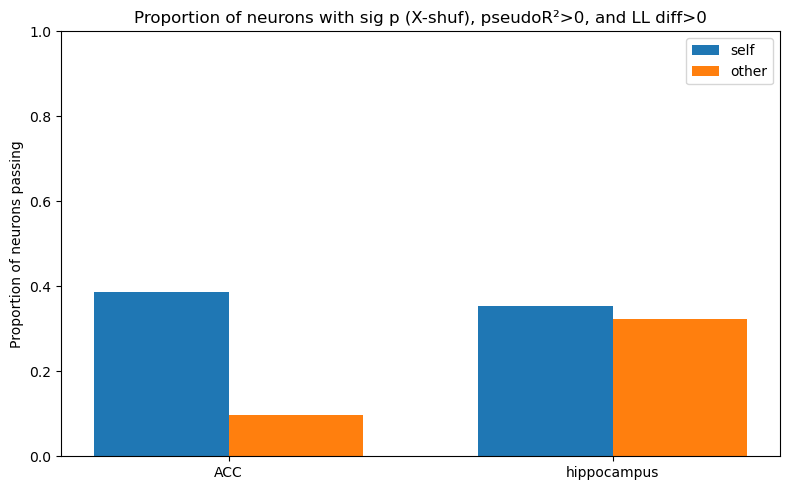

✅ Saved barplot: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/proportion_passing_barplot.png


In [26]:
import pickle
import pandas as pd
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
PKL_PATH = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/ALL_CONDITIONS_RESULTS.pkl"
ALPHA = 0.05
SAVE_DIR = os.path.dirname(PKL_PATH)

# === LOAD ===
with open(PKL_PATH, "rb") as f:
    results = pickle.load(f)

# === BUILD SUMMARY OF PROPORTIONS ===
rows = []
for key, block in results.items():
    # Expect keys like "ACC_self", "hippocampus_other"
    if "_" in key:
        region, condition = key.split("_", 1)
    else:
        region, condition = key, "unknown"

    summary_df = block.get("summary", pd.DataFrame())
    if summary_df.empty:
        total_n = 0
        pass_n = 0
    else:
        # Required columns should be present in your updated run_poisson_ridge
        needed = {"p_val_ll_diff_xshuf", "pseudo_r2", "ll_diff_xshuf"}
        if not needed.issubset(set(summary_df.columns)):
            raise ValueError(f"Missing required columns in {key}: {needed - set(summary_df.columns)}")

        crit = (
            # (summary_df["p_val_ll_diff_xshuf"] < ALPHA) &
            # (summary_df["pseudo_r2"] > 0) &
            (summary_df["ll_diff_xshuf"] > 0)
        )

        total_n = len(summary_df)
        pass_n = int(crit.sum())

    prop = (pass_n / total_n) if total_n > 0 else np.nan
    rows.append({
        "region": region,
        "condition": condition,
        "total_neurons": total_n,
        "passing_neurons": pass_n,
        "proportion_passing": prop
    })

prop_df = pd.DataFrame(rows).sort_values(["region", "condition"]).reset_index(drop=True)

# Save the table
out_csv = os.path.join(SAVE_DIR, "proportion_passing_by_region_condition.csv")
prop_df.to_csv(out_csv, index=False)
print(f"✅ Saved summary CSV: {out_csv}")
print(prop_df)

# === BARPLOT (matplotlib only, no seaborn) ===
# We’ll plot bars for each (region, condition). If you want grouped bars by region with self/other side-by-side, we’ll do offsets.

regions = sorted(prop_df["region"].unique())
conditions = ["self", "other"]  # enforce order if both exist

# Build data in fixed order
labels = []
values_by_cond = {c: [] for c in conditions}
for rg in regions:
    sub = prop_df[prop_df["region"] == rg]
    labels.append(rg)
    for c in conditions:
        row = sub[sub["condition"] == c]
        if row.empty:
            values_by_cond[c].append(np.nan)
        else:
            values_by_cond[c].append(float(row["proportion_passing"].iloc[0]))

x = np.arange(len(regions))
bar_width = 0.35

plt.figure(figsize=(8, 5))
# Self bars
plt.bar(x - bar_width/2, values_by_cond["self"], width=bar_width, label="self")
# Other bars
plt.bar(x + bar_width/2, values_by_cond["other"], width=bar_width, label="other")

plt.xticks(x, regions)
plt.ylabel("Proportion of neurons passing")
plt.title("Proportion of neurons with sig p (X-shuf), pseudoR²>0, and LL diff>0")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
out_png = os.path.join(SAVE_DIR, "proportion_passing_barplot.png")
plt.savefig(out_png, dpi=200)
plt.show()
print(f"✅ Saved barplot: {out_png}")



# Checking correlations between self and other

In [12]:
def compute_self_other_beta_corr_from_results(results, region):
    """
    Compute correlation between self and other neuron-by-predictor mean beta matrices from regression output.
    
    Args:
        results: dict from run_all_conditions_for_patient
        region: str, e.g., 'ACC' or 'hippocampus'
    
    Returns:
        comparison_df: DataFrame with neuron_index, true_corr
    """
    df_self = results[f"{region}_self"]["coef"]
    df_other = results[f"{region}_other"]["coef"]

    # Ensure matched neurons
    common_idx = df_self.index.intersection(df_other.index)
    df_self = df_self.loc[common_idx].sort_index()
    df_other = df_other.loc[common_idx].sort_index()

    # Compute per-neuron Pearson correlations
    corrs = [pearsonr(df_self.loc[i], df_other.loc[i])[0] for i in df_self.index]

    return pd.DataFrame({
        "neuron_index": df_self.index,
        "true_corr": corrs,
        "region": region.upper()
    })


import os




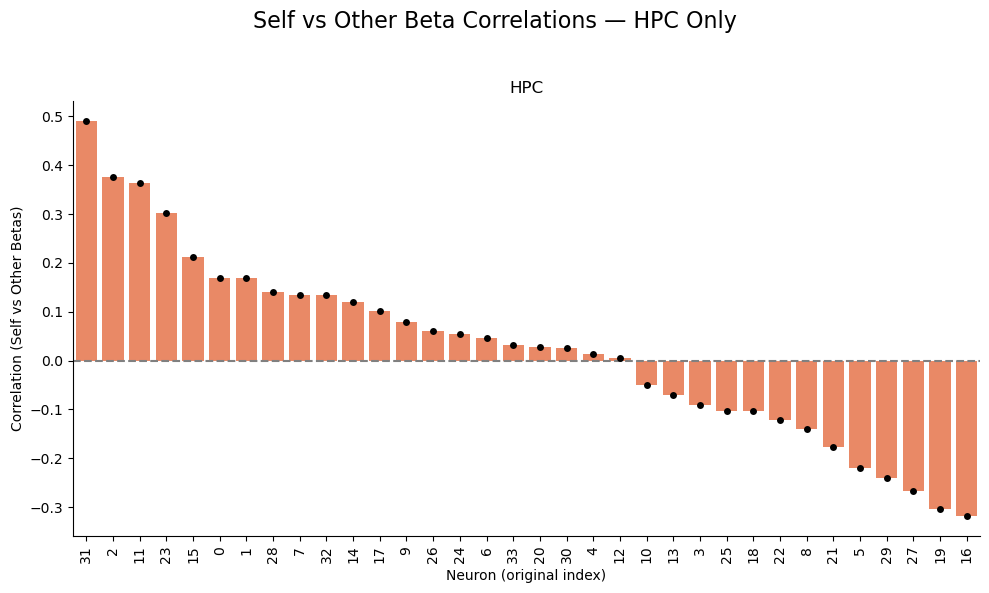

In [24]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
import pandas as pd

# === Only HPC results ===
comparison_df_hpc = compute_self_other_beta_corr_from_results(results, "hippocampus")
comparison_df_hpc["region"] = "HPC"

df_hpc = comparison_df_hpc.copy().sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_hpc['plot_idx'] = range(len(df_hpc))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# HPC plot only
sns.barplot(data=df_hpc, x='plot_idx', y='true_corr', ax=ax, color='coral')
sns.stripplot(data=df_hpc, x='plot_idx', y='true_corr', ax=ax, color='black', size=5, jitter=False)
ax.set_title('HPC')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Neuron (original index)')
ax.set_ylabel('Correlation (Self vs Other Betas)')
ax.set_xticks(df_hpc['plot_idx'])
ax.set_xticklabels(df_hpc['neuron_index'], rotation=90)

plt.suptitle('Self vs Other Beta Correlations — HPC Only', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
sns.despine()
plt.show()


✅ Correlation comparison DataFrames saved!
✅ Saved combined plot to /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/COMBINED_ACC_HPC_BETA_CORRELATIONS.png and .eps


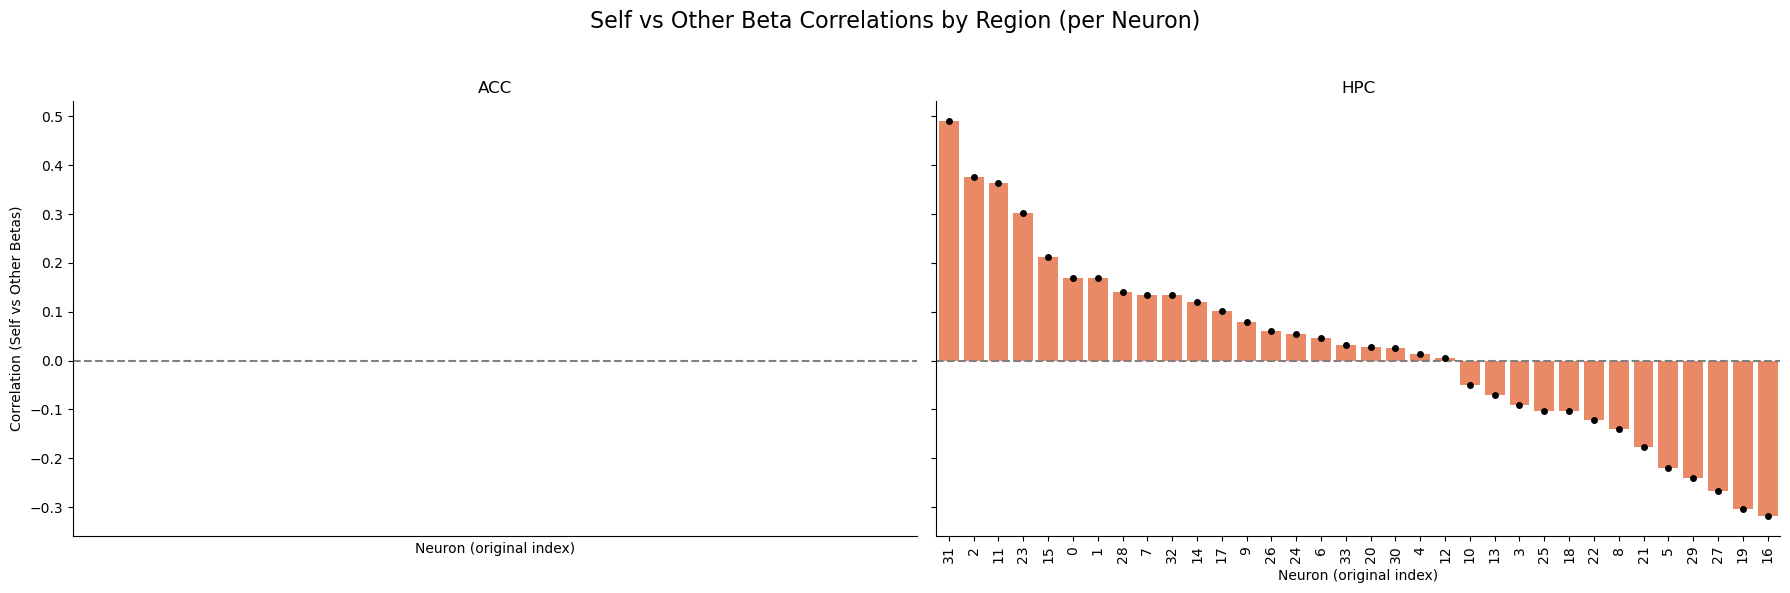

✅ Saved ACC-only plot to /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/ACC_SELF_OTHER_BETA_CORRELATIONS.png and .eps
✅ Saved HPC-only plot to /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/HPC_SELF_OTHER_BETA_CORRELATIONS.png and .eps


In [25]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
import pandas as pd
import os

# === Compute comparison DataFrames ===
comparison_df_acc = compute_self_other_beta_corr_from_results(results, "ACC")
comparison_df_hpc = compute_self_other_beta_corr_from_results(results, "hippocampus")
comparison_df_hpc["region"] = "HPC"

patient_results_dir = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28"
os.makedirs(patient_results_dir, exist_ok=True)

# Save CSVs for ACC and HPC
comparison_df_acc.to_csv(os.path.join(patient_results_dir, "ACC_SELF_OTHER_CORRELATION.csv"), index=False)
comparison_df_hpc.to_csv(os.path.join(patient_results_dir, "HIPPOCAMPUS_SELF_OTHER_CORRELATION.csv"), index=False)
print("✅ Correlation comparison DataFrames saved!")

# === Combine for plotting ===comparison_df_acc,
combined_df = pd.concat([comparison_df_hpc], ignore_index=True)

# Split and sort
df_acc = combined_df[combined_df['region'] == 'ACC'].copy().sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_hpc = combined_df[combined_df['region'] == 'HPC'].copy().sort_values(by='true_corr', ascending=False).reset_index(drop=True)

df_acc['plot_idx'] = range(len(df_acc))
df_hpc['plot_idx'] = range(len(df_hpc))

# === 1️⃣ Combined Subplot: ACC + HPC side by side ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# ACC subplot
sns.barplot(data=df_acc, x='plot_idx', y='true_corr', ax=axes[0], color='mediumseagreen')
sns.stripplot(data=df_acc, x='plot_idx', y='true_corr', ax=axes[0], color='black', size=5, jitter=False)
axes[0].set_title('ACC')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Neuron (original index)')
axes[0].set_ylabel('Correlation (Self vs Other Betas)')
axes[0].set_xticks(df_acc['plot_idx'])
axes[0].set_xticklabels(df_acc['neuron_index'], rotation=90)

# HPC subplot
sns.barplot(data=df_hpc, x='plot_idx', y='true_corr', ax=axes[1], color='coral')
sns.stripplot(data=df_hpc, x='plot_idx', y='true_corr', ax=axes[1], color='black', size=5, jitter=False)
axes[1].set_title('HPC')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Neuron (original index)')
axes[1].set_ylabel('')
axes[1].set_xticks(df_hpc['plot_idx'])
axes[1].set_xticklabels(df_hpc['neuron_index'], rotation=90)

plt.suptitle('Self vs Other Beta Correlations by Region (per Neuron)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
sns.despine()

# SAVE combined figure
combined_base = os.path.join(patient_results_dir, "COMBINED_ACC_HPC_BETA_CORRELATIONS")
plt.savefig(f"{combined_base}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{combined_base}.eps", format='eps', bbox_inches='tight')
print(f"✅ Saved combined plot to {combined_base}.png and .eps")

plt.show()
plt.close(fig)

# === 2️⃣ Separate plot for ACC only ===
fig_acc, ax_acc = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_acc, x='plot_idx', y='true_corr', ax=ax_acc, color='mediumseagreen')
sns.stripplot(data=df_acc, x='plot_idx', y='true_corr', ax=ax_acc, color='black', size=5, jitter=False)
ax_acc.set_title('ACC')
ax_acc.axhline(0, color='gray', linestyle='--')
ax_acc.set_xlabel('Neuron (original index)')
ax_acc.set_ylabel('Correlation (Self vs Other Betas)')
ax_acc.set_xticks(df_acc['plot_idx'])
ax_acc.set_xticklabels(df_acc['neuron_index'], rotation=90)
plt.suptitle('Self vs Other Beta Correlations — ACC', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
sns.despine()

save_base_acc = os.path.join(patient_results_dir, "ACC_SELF_OTHER_BETA_CORRELATIONS")
plt.savefig(f"{save_base_acc}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{save_base_acc}.eps", format='eps', bbox_inches='tight')
print(f"✅ Saved ACC-only plot to {save_base_acc}.png and .eps")
plt.close(fig_acc)

# === 3️⃣ Separate plot for HPC only ===
fig_hpc, ax_hpc = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_hpc, x='plot_idx', y='true_corr', ax=ax_hpc, color='coral')
sns.stripplot(data=df_hpc, x='plot_idx', y='true_corr', ax=ax_hpc, color='black', size=5, jitter=False)
ax_hpc.set_title('HPC')
ax_hpc.axhline(0, color='gray', linestyle='--')
ax_hpc.set_xlabel('Neuron (original index)')
ax_hpc.set_ylabel('Correlation (Self vs Other Betas)')
ax_hpc.set_xticks(df_hpc['plot_idx'])
ax_hpc.set_xticklabels(df_hpc['neuron_index'], rotation=90)
plt.suptitle('Self vs Other Beta Correlations — HPC', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
sns.despine()

save_base_hpc = os.path.join(patient_results_dir, "HPC_SELF_OTHER_BETA_CORRELATIONS")
plt.savefig(f"{save_base_hpc}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{save_base_hpc}.eps", format='eps', bbox_inches='tight')
print(f"✅ Saved HPC-only plot to {save_base_hpc}.png and .eps")
plt.close(fig_hpc)


# Running reliability results

In [15]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import PoissonRegressor
import numpy as np
from joblib import Parallel, delayed
from scipy.special import gammaln

In [16]:
# === TOP-LEVEL IMPORTS ===

def get_best_alpha(X, y, alphas, random_state=0):
    best_ll = -np.inf
    best_alpha = None
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    for alpha in alphas:
        ll_scores = []
        for train_idx, val_idx in kf.split(X):
            model = PoissonRegressor(alpha=alpha, max_iter=1000)
            model.fit(X[train_idx], y[train_idx])
            pred = np.clip(model.predict(X[val_idx]), 1e-10, None)
            ll = np.sum(y[val_idx] * np.log(pred) - pred - gammaln(y[val_idx] + 1))
            ll_scores.append(ll)

        avg_ll = np.mean(ll_scores)
        if avg_ll > best_ll:
            best_ll = avg_ll
            best_alpha = alpha

    return best_alpha


def compute_beta_reliability(X_self, y_self, X_other, y_other, alphas, n_nulls=100):
    # Split trials
    Xs1, Xs2, ys1, ys2 = train_test_split(X_self, y_self, test_size=0.5, random_state=0)
    Xo1, Xo2, yo1, yo2 = train_test_split(X_other, y_other, test_size=0.5, random_state=0)

    # Tune alpha
    alpha_self = get_best_alpha(Xs1, ys1, alphas)
    alpha_other = get_best_alpha(Xo1, yo1, alphas)

    # Fit models
    model_s1 = PoissonRegressor(alpha=alpha_self, max_iter=1000).fit(Xs1, ys1)
    model_s2 = PoissonRegressor(alpha=alpha_self, max_iter=1000).fit(Xs2, ys2)
    model_o1 = PoissonRegressor(alpha=alpha_other, max_iter=1000).fit(Xo1, yo1)
    model_o2 = PoissonRegressor(alpha=alpha_other, max_iter=1000).fit(Xo2, yo2)

    beta_s1 = model_s1.coef_
    beta_s2 = model_s2.coef_
    beta_o1 = model_o1.coef_
    beta_o2 = model_o2.coef_

    # True correlations
    r_self = pearsonr(beta_s1, beta_s2)[0]
    r_other = pearsonr(beta_o1, beta_o2)[0]
    r_cross = pearsonr(beta_s1, beta_o1)[0]

    # Null distribution
    null_corrs = []
    for _ in range(n_nulls):
        yo_shuf = np.random.permutation(y_other)
        model_null = PoissonRegressor(alpha=alpha_other, max_iter=1000).fit(X_other, yo_shuf)
        null_corrs.append(pearsonr(beta_s1, model_null.coef_)[0])

    return {
        'r_self': r_self,
        'r_other': r_other,
        'r_cross': r_cross,
        'null_distribution': null_corrs,
        'null_mean': np.mean(null_corrs),
        'null_std': np.std(null_corrs),
    }

# === Run for all neurons ===
def run_beta_reliability_all_neurons(X_self, X_other, Y_self, Y_other,
                                     alphas, n_nulls=100,
                                     neuron_mode='all', n_jobs=-1):
    if neuron_mode == 'all':
        neuron_indices = range(Y_self.shape[1])
    else:
        neuron_indices = [neuron_mode]

    def run_single_neuron(neuron_idx):
        y_self = Y_self[:, neuron_idx]
        y_other = Y_other[:, neuron_idx]
        try:
            res = compute_beta_reliability(X_self, y_self, X_other, y_other,
                                           alphas=alphas, n_nulls=n_nulls)
            res['neuron'] = neuron_idx
            return res
        except Exception as e:
            print(f"Neuron {neuron_idx} failed: {e}")
            return None

    from joblib import parallel_backend
    with parallel_backend("threading"):
        results = Parallel(n_jobs=n_jobs)(
            delayed(run_single_neuron)(i) for i in neuron_indices
        )

    return [r for r in results if r is not None]




In [26]:
# Define alphas to search
alphas = np.logspace(-3, 3, 30)
#-3, 2, 10
#
#param_grid = {'alpha': np.logspace(-3, 3, 30)}
# # Run reliability analysis for all ACC neurons
acc_results = run_beta_reliability_all_neurons(
    X_self=X_self_ACC_clean,
    X_other=X_other_ACC_clean,
    Y_self=region_Ys["ACC"]["self"],
    Y_other=region_Ys["ACC"]["other"],
    alphas=alphas,
    n_nulls=100,                 # how many null shuffles per neuron
    neuron_mode='all',
    n_jobs=10 
                            # or set a specific index like 0
)
hpc_results = run_beta_reliability_all_neurons(
    X_self=X_self_hippo_clean,
    X_other=X_other_hippo_clean,
    Y_self=region_Ys["hippocampus"]["self"],
    Y_other=region_Ys["hippocampus"]["other"],
    alphas=alphas,
    n_nulls=100,                 # how many null shuffles per neuron
    neuron_mode='all',
    n_jobs=10            # or set a specific index like 0
)

import os
import pickle

patient_results_dir = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28"
os.makedirs(patient_results_dir, exist_ok=True)

with open(os.path.join(patient_results_dir, "ACC_RELIABILITY_RESULTS.pkl"), "wb") as f:
    pickle.dump(acc_results, f)

with open(os.path.join(patient_results_dir, "HIPPOCAMPUS_RELIABILITY_RESULTS.pkl"), "wb") as f:
    pickle.dump(hpc_results, f)

print("✅ Reliability results saved!")

# === SAVE PICKLES ===
patient_results_dir = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28"
os.makedirs(patient_results_dir, exist_ok=True)

with open(os.path.join(patient_results_dir, "ACC_RELIABILITY_RESULTS.pkl"), "wb") as f:
    pickle.dump(acc_results, f)

with open(os.path.join(patient_results_dir, "HIPPOCAMPUS_RELIABILITY_RESULTS.pkl"), "wb") as f:
    pickle.dump(hpc_results, f)

print("✅ Reliability results saved!")


# === SAVE CSV WITH NEURON-LEVEL AND REGION-LEVEL MEANS ===
all_rows = []

# ACC neurons
for res in acc_results:
    all_rows.append({
        'region': 'ACC',
        'neuron': res.get('neuron', None),
        'r_self': res.get('r_self', np.nan),
        'r_other': res.get('r_other', np.nan),
        'r_cross': res.get('r_cross', np.nan)
    })

# HIPPOCAMPUS neurons
for res in hpc_results:
    all_rows.append({
        'region': 'HIPPOCAMPUS',
        'neuron': res.get('neuron', None),
        'r_self': res.get('r_self', np.nan),
        'r_other': res.get('r_other', np.nan),
        'r_cross': res.get('r_cross', np.nan)
    })

df_corrs = pd.DataFrame(all_rows)

# Compute region-level means
region_means = df_corrs.groupby('region')[['r_self', 'r_other', 'r_cross']].mean().reset_index()
region_means['neuron'] = 'SUMMARY'
region_means = region_means[['region', 'neuron', 'r_self', 'r_other', 'r_cross']]

# Append summary to neuron-level data
df_final = pd.concat([df_corrs, region_means], ignore_index=True)

# Save CSV
corr_csv_path = os.path.join(patient_results_dir, "R_SELF_OTHER_CROSS_CORRELATIONS.csv")
df_final.to_csv(corr_csv_path, index=False)
print(f"✅ Saved neuron-level + region-level summary CSV to: {corr_csv_path}")


✅ Reliability results saved!
✅ Reliability results saved!
✅ Saved neuron-level + region-level summary CSV to: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT_150_200_500/allwords/YFC_28/R_SELF_OTHER_CROSS_CORRELATIONS.csv


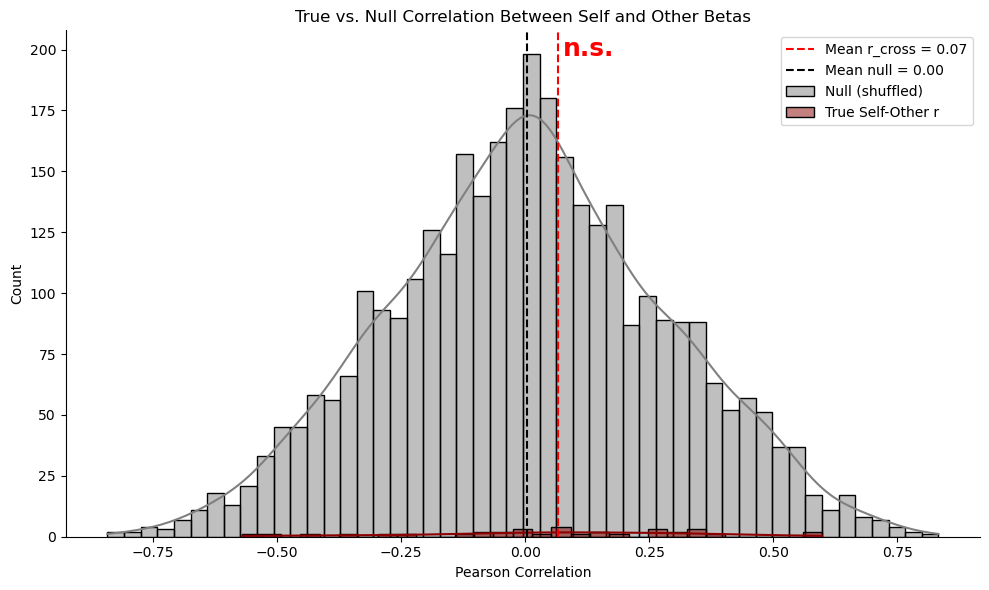

Mean r_cross = 0.066
Mean null = 0.004
P-value (null ≥ true): 0.0588 → n.s.
Effect size: 0.0620


  ➤ Neuron 1
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 4
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 9
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 12
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 16
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 20
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 24
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 28
✅ Results saved to: /projects/bhayden/anilu/Language_docs/RegressionRESULTS/allwords/YFC_28_hippocampus_self
  ➤ Neuron 32
✅ Res

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Convert results to DataFrame
df = pd.DataFrame(hpc_results)

# Extract true values
true_cross = df['r_cross'].dropna().values
true_self = df['r_self'].dropna().values
true_other = df['r_other'].dropna().values

# Combine all null distributions across neurons
all_null = np.concatenate(df['null_distribution'].values)

# Compute mean values
mean_true = np.mean(true_cross)
mean_null = np.mean(all_null)

# === Permutation-style p-value: how often null ≥ true mean?
null_means = [np.mean(dist) for dist in df['null_distribution']]
p_value = np.mean(np.array(null_means) >= mean_true)

# Convert to significance level
if p_value < 0.001:
    sig = '***'
elif p_value < 0.01:
    sig = '**'
elif p_value < 0.05:
    sig = '*'
else:
    sig = 'n.s.'

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.histplot(all_null, bins=50, color='gray', label='Null (shuffled)', kde=True)
sns.histplot(true_cross, bins=30, color='darkred', label='True Self-Other r', kde=True)

# Mean lines
plt.axvline(mean_true, color='red', linestyle='--', label=f'Mean r_cross = {mean_true:.2f}')
plt.axvline(mean_null, color='black', linestyle='--', label=f'Mean null = {mean_null:.2f}')

# Add asterisk above mean line
ymax = plt.ylim()[1]
plt.text(mean_true + 0.01, ymax * 0.95, sig, color='red', fontsize=18, fontweight='bold')

plt.title("True vs. Null Correlation Between Self and Other Betas")
plt.xlabel("Pearson Correlation")
plt.ylabel("Count")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# Optional: print for record
print(f"Mean r_cross = {mean_true:.3f}")
print(f"Mean null = {mean_null:.3f}")
print(f"P-value (null ≥ true): {p_value:.4f} → {sig}")
effect_size = mean_true - mean_null
print(f"Effect size: {effect_size:.4f}")



In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def test_region_mean_above_chance(
    neuron_results,
    region_name='REGION',
    patient_results_dir=None,
    n_permutations=10000
):
    """
    neuron_results = list of dictionaries with keys:
      - 'r_cross': true observed correlation
      - 'null_distribution': list of shuffled r_cross values

    region_name = string to identify this region
    patient_results_dir = path to the patient's save directory (if you want to save CSV there)
    """

    # 1️⃣ Clean & extract
    true_r_cross = [
        n['r_cross'] for n in neuron_results
        if n['r_cross'] is not None and not np.isnan(n['r_cross'])
    ]
    null_distributions = [
        n['null_distribution'] for n in neuron_results
        if n['null_distribution'] is not None and len(n['null_distribution']) > 0
    ]

    if len(true_r_cross) == 0 or len(null_distributions) == 0:
        print("⚠️ No valid data to analyze!")
        return

    mean_true = np.mean(true_r_cross)
    print(f"\n✅ Observed region mean_true: {mean_true:.4f}")

    # 2️⃣ Build region-level null distribution
    region_null_means = []
    for _ in range(n_permutations):
        sampled = [np.random.choice(nd) for nd in null_distributions]
        region_null_means.append(np.mean(sampled))

    region_null_means = np.array(region_null_means)

    mean_null = np.mean(region_null_means)

    # 3️⃣ Compute p-value
    p_value = np.mean(region_null_means >= mean_true)
    sig = (
        '***' if p_value < 0.001 else
        '**' if p_value < 0.01 else
        '*' if p_value < 0.05 else 'n.s.'
    )

    print(f"✅ Region Null Mean = {mean_null:.4f}")
    print(f"✅ P-value = {p_value:.4f} → {sig}")

    # 4️⃣ Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(region_null_means, bins=50, color='gray', kde=True, label='Null Distribution of Region Means')
    plt.axvline(mean_true, color='red', linestyle='--', label=f'Mean True = {mean_true:.2f}')
    plt.title(f"{region_name} - Permutation Test for Region Mean r_cross (p = {p_value:.4f}, {sig})")
    plt.xlabel("Region-level Mean r_cross")
    plt.ylabel("Count")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5️⃣ Save result to patient folder if specified
    result_dict = {
        'region': region_name,
        'mean_true': mean_true,
        'mean_null': mean_null,
        'p_value': p_value,
        'sig': sig
    }

    if patient_results_dir is not None:
        os.makedirs(patient_results_dir, exist_ok=True)
        csv_path = os.path.join(patient_results_dir, "REGION_LEVEL_PERMUTATION_RESULTS.csv")

        # Append or create
        if os.path.exists(csv_path):
            df_existing = pd.read_csv(csv_path)
            df_new = pd.DataFrame([result_dict])
            df_combined = pd.concat([df_existing, df_new], ignore_index=True)
            df_combined.to_csv(csv_path, index=False)
        else:
            df_new = pd.DataFrame([result_dict])
            df_new.to_csv(csv_path, index=False)

        print(f"✅ Saved result to {csv_path}")

    return result_dict



✅ Observed region mean_true: 0.0657
✅ Region Null Mean = 0.0039
✅ P-value = 0.0992 → n.s.


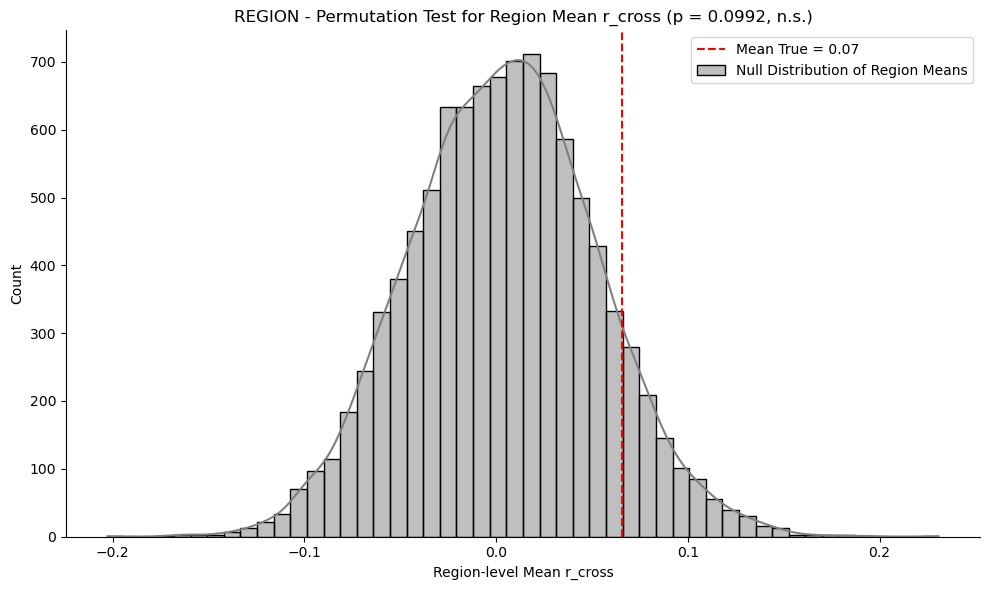


✅ Observed region mean_true: 0.1512
✅ Region Null Mean = -0.0013
✅ P-value = 0.0018 → **


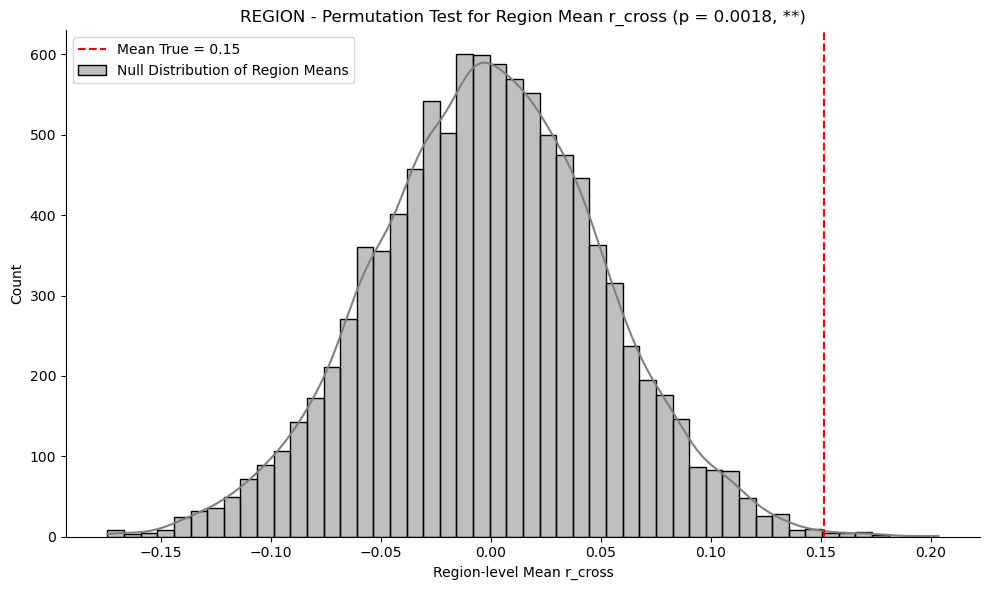

In [29]:
result = test_region_mean_above_chance(hpc_results)
result2 = test_region_mean_above_chance(acc_results)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


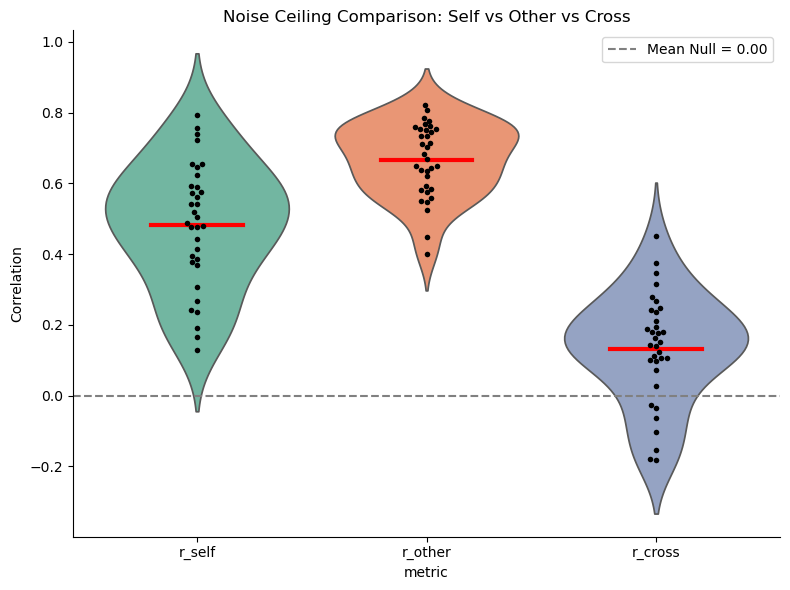

In [39]:
plt.figure(figsize=(8, 6))

# Melt the DataFrame for easier plotting
df_long = pd.melt(df, value_vars=['r_self', 'r_other', 'r_cross'], var_name='metric', value_name='correlation')

# Create the violin plot and swarm plot
sns.violinplot(data=df_long, x='metric', y='correlation', inner=None, palette='Set2')
sns.swarmplot(data=df_long, x='metric', y='correlation', color='black', size=4)

# Get the x-tick locations
xticks = {'r_self': 0, 'r_other': 1, 'r_cross': 2}

# Add mean lines *only* inside each violin
for metric, x in xticks.items():
    mean_val = df_long[df_long['metric'] == metric]['correlation'].mean()
    plt.plot([x-0.2, x+0.2], [mean_val, mean_val], color='red', lw=3)  # Short horizontal line

# Null mean (gray full line)
null_mean = np.mean(np.concatenate(df['null_distribution'].values))
plt.axhline(null_mean, linestyle='--', color='gray', label=f'Mean Null = {null_mean:.2f}')

plt.ylabel("Correlation")
plt.title("Noise Ceiling Comparison: Self vs Other vs Cross")
plt.legend()
sns.despine()
plt.tight_layout()
plt.savefig("/projects/bhayden/anilu/noise_ceiling_comparison.eps", format='eps', dpi=300)
plt.show()


# Semantic Clusterting

In [8]:
def compute_trial_activations(results, X_dict):
    """
    Computes per-trial predicted activations for all condition keys in the results dict.

    Args:
        results (dict): Output from run_all_conditions_for_patient
        X_dict (dict): Dictionary mapping condition keys (e.g., "ACC_self") to design matrices

    Returns:
        activations_dict (dict): Keys are region_condition strings, values are trial x neuron DataFrames
    """
    activations_dict = {}

    for key in results.keys():
        X = X_dict[key]  # (n_trials, n_predictors)
        coef_df = results[key]["coef"]  # (n_neurons, n_predictors)
        B = coef_df.values.T  # transpose → (n_predictors, n_neurons)

        activation_matrix = X @ B  # (n_trials, n_neurons)
        activation_df = pd.DataFrame(
            activation_matrix,
            columns=[f"Neuron_{i}" for i in range(activation_matrix.shape[1])]
        )
        activations_dict[key] = activation_df

    return activations_dict


activations_dict = compute_trial_activations(results, X_dict)


NameError: name 'results' is not defined

In [38]:
import pandas as pd
import re

# === Load Metadata ===
metadata_path = "/Users/aniluchavez/Documents/MATLAB/Language/PTYEZ_60_withSC.xlsx"
metadata = pd.read_excel(metadata_path)

# === Melt speaker columns into long format ===
speaker_cols = [ 'Speaker2','Speaker1', 'Speaker3']#, 'Speaker4', 'Speaker5', 'Speaker6', 'Speaker7'
melted = metadata.melt(
    id_vars=['onset', 'offset', 'Duration', 'clusID'],
    value_vars=speaker_cols,
    var_name='Speaker',
    value_name='Word'
).dropna(subset=['Word']).reset_index(drop=True)

# Sort chronologically after melting
melted = melted.sort_values(by="onset").reset_index(drop=True)

# Clean up speaker label
melted['Speaker'] = melted['Speaker'].str.replace('Speaker', 'SPK')

# === Reassign specific function words to cluster 11 ===
function_words = ['it', 'its', 'that', 'thats', 'what', 'those', 'well', 'course','not','quite','wanna','just','maybe','a','other','also','right','something']
place_words=['left']

# Strip punctuation and whitespace, lowercase for matching
melted['Word_clean'] = (
    melted['Word']
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)  # Remove punctuation
)

# Assign clusID = 11 to any matching function words
melted.loc[melted['Word_clean'].isin(function_words), 'clusID'] = 11
melted.loc[melted['Word_clean'].isin(place_words), 'clusID'] = 2
# === Step 2: Split into Self vs Other ===
metadata_self = melted[melted["Speaker"] == "SPK1"].reset_index(drop=True)
metadata_other = melted[melted["Speaker"] != "SPK1"].reset_index(drop=True)


In [43]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def compute_cluster_cosine_distances_from_activations(metadata_self, metadata_other, activations_dict, condition_prefix="ACC"):
    # Join metadata with activations
    merged_self = pd.concat([metadata_self.reset_index(drop=True), activations_dict[f"{condition_prefix}_self"]], axis=1)
    merged_other = pd.concat([metadata_other.reset_index(drop=True), activations_dict[f"{condition_prefix}_other"]], axis=1)

    neuron_cols = [col for col in merged_self.columns if col.startswith("Neuron_")]
    cluster_ids = sorted(set(merged_self['clusID']).intersection(set(merged_other['clusID'])))
    
    cosine_dists = []
    for cid in cluster_ids:
        vec_self = merged_self[merged_self['clusID'] == cid][neuron_cols].mean().values.reshape(1, -1)
        vec_other = merged_other[merged_other['clusID'] == cid][neuron_cols].mean().values.reshape(1, -1)
        cos_sim = cosine_similarity(vec_self, vec_other)[0, 0]
        cosine_dists.append({
            "clusID": cid,
            "cosine_similarity": cos_sim,
            "cosine_distance": 1 - cos_sim
        })
    
    return pd.DataFrame(cosine_dists), vec_other, vec_self

# Then call it:
cosine_df, vec_self, vec_other = compute_cluster_cosine_distances_from_activations(
    metadata_self, metadata_other, activations_dict, condition_prefix="hippocampus"
)



# Merge with cosine_df to include the examples
# cosine_df = cosine_df.merge(example_words_per_cluster, on="clusID", how="left")


cosine_df.sort_values("cosine_distance", ascending=False)
vec_self

array([[ 0.16728038, -0.16813347,  0.13434759,  0.13934685,  0.15641532,
         0.01559622,  0.15312681, -0.05390303,  0.12909045,  0.05515671,
         0.03793438,  0.11809684,  0.08576009,  0.14364164,  0.10088736,
         0.03070018,  0.00669911,  0.08152469, -0.0532577 ,  0.077259  ,
         0.10060942,  0.1114789 ,  0.07681387,  0.08506617,  0.15405217,
         0.1306961 ,  0.11539438,  0.065369  ]])

In [44]:
import re
import random

used_words = set()  # Track globally used words

def clean_and_sample_words(group):
    global used_words
    # Clean each word: remove punctuation, lowercase, and strip spaces
    cleaned = group.dropna().drop_duplicates().apply(
        lambda w: re.sub(r'[^\w\s]', '', w).lower().strip()
    )
    # Filter out globally used words
    available = [w for w in cleaned if w not in used_words and w != ""]
    sampled = random.sample(available, min(5, len(available)))
    used_words.update(sampled)
    return ', '.join(sampled)

example_words_per_cluster = (
    metadata_self
    .groupby("clusID")["Word"]
    .apply(clean_and_sample_words)
    .reset_index()
    .rename(columns={"Word": "example_words"})
)

# Merge with cosine_df and export
cosine_df = cosine_df.merge(example_words_per_cluster, on="clusID", how="left")
example_words_per_cluster.to_csv("/Users/aniluchavez/Documents/Language/example_words_per_cluster.csv", index=False)


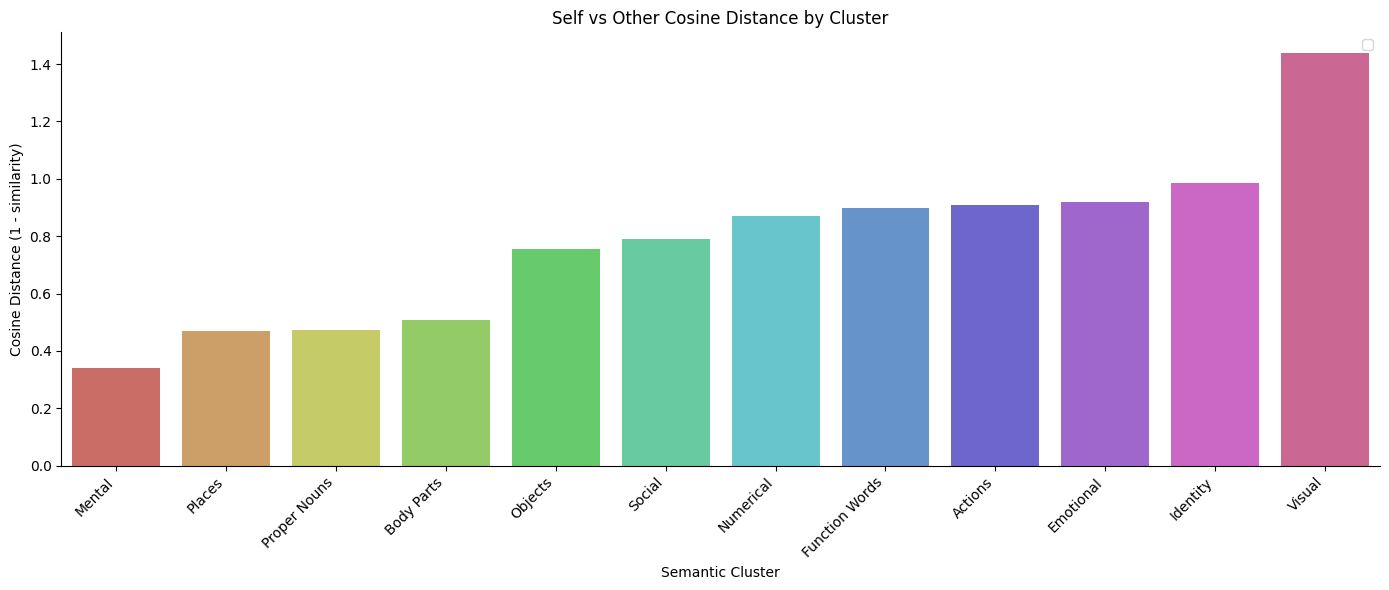

In [45]:
# Re-import required packages due to code execution state reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define the plotting function with cluster name mapping
def plot_cosine_distances_rainbow_annotated(cosine_df, title="Self vs Other Cosine Distance by Cluster", top_n=None):
    cluster_labels = {
        1: "Body Parts", 2: "Places", 3: "Emotional", 4: "Mental", 5: "Social",
        6: "Objects", 7: "Visual", 8: "Numerical", 9: "Actions", 10: "Identity",
        11: "Function Words", 12: "Proper Nouns"
    }

    cosine_df_sorted = cosine_df.sort_values("cosine_distance", ascending=True)

    if top_n:
        cosine_df_sorted = cosine_df_sorted.head(top_n)

    cosine_df_sorted["Label"] = cosine_df_sorted["clusID"].map(cluster_labels)
    # cosine_df_sorted["Label_Annotated"] = cosine_df_sorted.apply(
    #     lambda row: f"{row['Label']}\n({row['example_words_y']})", axis=1
    # )


    plt.figure(figsize=(14, 6))
    n_clusters = len(cosine_df_sorted)
    palette = sns.color_palette("hls", n_clusters)
    
    sns.barplot(
        data=cosine_df_sorted,
        x="Label",
        y="cosine_distance",
        palette=palette
    )


    # plt.axhline(0.5, color="gray", linestyle="--", label="Reference (0.5)")
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Semantic Cluster")
    plt.ylabel("Cosine Distance (1 - similarity)")
    plt.title(title)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_cosine_distances_rainbow_annotated(cosine_df)


In [ ]:
def run_batch_across_patients(patient_configs, regions, speakers, n_iterations=10, n_jobs=-1):
    """
    Run the full regression pipeline across multiple patients.

    Args:
        patient_configs: list of dicts with all paths and settings for each patient
        regions: list of regions to analyze
        speakers: list of speaker folder names
        n_iterations: number of CV iterations
        n_jobs: parallel jobs for neurons

    Returns:
        all_patient_results: dict keyed by patient_id
    """
    all_patient_results = {}

    for config in patient_configs:
        patient_id = config["patient_id"]
        print(f"\n===============================")
        print(f"👤 Processing patient: {patient_id}")
        print(f"===============================\n")

        # Load X matrices
        X_self, X_other, df_metadata, X_words_self, X_words_other = get_self_and_other_features(
            config["embedding_file"],
            config["duration_file"],
            n_components=30,
            target_speaker=config["target_speaker_csv"]
        )

        # Load spike data
        spike_data = load_spike_data(
            speakers=speakers,
            regions=regions,
            self_base_dir=config["self_base_dir"],
            other_base_dir=config["other_base_dir"],
            self_shift_tag=config["self_shift_tag"],
            other_shift_tag=config["other_shift_tag"],
            target_speaker=config["target_speaker_folder"]
        )

        # Build Y matrices
        region_Ys = build_Y_matrices(
            df_metadata,
            spike_data,
            regions,
            target_speaker=config["target_speaker_csv"]
        )

        # Make X_dict, Y_dict for run_all_conditions_for_patient
        X_dict = {}
        Y_dict = {}
        for region in regions:
            X_dict[f"{region}_self"] = X_self
            X_dict[f"{region}_other"] = X_other
            Y_dict[f"{region}_self"] = region_Ys[region]["self"]
            Y_dict[f"{region}_other"] = region_Ys[region]["other"]

        # Run regression
        patient_results = run_all_conditions_for_patient(
            X_dict=X_dict,
            Y_dict=Y_dict,
            patient_id=patient_id,
            region_list=regions,
            n_iterations=n_iterations,
            n_jobs=n_jobs
        )

        # Store
        all_patient_results[patient_id] = patient_results

    return all_patient_results





patient_ids = [
    # "PTYFF_task17",
    # "PTYFC_task28",
    "PTYFG_task18",
    "PTYEY_task86",
    "PTYFA_task25",
    "PTYFI_task81",
    "PTYEV_task37",
    "PTYEZ_task60",

]

patient_configs = []
embeddings_base = "/scratch/agc10/LanguageRegressions/DataBert/Final_words_english_only_BERT"
durations_base  = "/scratch/agc10/LanguageRegressions/DataBert/SpikeOutputs"
spike_base      = "/scratch/agc10/LanguageRegressions/DataBert/SpikeOutputs"

for pid in patient_ids:
    # Decapitalize only the first 2 letters for the duration filename
    lower_pid_for_duration = pid[:2].lower() + pid[2:]
    
    patient_configs.append({
        "patient_id": pid,
        "embedding_file": f"{embeddings_base}/{pid}_words_english_only/{pid}_aligned_word2vec_embeddings.csv",
        "duration_file": f"{durations_base}/output_{pid}_word2vec_shiftm150ms/{lower_pid_for_duration}_with_regress_dur_shiftm150ms.xlsx",
        "self_base_dir": f"{spike_base}/output_{pid}_word2vec_shiftp0ms",
        "other_base_dir": f"{spike_base}/output_{pid}_word2vec_shiftp200ms",
        "self_shift_tag": "0",
        "other_shift_tag": "200",
        "target_speaker_csv": "SPK1",
        "target_speaker_folder": "Speaker1"
    })



results_all_patients = run_batch_across_patients(
    patient_configs,
    regions=["ACC", "hippocampus"],
    speakers=speakers,
    n_iterations=10,
    n_jobs=4
)


In [ ]:
# === CONFIG: List of patients ===
patient_ids = [
    "PTYFA_task25",
    "PTYEY_task86",
    # "PTYFF_task17",
    # "PTYFI_task81",
    # "PTYFG_task18"
    # add more here
]

regions = ["hippocampus", "ACC"]
speakers = ["Speaker1", "Speaker2", "Speaker3", "Speaker4", "Speaker5", "Speaker6", "Speaker7"]
target_speaker = "SPK1"

# === BATCH RUN ===
for patient_id in patient_ids:
    print(f"\n==============================")
    print(f"🚀 Running patient: {patient_id}")
    print(f"==============================")

    try:
        # --- Set file paths ---
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_id}_words_english_only/{patient_id}_aligned_embeddings_withNP.csv"
        duration_file  = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_id}_words_english_only/{patient_id}_filtered_used_rows_withNP.xlsx"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/output_{patient_id}_english_only_dur"

        # --- Load features (X) ---
        X_self, X_other, df_metadata, X_words_self, X_words_other = get_self_and_other_features(
            embedding_file,
            duration_file,
            n_components=30,
            target_speaker=target_speaker
        )

        # --- Load spike data (Y) ---
        spike_data = load_spike_data(spike_base_dir, speakers, regions)
        region_Ys = build_Y_matrices(
            df_metadata=df_metadata,
            spike_data=spike_data,
            regions=regions,
            target_speaker=target_speaker
        )

        # --- Organize X and Y into dicts ---
        X_dict = {}
        Y_dict = {}

        for region in regions:
            X_dict[f"{region}_self"] = X_self
            X_dict[f"{region}_other"] = X_other
            Y_dict[f"{region}_self"] = region_Ys[region]['self']
            Y_dict[f"{region}_other"] = region_Ys[region]['other']

        # --- Run ridge regression across all conditions ---
        results = run_all_conditions_for_patient(
            X_dict=X_dict,
            Y_dict=Y_dict,
            patient_id=patient_id,
            region_list=regions,
            n_iterations=10
        )

    except Exception as e:
        print(f"❌ Error processing {patient_id}: {e}")
        continue

print("\n✅✅✅ BATCH RUN COMPLETE ✅✅✅")


In [ ]:
from joblib import Parallel, delayed

# === CONFIG: List of patients ===
patient_ids = [
    "PTYFA_task25",
    "PTYEY_task86",
    # "PTYFF_task17",
    # "PTYFI_task81",
    # "PTYFG_task18"
]

regions = ["hippocampus", "ACC"]
speakers = ["Speaker1", "Speaker2", "Speaker3", "Speaker4", "Speaker5", "Speaker6", "Speaker7"]
target_speaker = "SPK1"
use_clusters = False  # Toggle this to run by cluster or all words

# === BATCH RUN ===
for patient_id in patient_ids:
    print(f"\n==============================")
    print(f"🚀 Running patient: {patient_id}")
    print(f"==============================")

    try:
        # --- Set file paths ---
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_id}_words_english_only/{patient_id}_aligned_embeddings_withNP.csv"
        duration_file  = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_id}_words_english_only/{patient_id}_filtered_used_rows_withNP.xlsx"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/output_{patient_id}_english_only_dur"
        cluster_file = f"/projects/bhayden/anilu/Language_docs/ClusterLabels/{patient_id}_clusID_labels.xlsx"

        # --- Load features (X) ---
        X_self, X_other, df_metadata, X_words_self, X_words_other = get_self_and_other_features(
            embedding_file,
            duration_file,
            n_components=30,
            target_speaker=target_speaker
        )

        # Attach clusters if using cluster mode
        if use_clusters and os.path.exists(cluster_file):
            cluster_df = pd.read_excel(cluster_file)
            df_metadata["clusID"] = cluster_df["NewClusID"]
        else:
            df_metadata["clusID"] = np.nan

        # --- Load spike data (Y) ---
        spike_data = load_spike_data(spike_base_dir, speakers, regions)
        region_Ys = build_Y_matrices(
            df_metadata=df_metadata,
            spike_data=spike_data,
            regions=regions,
            target_speaker=target_speaker
        )

        for region in regions:
            for condition in ["self", "other"]:
                Y = region_Ys[region][condition]
                X = X_self if condition == "self" else X_other
                speaker_mask = (df_metadata['Speaker'] == target_speaker) if condition == 'self' else (df_metadata['Speaker'] != target_speaker)

                if use_clusters:
                    clusters = sorted(df_metadata['clusID'].dropna().unique())
                else:
                    clusters = ["all"]

                for cluster_id in clusters:
                    if use_clusters:
                        cluster_mask = (df_metadata['clusID'] == cluster_id)
                        mask = speaker_mask & cluster_mask
                    else:
                        mask = speaker_mask

                    if mask.sum() < 10:
                        print(f"⚠️ Skipping {cluster_id} — too few samples")
                        continue

                    X_masked = X[mask.values]
                    Y_masked = Y[mask.values]

                    region_tag = f"{region}_{condition}_clus{int(cluster_id)}" if use_clusters else f"{region}_{condition}_all"

                    Parallel(n_jobs=-1, verbose=10)(
                        delayed(run_poisson_ridge)(
                            X_masked,
                            Y_masked,
                            patient_id,
                            neuron_idx,
                            region_tag,
                            use_clusters=use_clusters
                        )
                        for neuron_idx in range(Y_masked.shape[1])
                    )

    except Exception as e:
        print(f"❌ Error processing {patient_id}: {e}")
        continue

print("\n✅✅✅ BATCH RUN COMPLETE ✅✅✅")


# Mega Batcher

In [126]:
import os
import pickle
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy.stats import pearsonr
import warnings

# === Import your project modules ===

# === CONFIG ===
model_type = "BERT"       # or "word2vec"
n_iterations = 10
target_speaker = "SPK1"
n_jobs_reliability = 10
n_nulls_reliability = 100

speakers = [f"Speaker{i}" for i in range(1, 13)]
regions = ["hippocampus", "ACC"]

# === PATIENT LIST ===
patients_to_run = [
    # {"patient_ID": "PTYEU_task147", "patient": "ptYEU_task147", "n_components": 30},
    {"patient_ID": "PTYFF_task17", "patient": "ptYFF_task17", "n_components": 30},
    # {"patient_ID": "PTYFG_task18", "patient": "ptYFG_task18", "n_components": 30},
    # {"patient_ID": "PTYFI_task81", "patient": "ptYFI_task81", "n_components": 30},
    # {"patient_ID": "PTYFA_task25", "patient": "ptYFA_task25", "n_components": 30},
    # {"patient_ID": "PTYFK_task40", "patient": "ptYFK_task40", "n_components": 30},
    # {"patient_ID": "PTYEY_task86", "patient": "ptYEY_task86", "n_components": 30},
    # {"patient_ID": "PTYEV_task37", "patient": "ptYEV_task37", "n_components": 30},
    # {"patient_ID": "PTYEZ_task60", "patient": "ptYEZ_task60", "n_components": 30},
    # {"patient_ID": "PTYFC_task28", "patient": "ptYFC_task28", "n_components": 30},
    # add more patients here
]

# === FUNCTIONS ===
def compute_self_other_beta_corr_from_results(results, region):
    if f"{region}_self" not in results or f"{region}_other" not in results:
        raise ValueError(f"Missing {region}_self or {region}_other in results!")

    df_self = results[f"{region}_self"]["coef"]
    df_other = results[f"{region}_other"]["coef"]

    common_idx = df_self.index.intersection(df_other.index)
    df_self = df_self.loc[common_idx].sort_index()
    df_other = df_other.loc[common_idx].sort_index()

    if df_self.empty or df_other.empty:
        raise ValueError(f"No overlapping neurons in {region} for correlation!")

    corrs = [pearsonr(df_self.loc[i], df_other.loc[i])[0] for i in df_self.index]

    return pd.DataFrame({
        "neuron_index": df_self.index,
        "true_corr": corrs,
        "region": region.upper()
    })

# === BATCH LOOP ===
for patient_cfg in patients_to_run:
    patient_ID = patient_cfg["patient_ID"]
    patient = patient_cfg["patient"]
    n_components = patient_cfg["n_components"]

    print(f"\n===================================")
    print(f"🧠 Running Patient: {patient_ID} ({model_type})")
    print(f"===================================")

    try:
        # === PATH RESOLUTION ===
        if model_type == "BERT":
            embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_aligned_embeddings_withNP.csv"
            spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_{patient}_english_only_dur_150_200_500/"
        elif model_type == "word2vec":
            embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vec/{patient_ID}_words_word2vec/{patient_ID}_aligned_word2vec_embeddings.csv"
            spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_{patient}_english_only_w2v_0/"
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
        print(f"🔎 Checking paths for {patient_ID}:")
        print(f"   embedding_file: {embedding_file} -> {os.path.isfile(embedding_file)}")
        print(f"   duration_file:  {duration_file} -> {os.path.isfile(duration_file)}")

        # === Check required files ===
        if not os.path.isfile(embedding_file) or not os.path.isfile(duration_file):
            print(f"⚠️ Skipping {patient_ID}: Missing embedding or duration file.")
            continue
        if not os.path.isdir(spike_base_dir):
            print(f"⚠️ Skipping {patient_ID}: Missing spike base dir.")
            continue

        # === Load embeddings + durations ===
        X_self, X_other, df_metadata, X_words_self, X_words_other = get_self_and_other_features(
            embedding_file,
            duration_file,
            n_components=n_components,
            target_speaker=target_speaker
        )
        print(f"✅ Loaded X_self: {X_self.shape}, X_other: {X_other.shape}")

        # === Load spike data ===
        spike_data = load_spike_data(
            speakers=speakers,
            regions=regions,
            self_base_dir=spike_base_dir,
            mode="auto"
        )
        if not spike_data:
            print(f"⚠️ Skipping {patient_ID}: No spike data loaded!")
            continue

        # === Build Y matrices ===
        region_Ys = build_Y_matrices(
            df_metadata,
            spike_data,
            regions,
            target_speaker=target_speaker
        )
        if not region_Ys:
            print(f"⚠️ Skipping {patient_ID}: No region_Ys!")
            continue

        # === Clean and align X/Y ===
        X_dict = {}
        Y_dict = {}
        for region in regions:
            for condition in ["self", "other"]:
                if region not in region_Ys or condition not in region_Ys[region]:
                    continue

                Y = region_Ys[region][condition]
                X = X_self if condition == "self" else X_other

                if X.shape[0] != Y.shape[0]:
                    print(f"⚠️ Skipping {region}_{condition}: Shape mismatch (X={X.shape[0]}, Y={Y.shape[0]})")
                    continue

                nan_mask_X = np.isnan(X).any(axis=1)
                nan_mask_Y = np.isnan(Y).any(axis=1)
                joint_mask = ~(nan_mask_X | nan_mask_Y)

                if joint_mask.sum() == 0:
                    print(f"⚠️ Skipping {region}_{condition}: All NaNs after cleaning.")
                    continue

                X_clean = X[joint_mask]
                Y_clean = Y[joint_mask]

                X_dict[f"{region}_{condition}"] = X_clean
                Y_dict[f"{region}_{condition}"] = Y_clean

                print(f"✅ {region}_{condition}: X={X_clean.shape}, Y={Y_clean.shape}")

        if not X_dict or not Y_dict:
            print(f"⚠️ Skipping {patient_ID}: No valid conditions to run!")
            continue

        # === Run Regression ===
        results = run_all_conditions_for_patient(
            X_dict=X_dict,
            Y_dict=Y_dict,
            patient_id=patient_ID,
            region_list=regions,
            n_semantic_dims=n_components,
            n_iterations=n_iterations
        )

        # === Save regression results === CHANNNNGEEE THIIIISSS EACH TIME YOU TRY A NEW WINDOWWWW##
        results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200/allwords"
        patient_save_dir = os.path.join(results_root, patient_ID)
        os.makedirs(patient_save_dir, exist_ok=True)

        results_path = os.path.join(patient_save_dir, "ALL_CONDITIONS_RESULTS.pkl")
        with open(results_path, "wb") as f:
            pickle.dump(results, f)

        print(f"✅ Regression results saved for {patient_ID} to {results_path}")

        # === Compute Self-Other Beta Correlations ===
        for region in regions:
            try:
                corr_df = compute_self_other_beta_corr_from_results(results, region)
                corr_csv = os.path.join(patient_save_dir, f"{region.upper()}_SELF_OTHER_CORRELATION.csv")
                corr_df.to_csv(corr_csv, index=False)
                print(f"✅ Saved beta correlation CSV for {region} at {corr_csv}")
            except Exception as e:
                print(f"⚠️ Could not compute/save beta correlation for {region}: {e}")

        # === Compute Beta Reliability ===
        alphas = np.logspace(-3, 2, 10)
        for region in regions:
            key_self = f"{region}_self"
            key_other = f"{region}_other"
            if key_self not in X_dict or key_other not in X_dict:
                continue
            if key_self not in Y_dict or key_other not in Y_dict:
                continue

            X_self_clean = X_dict[key_self]
            X_other_clean = X_dict[key_other]
            Y_self_clean = Y_dict[key_self]
            Y_other_clean = Y_dict[key_other]

            if X_self_clean.shape[0] == 0 or X_other_clean.shape[0] == 0:
                print(f"⚠️ Skipping reliability for {region}: No data after cleaning.")
                continue

            print(f"✅ Running reliability analysis for {region}")

            reliability_results = run_beta_reliability_all_neurons(
                X_self=X_self_clean,
                X_other=X_other_clean,
                Y_self=Y_self_clean,
                Y_other=Y_other_clean,
                alphas=alphas,
                n_nulls=n_nulls_reliability,
                neuron_mode='all',
                n_jobs=n_jobs_reliability
            )

            rel_path = os.path.join(patient_save_dir, f"{region.upper()}_RELIABILITY_RESULTS.pkl")
            with open(rel_path, "wb") as f:
                pickle.dump(reliability_results, f)
            print(f"✅ Saved reliability results for {region} at {rel_path}")

    except Exception as e:
        print(f"❌ ERROR processing {patient_ID}: {e}")
        continue



🧠 Running Patient: PTYFF_task17 (BERT)
🔎 Checking paths for PTYFF_task17:
   embedding_file: /projects/bhayden/anilu/Language_docs/Regression/PTYFF_task17_words_english_only/PTYFF_task17_aligned_embeddings_withNP.csv -> True
   duration_file:  /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYFF_task17_english_only_dur_150_200_500/ptYFF_task17_with_regress_dur.xlsx -> True
✅ EMBEDDING CSV rows: 6089 unique words
✅ Speakers in CSV: ['SPK2' 'SPK1' 'SPK3']
✅ DURATION file rows: 6089
✅ Loaded X_self: (1500, 61), X_other: (4589, 61)
✅ Auto-loaded Speaker1 - hippocampus: (1500, 40) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker1 - ACC: (1500, 17) from ACC_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (2738, 40) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - ACC: (2738, 17) from ACC_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (1851, 40) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - ACC: (1851, 17) from ACC

# Aggregated Results


🧠 Patient: PTYFF_task17
✅ ACC: Mean r_cross = 0.044
✅ ACC: Mean null = 0.008
✅ ACC: P-value (null ≥ true) = 0.4200 → n.s.
✅ ACC: Effect size = 0.0362


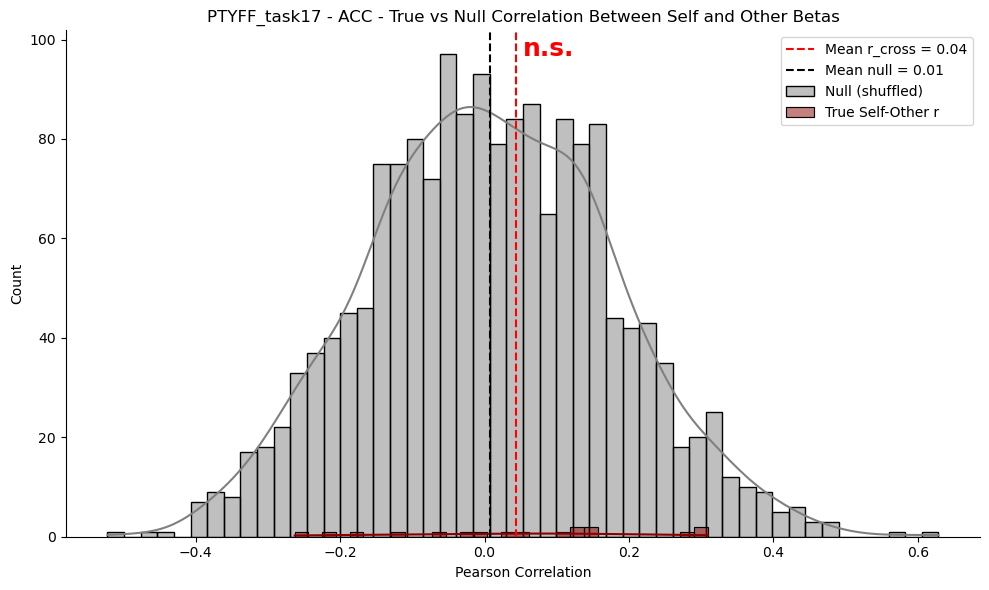

✅ HIPPOCAMPUS: Mean r_cross = 0.106
✅ HIPPOCAMPUS: Mean null = 0.004
✅ HIPPOCAMPUS: P-value (null ≥ true) = 0.2930 → n.s.
✅ HIPPOCAMPUS: Effect size = 0.1019


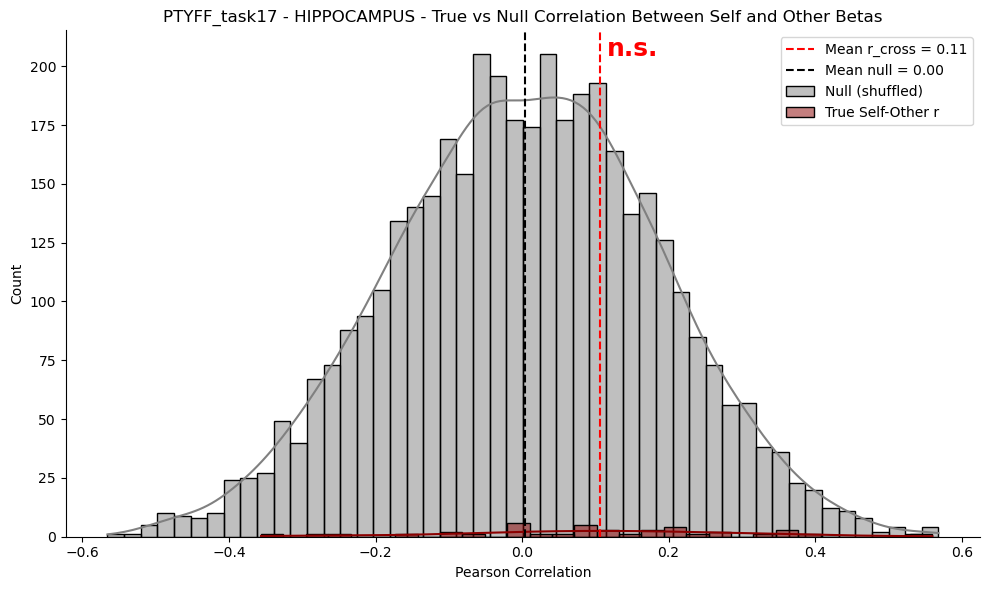


✅ Saved summary CSV to /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200/allwords/PER_PATIENT_REGION_SIGNIFICANCE_SUMMARY.csv
        patient       region  mean_true  mean_null  p_value   sig  effect_size
0  PTYFF_task17          ACC   0.043748   0.007513    0.420  n.s.     0.036235
1  PTYFF_task17  HIPPOCAMPUS   0.105877   0.003936    0.293  n.s.     0.101941


In [143]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200/allwords"
patients = [
    "PTYFF_task17",
    # Add more if you want
]
regions = ["ACC", "HIPPOCAMPUS"]

all_results = []

for patient in patients:
    print(f"\n============================")
    print(f"🧠 Patient: {patient}")
    print(f"============================")

    for region in regions:
        region_path = os.path.join(
            results_root,
            patient,
            f"{region}_RELIABILITY_RESULTS.pkl"
        )
        if not os.path.isfile(region_path):
            print(f"⚠️ Missing {region} results for {patient}")
            continue

        # === Load this patient's region results ===
        with open(region_path, "rb") as f:
            data = pickle.load(f)

        # === Extract per-neuron true r_cross and nulls ===
        true_r_cross = []
        all_null_samples = []

        for entry in data:
            r_cross = entry.get('r_cross')
            null_dist = entry.get('null_distribution')

            if r_cross is not None and not pd.isna(r_cross):
                true_r_cross.append(r_cross)

            if isinstance(null_dist, (list, np.ndarray)):
                clean_nulls = [v for v in null_dist if not pd.isna(v)]
                all_null_samples.extend(clean_nulls)

        # === Check valid data ===
        if not true_r_cross or not all_null_samples:
            print(f"⚠️ No valid data for {patient} - {region}, skipping.")
            continue

        # === Compute mean values ===
        mean_true = np.mean(true_r_cross)
        mean_null = np.mean(all_null_samples)

        # === Permutation-style p-value: how often null ≥ true mean? ===
        p_value = np.mean(np.array(all_null_samples) >= mean_true)

        # === Significance star ===
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            sig = 'n.s.'

        effect_size = mean_true - mean_null

        # === Print result ===
        print(f"✅ {region}: Mean r_cross = {mean_true:.3f}")
        print(f"✅ {region}: Mean null = {mean_null:.3f}")
        print(f"✅ {region}: P-value (null ≥ true) = {p_value:.4f} → {sig}")
        print(f"✅ {region}: Effect size = {effect_size:.4f}")

        # === Save result for summary ===
        all_results.append({
            'patient': patient,
            'region': region,
            'mean_true': mean_true,
            'mean_null': mean_null,
            'p_value': p_value,
            'sig': sig,
            'effect_size': effect_size
        })

        # === Optional plot ===
        plt.figure(figsize=(10, 6))
        sns.histplot(all_null_samples, bins=50, color='gray', label='Null (shuffled)', kde=True)
        sns.histplot(true_r_cross, bins=30, color='darkred', label='True Self-Other r', kde=True)
        plt.axvline(mean_true, color='red', linestyle='--', label=f'Mean r_cross = {mean_true:.2f}')
        plt.axvline(mean_null, color='black', linestyle='--', label=f'Mean null = {mean_null:.2f}')
        ymax = plt.ylim()[1]
        plt.text(mean_true + 0.01, ymax * 0.95, sig, color='red', fontsize=18, fontweight='bold')
        plt.title(f"{patient} - {region} - True vs Null Correlation Between Self and Other Betas")
        plt.xlabel("Pearson Correlation")
        plt.ylabel("Count")
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()

# === Save summary to CSV ===
if all_results:
    df_summary = pd.DataFrame(all_results)
    summary_csv_path = os.path.join(results_root, "PER_PATIENT_REGION_SIGNIFICANCE_SUMMARY.csv")
    df_summary.to_csv(summary_csv_path, index=False)
    print(f"\n✅ Saved summary CSV to {summary_csv_path}")
    print(df_summary)
else:
    print("\n⚠️ No results to save!")


In [150]:
all_null_samples

[np.float64(-0.038418930985826535),
 np.float64(0.19544538177954054),
 np.float64(-0.15867262789420733),
 np.float64(-0.07201306015583508),
 np.float64(-0.19701004475532843),
 np.float64(-0.06425764385194367),
 np.float64(-0.2442222998524284),
 np.float64(-0.11475872726990655),
 np.float64(0.2239897014711263),
 np.float64(0.23173840846197702),
 np.float64(0.23051726761511956),
 np.float64(-0.10642823630826484),
 np.float64(-0.30797644138855984),
 np.float64(-0.020425781844271237),
 np.float64(0.09382085881278669),
 np.float64(0.04136634258629796),
 np.float64(0.03162581680503505),
 np.float64(0.12271161842469383),
 np.float64(-0.16557348313221512),
 np.float64(-0.27726430561512894),
 np.float64(0.0632074270331813),
 np.float64(0.23341967528798868),
 np.float64(0.019939123408371274),
 np.float64(0.1601975630963829),
 np.float64(-0.08742536237296941),
 np.float64(-0.1834246171309556),
 np.float64(0.22040214299488167),
 np.float64(0.02693864069772466),
 np.float64(0.003514182374259473),
 

## Bert

In [132]:
patients = [
    # "PTYEU_task147",
    "PTYFF_task17",
    # "PTYFG_task18",
    # "PTYFI_task81",
    # "PTYFA_task25",
    # "PTYFK_task40",
    # "PTYEY_task86",
    # "PTYEV_task37",
    # "PTYEZ_task60",
    # "PTYFC_task28"
]
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200/allwords"


all_corr_dfs = []
regions = ["ACC", "HIPPOCAMPUS"]

for patient in patients:
    for region in regions:
        patient_dir = os.path.join(results_root, patient)
        csv_path = os.path.join(patient_dir, f"{region}_SELF_OTHER_CORRELATION.csv")
        if os.path.isfile(csv_path):
            df = pd.read_csv(csv_path)
            df['patient'] = patient
            all_corr_dfs.append(df)
        else:
            print(f"⚠️ Missing file for {patient} region {region}: {csv_path}")

if not all_corr_dfs:
    raise ValueError("❌ No correlation CSVs found for any patient!")

# Combine into one big DataFrame
combined_df = pd.concat(all_corr_dfs, ignore_index=True)
print(combined_df.head())


   neuron_index  true_corr region       patient
0             0   0.301699    ACC  PTYFF_task17
1             1   0.058828    ACC  PTYFF_task17
2             2   0.162551    ACC  PTYFF_task17
3             3   0.270891    ACC  PTYFF_task17
4             4   0.342320    ACC  PTYFF_task17


# Neuron by neuron correlations

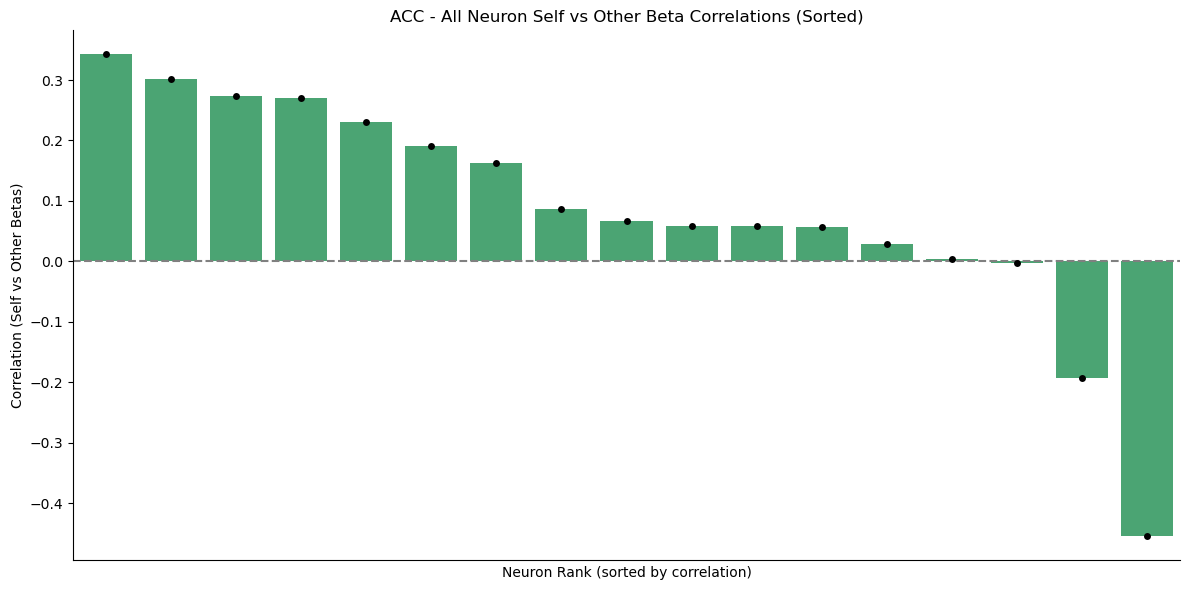

In [133]:
# Filter ACC
df_acc = combined_df[combined_df['region'] == 'ACC'].copy()
df_acc = df_acc.sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_acc['rank'] = df_acc.index + 1  # Simple rank

plt.figure(figsize=(12, 6))
sns.barplot(data=df_acc, x='rank', y='true_corr', color='mediumseagreen')
sns.stripplot(data=df_acc, x='rank', y='true_corr', color='black', size=5, jitter=False)

plt.title('ACC - All Neuron Self vs Other Beta Correlations (Sorted)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Neuron Rank (sorted by correlation)')
plt.ylabel('Correlation (Self vs Other Betas)')
plt.xticks([])
sns.despine()
plt.tight_layout()
plt.show()


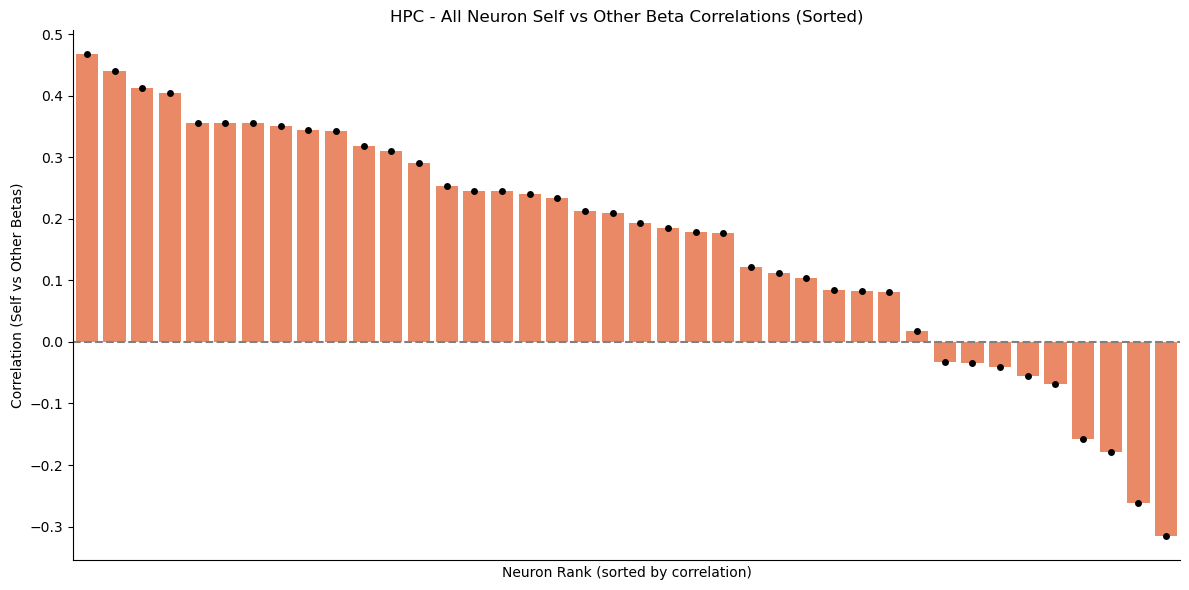

In [134]:
df_hpc = combined_df[combined_df['region'].str.upper().isin(['HPC', 'HIPPOCAMPUS'])].copy()
df_hpc = df_hpc.sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_hpc['rank'] = df_hpc.index + 1

plt.figure(figsize=(12, 6))
sns.barplot(data=df_hpc, x='rank', y='true_corr', color='coral')
sns.stripplot(data=df_hpc, x='rank', y='true_corr', color='black', size=5, jitter=False)

plt.title('HPC - All Neuron Self vs Other Beta Correlations (Sorted)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Neuron Rank (sorted by correlation)')
plt.ylabel('Correlation (Self vs Other Betas)')
plt.xticks([])
sns.despine()
plt.tight_layout()
plt.show()


In [140]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200/allwords"
patients = [
    "PTYFF_task17",
]
regions = ["ACC", "HIPPOCAMPUS"]

# === ACCUMULATORS BY REGION ===
all_r_cross_by_region = {r: [] for r in regions}
all_nulls_by_region = {r: [] for r in regions}
pooled_metrics_by_region = {r: [] for r in regions}

# === LOAD ALL PATIENTS / REGIONS ===
for patient in patients:
    for region in regions:
        path = os.path.join(results_root, patient, f"{region}_RELIABILITY_RESULTS.pkl")
        if not os.path.isfile(path):
            print(f"⚠️ Missing: {path}")
            continue

        with open(path, "rb") as f:
            data = pickle.load(f)

        for entry in data:
            if not all(k in entry for k in ['r_self', 'r_other', 'r_cross', 'null_distribution']):
                continue

            region_upper = region.upper()

            # ✅ append r_cross
            if not pd.isna(entry['r_cross']):
                all_r_cross_by_region[region_upper].append(entry['r_cross'])

            # ✅ append entire null_distribution *as a list*
            nd = entry['null_distribution']
            if isinstance(nd, (list, np.ndarray)) and len(nd) > 0:
                all_nulls_by_region[region_upper].append(list(nd))   # Make sure it's list
            else:
                print(f"⚠️ Skipped bad null_distribution for {region_upper} in {patient}: {nd}")

            # ✅ Violinplot metrics
            for metric in ['r_self', 'r_other', 'r_cross']:
                val = entry.get(metric)
                if val is not None and not pd.isna(val):
                    pooled_metrics_by_region[region_upper].append({
                        'patient': patient,
                        'neuron': entry.get('neuron', np.nan),
                        'metric': metric,
                        'correlation': val
                    })

# === Summary check ===
print("\n✅ === Loaded Data Summary ===")
for region in regions:
    print(f"{region}:")
    print(f"  Neurons with r_cross: {len(all_r_cross_by_region[region])}")
    print(f"  Neurons with null distributions: {len(all_nulls_by_region[region])}")
    print(f"  Total violinplot entries: {len(pooled_metrics_by_region[region])}")



✅ === Loaded Data Summary ===
ACC:
  Neurons with r_cross: 17
  Neurons with null distributions: 17
  Total violinplot entries: 51
HIPPOCAMPUS:
  Neurons with r_cross: 40
  Neurons with null distributions: 40
  Total violinplot entries: 120



=== REGION: ACC ===


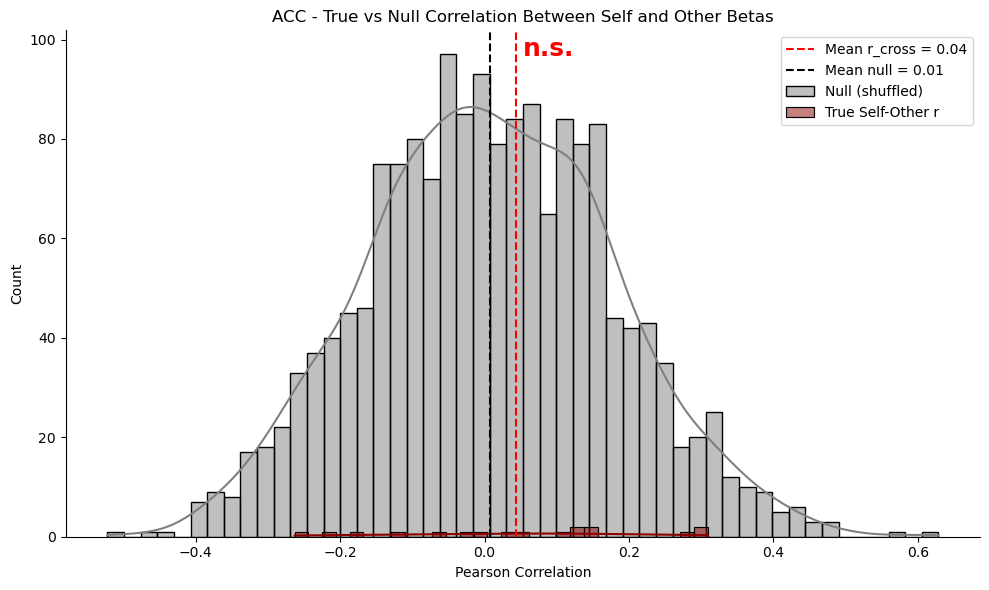

✅ ACC: Mean r_cross = 0.044
✅ ACC: Mean null = 0.008
✅ ACC: P-value (null ≥ true) = 0.4200 → n.s.
✅ ACC: Effect size = 0.0362


/tmp/ipykernel_1503371/1343972060.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')


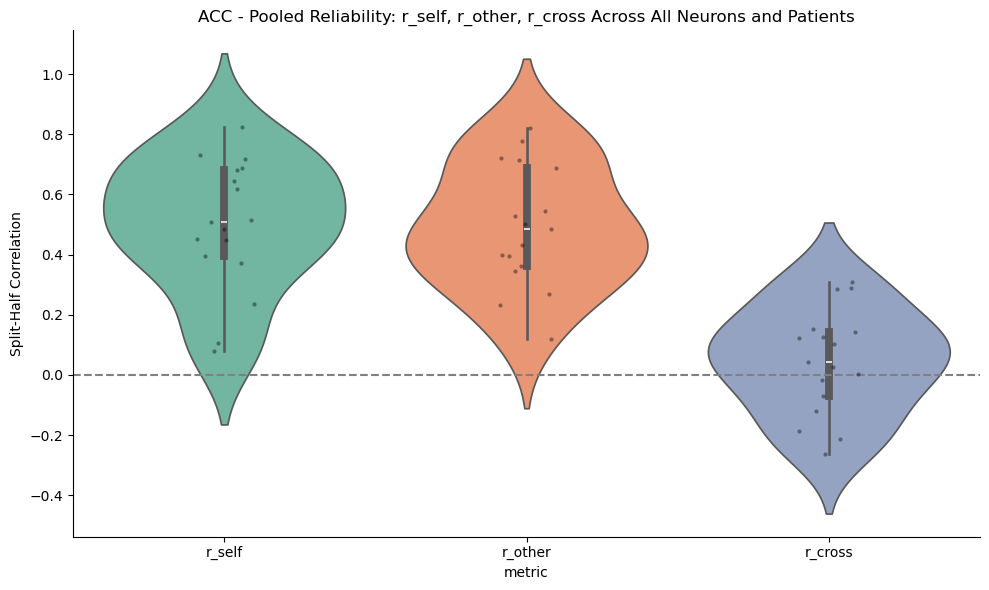


=== REGION: HIPPOCAMPUS ===


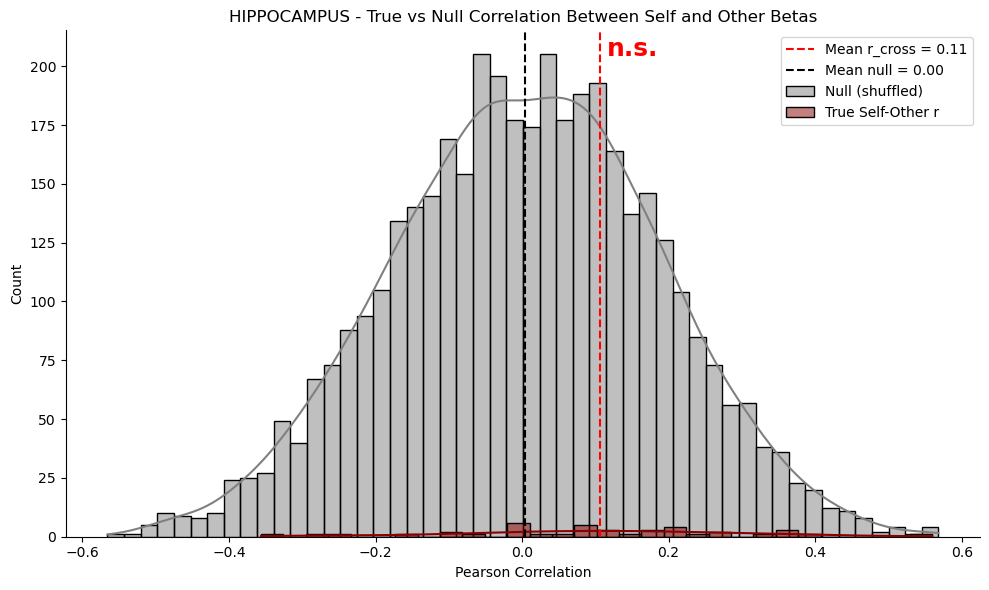

✅ HIPPOCAMPUS: Mean r_cross = 0.106
✅ HIPPOCAMPUS: Mean null = 0.004
✅ HIPPOCAMPUS: P-value (null ≥ true) = 0.2930 → n.s.
✅ HIPPOCAMPUS: Effect size = 0.1019


/tmp/ipykernel_1503371/1343972060.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')


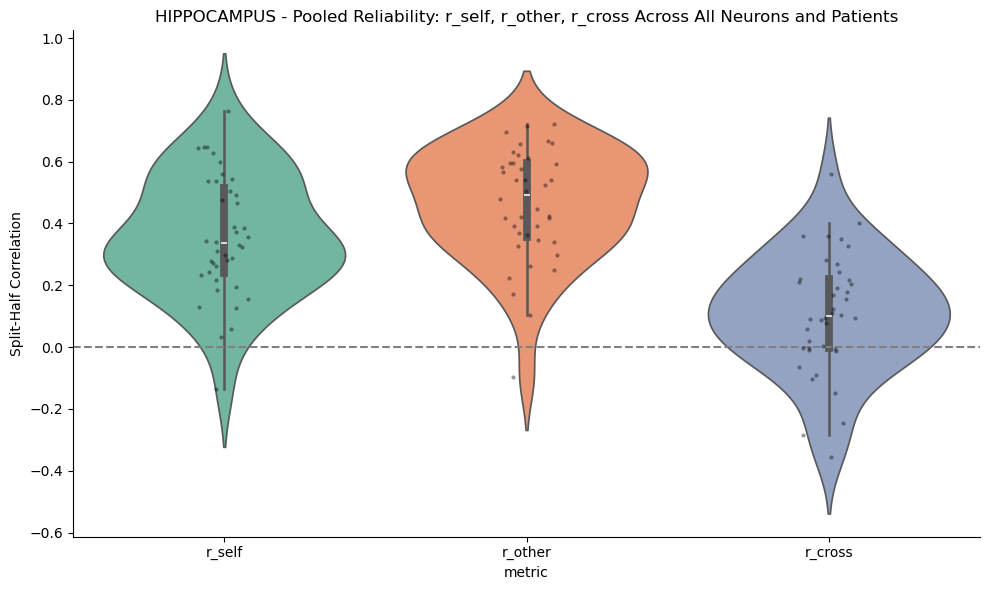

In [142]:
for region in regions:
    print(f"\n=== REGION: {region} ===")

    # Get true r_cross values
    true_r_cross = all_r_cross_by_region.get(region, [])
    true_r_cross = [v for v in true_r_cross if not pd.isna(v)]

    # Get null distributions for all neurons
    null_distributions = all_nulls_by_region.get(region, [])
    null_distributions = [
        [v for v in nd if not pd.isna(v)]
        for nd in null_distributions
        if isinstance(nd, (list, np.ndarray)) and len(nd) > 0
    ]

    if not true_r_cross or not null_distributions:
        print(f"⚠️ No valid data for region {region}, skipping.")
        continue

    # Flatten all null samples across neurons
    all_null_samples = np.concatenate(null_distributions)

    # Compute mean of true r_cross across neurons
    mean_true = np.mean(true_r_cross)

    # Compute mean of all pooled null samples
    mean_null = np.mean(all_null_samples)

    # Permutation-style p-value: how often null ≥ true mean?
    p_value = np.mean(all_null_samples >= mean_true)

    # Significance star
    sig = ('***' if p_value < 0.001 else
           '**' if p_value < 0.01 else
           '*' if p_value < 0.05 else 'n.s.')

    # --- Plot exactly like your single-region version ---
    plt.figure(figsize=(10, 6))
    sns.histplot(all_null_samples, bins=50, color='gray', label='Null (shuffled)', kde=True)
    sns.histplot(true_r_cross, bins=30, color='darkred', label='True Self-Other r', kde=True)

    plt.axvline(mean_true, color='red', linestyle='--', label=f'Mean r_cross = {mean_true:.2f}')
    plt.axvline(mean_null, color='black', linestyle='--', label=f'Mean null = {mean_null:.2f}')

    ymax = plt.ylim()[1]
    plt.text(mean_true + 0.01, ymax * 0.95, sig, color='red', fontsize=18, fontweight='bold')

    plt.title(f"{region} - True vs Null Correlation Between Self and Other Betas")
    plt.xlabel("Pearson Correlation")
    plt.ylabel("Count")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Print record
    print(f"✅ {region}: Mean r_cross = {mean_true:.3f}")
    print(f"✅ {region}: Mean null = {mean_null:.3f}")
    print(f"✅ {region}: P-value (null ≥ true) = {p_value:.4f} → {sig}")
    effect_size = mean_true - mean_null
    print(f"✅ {region}: Effect size = {effect_size:.4f}")




    # --- PART 2️⃣ - Violinplot of r_self/r_other/r_cross ---
    metrics_list = pooled_metrics_by_region.get(region, [])
    if not metrics_list:
        print(f"⚠️ No data for region {region}, skipping violinplot.")
        continue

    df_region_metrics = pd.DataFrame(metrics_list)

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')
    sns.stripplot(data=df_region_metrics, x='metric', y='correlation', color='black', alpha=0.4, jitter=True, size=3)
    plt.title(f"{region} - Pooled Reliability: r_self, r_other, r_cross Across All Neurons and Patients")
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel("Split-Half Correlation")
    sns.despine()
    plt.tight_layout()
    plt.show()


# Word2Vec

In [67]:
patients = [
    "PTYEU_task147",
    "PTYFF_task17",
    "PTYFG_task18",
    "PTYFI_task81",
    "PTYFA_task25",
    "PTYFK_task40",
    "PTYEY_task86",
    "PTYEV_task37",
    "PTYEZ_task60",
    "PTYFC_task28"
]
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTBERT0/allwords"


all_corr_dfs = []
regions = ["ACC", "HIPPOCAMPUS"]

for patient in patients:
    for region in regions:
        patient_dir = os.path.join(results_root, patient)
        csv_path = os.path.join(patient_dir, f"{region}_SELF_OTHER_CORRELATION.csv")
        if os.path.isfile(csv_path):
            df = pd.read_csv(csv_path)
            df['patient'] = patient
            all_corr_dfs.append(df)
        else:
            print(f"⚠️ Missing file for {patient} region {region}: {csv_path}")

if not all_corr_dfs:
    raise ValueError("❌ No correlation CSVs found for any patient!")

# Combine into one big DataFrame
combined_df = pd.concat(all_corr_dfs, ignore_index=True)
print(combined_df.head())


⚠️ Missing file for PTYEY_task86 region ACC: /projects/bhayden/anilu/Language_docs/RegressionRESULTSword2vec0/allwords/PTYEY_task86/ACC_SELF_OTHER_CORRELATION.csv
   neuron_index  true_corr region        patient
0             0   0.376668    ACC  PTYEU_task147
1             1   0.205912    ACC  PTYEU_task147
2             2   0.466524    ACC  PTYEU_task147
3             3   0.493712    ACC  PTYEU_task147
4             4   0.580982    ACC  PTYEU_task147


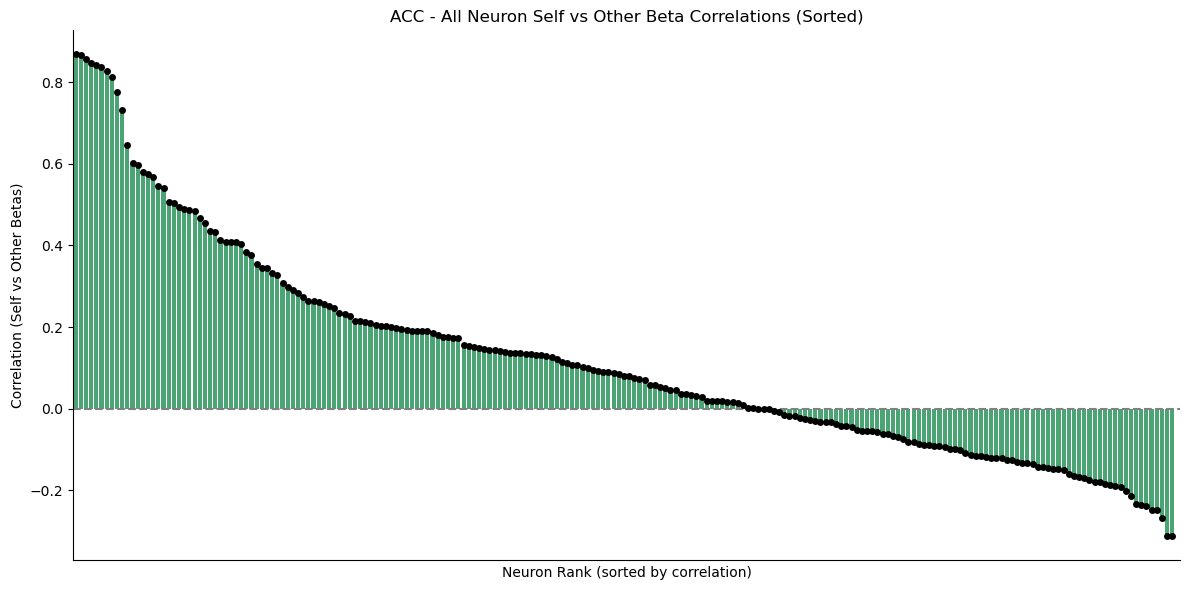

In [68]:
# Filter ACC
df_acc = combined_df[combined_df['region'] == 'ACC'].copy()
df_acc = df_acc.sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_acc['rank'] = df_acc.index + 1  # Simple rank

plt.figure(figsize=(12, 6))
sns.barplot(data=df_acc, x='rank', y='true_corr', color='mediumseagreen')
sns.stripplot(data=df_acc, x='rank', y='true_corr', color='black', size=5, jitter=False)

plt.title('ACC - All Neuron Self vs Other Beta Correlations (Sorted)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Neuron Rank (sorted by correlation)')
plt.ylabel('Correlation (Self vs Other Betas)')
plt.xticks([])
sns.despine()
plt.tight_layout()
plt.show()


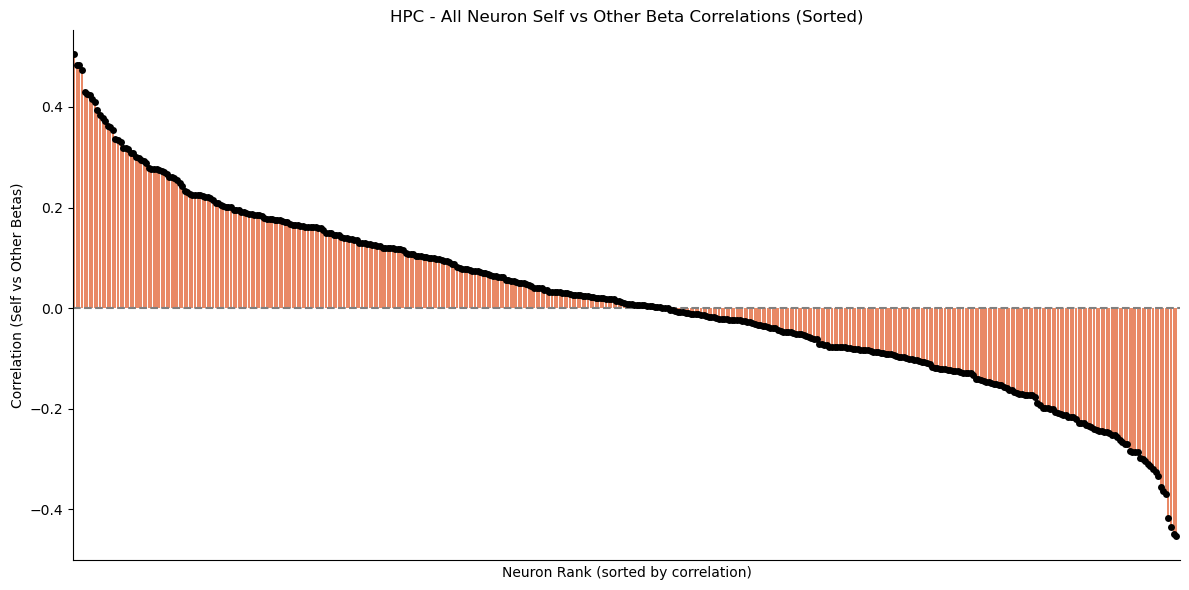

In [49]:
df_hpc = combined_df[combined_df['region'].str.upper().isin(['HPC', 'HIPPOCAMPUS'])].copy()
df_hpc = df_hpc.sort_values(by='true_corr', ascending=False).reset_index(drop=True)
df_hpc['rank'] = df_hpc.index + 1

plt.figure(figsize=(12, 6))
sns.barplot(data=df_hpc, x='rank', y='true_corr', color='coral')
sns.stripplot(data=df_hpc, x='rank', y='true_corr', color='black', size=5, jitter=False)

plt.title('HPC - All Neuron Self vs Other Beta Correlations (Sorted)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Neuron Rank (sorted by correlation)')
plt.ylabel('Correlation (Self vs Other Betas)')
plt.xticks([])
sns.despine()
plt.tight_layout()
plt.show()


In [69]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSword2vec0/allwords"
patients = [
    "PTYEU_task147",
    "PTYFF_task17",
    "PTYFG_task18",
    "PTYFI_task81",
    "PTYFA_task25",
    "PTYFK_task40",
    "PTYEY_task86",
    "PTYEV_task37",
    "PTYEZ_task60",
    "PTYFC_task28"
]
regions = ["ACC", "HIPPOCAMPUS"]

# === ACCUMULATORS BY REGION ===
all_r_cross_by_region = {r: [] for r in regions}
all_nulls_by_region = {r: [] for r in regions}
pooled_metrics_by_region = {r: [] for r in regions}

# === LOAD ALL PATIENTS / REGIONS ===
for patient in patients:
    for region in regions:
        path = os.path.join(results_root, patient, f"{region}_RELIABILITY_RESULTS.pkl")
        if not os.path.isfile(path):
            print(f"⚠️ Missing: {path}")
            continue

        with open(path, "rb") as f:
            data = pickle.load(f)

        for entry in data:
            if ('r_self' in entry) and ('r_other' in entry) and ('r_cross' in entry):
                region_upper = region.upper()

                # Save null vs true
                all_r_cross_by_region[region_upper].append(entry['r_cross'])
                all_nulls_by_region[region_upper].extend(entry.get('null_distribution', []))

                # Save for violinplot
                pooled_metrics_by_region[region_upper].append({
                    'patient': patient,
                    'neuron': entry.get('neuron', np.nan),
                    'metric': 'r_self',
                    'correlation': entry['r_self']
                })
                pooled_metrics_by_region[region_upper].append({
                    'patient': patient,
                    'neuron': entry.get('neuron', np.nan),
                    'metric': 'r_other',
                    'correlation': entry['r_other']
                })
                pooled_metrics_by_region[region_upper].append({
                    'patient': patient,
                    'neuron': entry.get('neuron', np.nan),
                    'metric': 'r_cross',
                    'correlation': entry['r_cross']
                })

# === Summary check ===
print("\n✅ === Loaded Data Summary ===")
for region in regions:
    print(f"{region}:")
    print(f"  r_cross count: {len(all_r_cross_by_region[region])}")
    print(f"  null samples: {len(all_nulls_by_region[region])}")
    print(f"  violinplot entries: {len(pooled_metrics_by_region[region])}")


⚠️ Missing: /projects/bhayden/anilu/Language_docs/RegressionRESULTSword2vec0/allwords/PTYEY_task86/ACC_RELIABILITY_RESULTS.pkl

✅ === Loaded Data Summary ===
ACC:
  r_cross count: 214
  null samples: 21400
  violinplot entries: 642
HIPPOCAMPUS:
  r_cross count: 442
  null samples: 44200
  violinplot entries: 1326



=== REGION: ACC ===


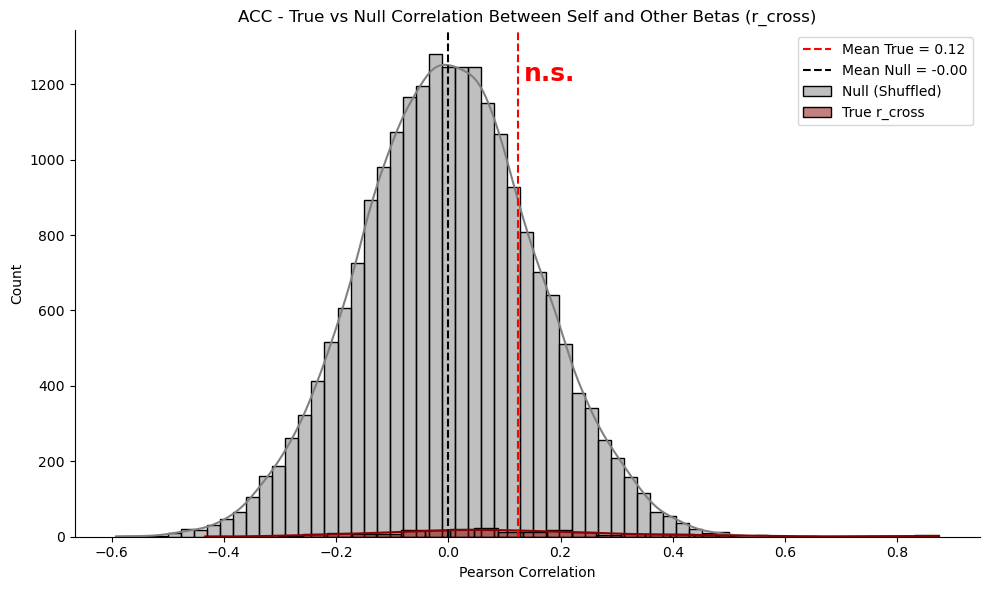

✅ ACC: mean_true = 0.124, mean_null = -0.000, p = 0.2094


/tmp/ipykernel_1349407/3972733666.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')


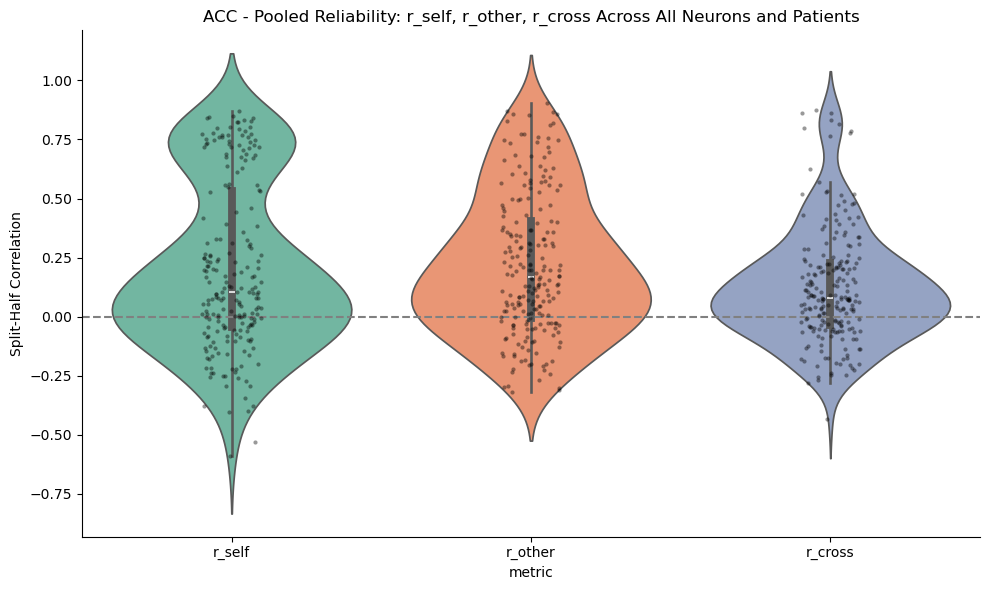


=== REGION: HIPPOCAMPUS ===


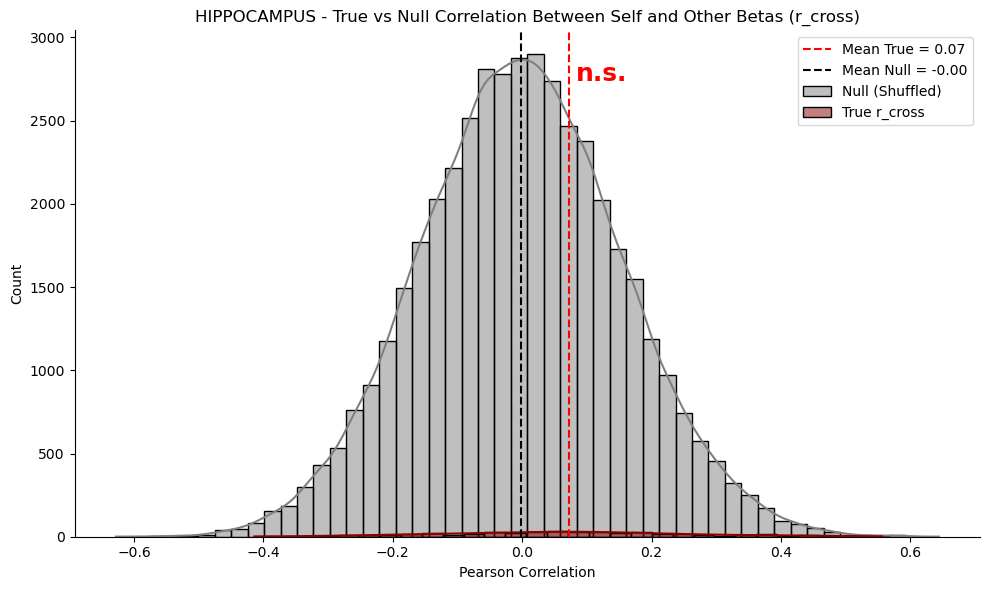

✅ HIPPOCAMPUS: mean_true = 0.072, mean_null = -0.002, p = 0.3146


/tmp/ipykernel_1349407/3972733666.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')


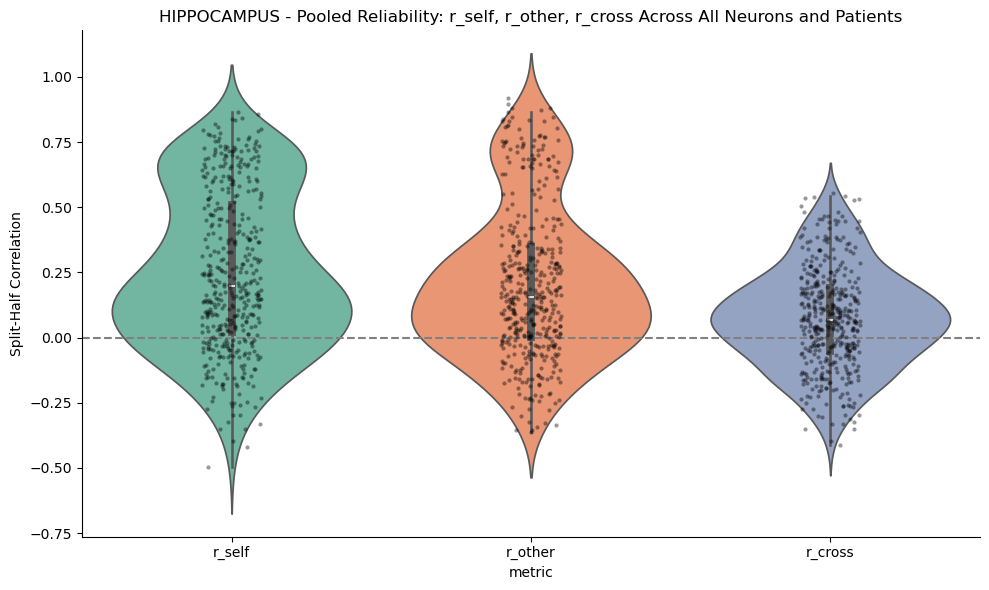

In [70]:
for region in regions:
    print(f"\n=== REGION: {region} ===")

    # --- PART 1️⃣ - Histogram of Null vs True r_cross ---

    true_r_cross = all_r_cross_by_region.get(region, [])
    null_pool = all_nulls_by_region.get(region, [])

    # Remove nans
    true_r_cross = [v for v in true_r_cross if not pd.isna(v)]
    null_pool = [v for v in null_pool if not pd.isna(v)]

    if not true_r_cross or not null_pool:
        print(f"⚠️ No valid data for region {region}, skipping histogram.")
        continue

    mean_true = np.mean(true_r_cross)
    mean_null = np.mean(null_pool)

    # Permutation-style p-value
    p_value = np.mean(np.array(null_pool) >= mean_true)
    sig = ('***' if p_value < 0.001 else
        '**' if p_value < 0.01 else
        '*' if p_value < 0.05 else 'n.s.')

    plt.figure(figsize=(10, 6))
    sns.histplot(null_pool, bins=50, color='gray', label='Null (Shuffled)', kde=True)
    sns.histplot(true_r_cross, bins=30, color='darkred', label='True r_cross', kde=True)

    # Add vertical mean lines only if valid
    if not np.isnan(mean_true):
        plt.axvline(mean_true, color='red', linestyle='--', label=f'Mean True = {mean_true:.2f}')
    if not np.isnan(mean_null):
        plt.axvline(mean_null, color='black', linestyle='--', label=f'Mean Null = {mean_null:.2f}')

    # Add significance star
    plt.text(mean_true + 0.01, plt.ylim()[1]*0.9, sig, color='red', fontsize=18, fontweight='bold')

    plt.title(f"{region} - True vs Null Correlation Between Self and Other Betas (r_cross)")
    plt.xlabel("Pearson Correlation")
    plt.ylabel("Count")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(f"✅ {region}: mean_true = {mean_true:.3f}, mean_null = {mean_null:.3f}, p = {p_value:.4f}")


    # --- PART 2️⃣ - Violinplot of r_self/r_other/r_cross ---
    metrics_list = pooled_metrics_by_region.get(region, [])
    if not metrics_list:
        print(f"⚠️ No data for region {region}, skipping violinplot.")
        continue

    df_region_metrics = pd.DataFrame(metrics_list)

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_region_metrics, x='metric', y='correlation', inner='box', palette='Set2')
    sns.stripplot(data=df_region_metrics, x='metric', y='correlation', color='black', alpha=0.4, jitter=True, size=3)
    plt.title(f"{region} - Pooled Reliability: r_self, r_other, r_cross Across All Neurons and Patients")
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel("Split-Half Correlation")
    sns.despine()
    plt.tight_layout()
    plt.show()


# Semantic clusters

def run_clusterwise_cosine_distance(
    X_self, X_other, Y_self, Y_other,
    metadata_self, metadata_other,
    cluster_column, region_name,
    patient_id, n_components,
    results_root,
    function_word_cluster_id=4,
    balance_function_words=True,
    min_trials_per_condition=10,
    print_trial_counts=True,
    balance_all_clusters=False,
    soft_balance=False
):
    import os
    import pickle
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics.pairwise import cosine_similarity

    if X_self.shape[0] == 0 or X_other.shape[0] == 0:
        print(f"⚠️ Empty X matrices for region {region_name}, skipping...")
        return
    if Y_self.shape[0] == 0 or Y_other.shape[0] == 0:
        print(f"⚠️ Empty Y matrices for region {region_name}, skipping...")
        return

    metadata_self = metadata_self.copy()
    metadata_other = metadata_other.copy()
    metadata_self["ClusterID"] = metadata_self[cluster_column]
    metadata_other["ClusterID"] = metadata_other[cluster_column]

    cluster_ids = sorted(set(metadata_self["ClusterID"].dropna().unique()) |
                         set(metadata_other["ClusterID"].dropna().unique()))

    cluster_counts = pd.concat([metadata_self, metadata_other])["ClusterID"].value_counts()
    if function_word_cluster_id in cluster_counts:
        second_largest = cluster_counts[cluster_counts.index != function_word_cluster_id].max()
    else:
        second_largest = cluster_counts.max()

    cosine_rows = []
    all_betas = {}

    for cluster_id in tqdm(cluster_ids, desc=f"{region_name} Clusters"):
        idx_self = metadata_self.index[metadata_self["ClusterID"] == cluster_id].tolist()
        idx_other = metadata_other.index[metadata_other["ClusterID"] == cluster_id].tolist()

        if print_trial_counts:
            print(f"📊 Cluster {cluster_id}: self={len(idx_self)}, other={len(idx_other)}")

        # === Skip if either condition has too few trials
        if len(idx_self) < min_trials_per_condition or len(idx_other) < min_trials_per_condition:
            print(f"⚠️ Skipping cluster {cluster_id} due to trial count < {min_trials_per_condition}")
            continue

        # === Balancing logic ===
        if balance_all_clusters or (balance_function_words and cluster_id == function_word_cluster_id):
            max_trials = min(len(idx_self), len(idx_other))
            if not soft_balance:
                idx_self = np.random.choice(idx_self, max_trials, replace=False)
                idx_other = np.random.choice(idx_other, max_trials, replace=False)
            else:
                min_len = min(len(idx_self), len(idx_other))
                max_len = max(len(idx_self), len(idx_other))
                if max_len > 1.75 * min_len:  # heuristic soft threshold
                    idx_self = np.random.choice(idx_self, min_len, replace=False)
                    idx_other = np.random.choice(idx_other, min_len, replace=False)

        Xs = X_self[idx_self]
        Ys = Y_self[idx_self]
        Xo = X_other[idx_other]
        Yo = Y_other[idx_other]

        if Xs.shape[0] != Ys.shape[0] or Xo.shape[0] != Yo.shape[0]:
            continue

        scaler_s = StandardScaler().fit(Xs)
        scaler_o = StandardScaler().fit(Xo)
        Xs_scaled = scaler_s.transform(Xs)
        Xo_scaled = scaler_o.transform(Xo)

        n_neurons = Ys.shape[1]
        skipped_neurons = 0
        for neuron in range(n_neurons):
            model_s = Ridge(alpha=1.0).fit(Xs_scaled, Ys[:, neuron])
            model_o = Ridge(alpha=1.0).fit(Xo_scaled, Yo[:, neuron])

            beta_s = model_s.coef_
            beta_o = model_o.coef_

            if np.allclose(beta_s, 0) or np.allclose(beta_o, 0):
                skipped_neurons += 1

            cos_dist = 1 - cosine_similarity(beta_s.reshape(1, -1), beta_o.reshape(1, -1))[0, 0]

            cosine_rows.append({
                "region": region_name,
                "cluster_id": cluster_id,
                "neuron": neuron,
                "cosine_distance": cos_dist
            })

            if cluster_id not in all_betas:
                all_betas[cluster_id] = {"self": [], "other": []}
            all_betas[cluster_id]["self"].append(beta_s)
            all_betas[cluster_id]["other"].append(beta_o)

        if skipped_neurons > 0:
            print(f"⚠️ Skipped {skipped_neurons} all-zero neurons in cluster {cluster_id} ({region_name})")

    # === SAVE RESULTS ===
    patient_dir = os.path.join(results_root, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    cosine_df = pd.DataFrame(cosine_rows)
    cosine_df.to_csv(os.path.join(patient_dir, f"{region_name}_clusterwise_cosine_distances.csv"), index=False)

    with open(os.path.join(patient_dir, f"{region_name}_clusterwise_raw_betas.pkl"), "wb") as f:
        pickle.dump(all_betas, f)

    flat_rows = []
    for cluster_id, beta_sets in all_betas.items():
        for condition in ["self", "other"]:
            for neuron_idx, beta_vec in enumerate(beta_sets[condition]):
                flat_rows.append({
                    "region": region_name,
                    "cluster_id": cluster_id,
                    "neuron": neuron_idx,
                    "condition": condition,
                    **{f"beta_{i}": b for i, b in enumerate(beta_vec)}
                })

    flat_df = pd.DataFrame(flat_rows)
    flat_df.to_csv(os.path.join(patient_dir, f"{region_name}_clusterwise_raw_betas.csv"), index=False)

    print(f"✅ Saved clusterwise cosine distances for {region_name}")
    print(f"✅ Saved raw beta coefficients for {region_name}")


# THis version only does ridge, not poisson

def run_clusterwise_cosine_distance(
    X_self, X_other, Y_self, Y_other,
    metadata_self, metadata_other,
    cluster_column, region_name,
    patient_id, n_components,
    results_root,
    function_word_cluster_id=4,
    balance_function_words=True
):
    import os
    import pickle
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics.pairwise import cosine_similarity

    if X_self.shape[0] == 0 or X_other.shape[0] == 0:
        print(f"⚠️ Empty X matrices for region {region_name}, skipping...")
        return
    if Y_self.shape[0] == 0 or Y_other.shape[0] == 0:
        print(f"⚠️ Empty Y matrices for region {region_name}, skipping...")
        return

    metadata_self = metadata_self.copy()
    metadata_other = metadata_other.copy()
    metadata_self["ClusterID"] = metadata_self[cluster_column]
    metadata_other["ClusterID"] = metadata_other[cluster_column]

    cluster_ids = sorted(set(metadata_self["ClusterID"].dropna().unique()) |
                         set(metadata_other["ClusterID"].dropna().unique()))

    # Figure out how to balance the function word cluster if needed
    cluster_counts = pd.concat([metadata_self, metadata_other])["ClusterID"].value_counts()
    if function_word_cluster_id in cluster_counts:
        second_largest = cluster_counts[cluster_counts.index != function_word_cluster_id].max()
    else:
        second_largest = cluster_counts.max()

    cosine_rows = []
    all_betas = {}

    for cluster_id in tqdm(cluster_ids, desc=f"{region_name} Clusters"):
        idx_self = metadata_self.index[metadata_self["ClusterID"] == cluster_id].tolist()
        idx_other = metadata_other.index[metadata_other["ClusterID"] == cluster_id].tolist()

        # Skip only if one side has no data
        if len(idx_self) == 0 or len(idx_other) == 0:
            continue

        # Optionally balance function word cluster
        if balance_function_words and cluster_id == function_word_cluster_id:
            max_self = min(len(idx_self), second_largest)
            max_other = min(len(idx_other), second_largest)

            if max_self == 0 or max_other == 0:
                continue

            idx_self = np.random.choice(idx_self, max_self, replace=False)
            idx_other = np.random.choice(idx_other, max_other, replace=False)

        Xs = X_self[idx_self]
        Ys = Y_self[idx_self]
        Xo = X_other[idx_other]
        Yo = Y_other[idx_other]

        if Xs.shape[0] != Ys.shape[0] or Xo.shape[0] != Yo.shape[0]:
            continue

        scaler_s = StandardScaler().fit(Xs)
        scaler_o = StandardScaler().fit(Xo)
        Xs_scaled = scaler_s.transform(Xs)
        Xo_scaled = scaler_o.transform(Xo)

        n_neurons = Ys.shape[1]
        skipped_neurons = 0
        for neuron in range(n_neurons):
            model_s = Ridge(alpha=1.0).fit(Xs_scaled, Ys[:, neuron])
            model_o = Ridge(alpha=1.0).fit(Xo_scaled, Yo[:, neuron])

            beta_s = model_s.coef_
            beta_o = model_o.coef_

            # Optional: log but do not skip
            if np.allclose(beta_s, 0) or np.allclose(beta_o, 0):
                skipped_neurons += 1

            cos_dist = 1 - cosine_similarity(beta_s.reshape(1, -1), beta_o.reshape(1, -1))[0, 0]

            cosine_rows.append({
                "region": region_name,
                "cluster_id": cluster_id,
                "neuron": neuron,
                "cosine_distance": cos_dist
            })

            if cluster_id not in all_betas:
                all_betas[cluster_id] = {"self": [], "other": []}
            all_betas[cluster_id]["self"].append(beta_s)
            all_betas[cluster_id]["other"].append(beta_o)

        if skipped_neurons > 0:
            print(f"⚠️ Skipped {skipped_neurons} all-zero neurons in cluster {cluster_id} ({region_name})")

    # === SAVE COSINE DISTANCES
    patient_dir = os.path.join(results_root, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    cosine_df = pd.DataFrame(cosine_rows)
    cosine_df.to_csv(os.path.join(patient_dir, f"{region_name}_clusterwise_cosine_distances.csv"), index=False)

    # === SAVE RAW BETAS (PKL + FLATTENED)
    with open(os.path.join(patient_dir, f"{region_name}_clusterwise_raw_betas.pkl"), "wb") as f:
        pickle.dump(all_betas, f)

    flat_rows = []
    for cluster_id, beta_sets in all_betas.items():
        for condition in ["self", "other"]:
            for neuron_idx, beta_vec in enumerate(beta_sets[condition]):
                flat_rows.append({
                    "region": region_name,
                    "cluster_id": cluster_id,
                    "neuron": neuron_idx,
                    "condition": condition,
                    **{f"beta_{i}": b for i, b in enumerate(beta_vec)}
                })

    flat_df = pd.DataFrame(flat_rows)
    flat_df.to_csv(os.path.join(patient_dir, f"{region_name}_clusterwise_raw_betas.csv"), index=False)

    print(f"✅ Saved clusterwise cosine distances for {region_name}")
    print(f"✅ Saved raw beta coefficients for {region_name}")


# as above but using the poisson ridge logic

In [10]:
def run_clusterwise_cosine_distance(
    X_self, X_other, Y_self, Y_other,
    metadata_self, metadata_other,
    cluster_column, region_name,
    patient_id, n_components,
    results_root,
    function_word_cluster_id=10,
    balance_function_words=True,
    balance_all_clusters=False,
    soft_balance=False,
    soft_balance_target="median",   # "median", "mean", int, or None
    min_trials_per_condition=10,
    cap_large_clusters=True,
    max_size_ratio=5.0,             # e.g. 5x median valid cluster size
    cap_reference="median",         # "median" or "mean"
    random_state=42,
    save_csvs=True,
    save_pickle=True,
    compute_half_splits=False,
    n_jobs=4,
    print_trial_counts=False,
):
    import os
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    from scipy.spatial.distance import cosine as cosine_distance
    from sklearn.model_selection import train_test_split
    from sklearn.exceptions import ConvergenceWarning
    from joblib import Parallel, delayed

    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    rng = np.random.RandomState(random_state)

    out_dir = os.path.join(results_root, patient_id)
    os.makedirs(out_dir, exist_ok=True)

    # -----------------------------
    # helpers
    # -----------------------------
    def _safe_cosine_distance(a, b):
        a = np.asarray(a).ravel()
        b = np.asarray(b).ravel()
        if a.size == 0 or b.size == 0:
            return np.nan
        if np.allclose(a, 0) or np.allclose(b, 0):
            return np.nan
        return cosine_distance(a, b)

    def _choose_target_count(valid_counts, mode):
        valid_counts = np.asarray(valid_counts, dtype=int)
        valid_counts = valid_counts[valid_counts > 0]
        if len(valid_counts) == 0:
            return None

        if mode is None:
            return None
        if isinstance(mode, int):
            return int(mode)
        if mode == "median":
            return int(np.floor(np.median(valid_counts)))
        if mode == "mean":
            return int(np.floor(np.mean(valid_counts)))

        raise ValueError(f"Unknown soft_balance_target: {mode}")

    def _choose_reference_count(valid_counts, mode):
        valid_counts = np.asarray(valid_counts, dtype=int)
        valid_counts = valid_counts[valid_counts > 0]
        if len(valid_counts) == 0:
            return None
        if mode == "median":
            return int(np.floor(np.median(valid_counts)))
        if mode == "mean":
            return int(np.floor(np.mean(valid_counts)))
        raise ValueError(f"Unknown cap_reference: {mode}")

    def _sample_indices(ix, n_keep, rng):
        ix = np.asarray(ix)
        if len(ix) <= n_keep:
            return ix
        return np.sort(rng.choice(ix, size=n_keep, replace=False))

    # -----------------------------
    # cluster ids
    # -----------------------------
    clusters = sorted(
        set(metadata_self[cluster_column].dropna()) |
        set(metadata_other[cluster_column].dropna())
    )

    # -----------------------------
    # first pass: raw counts
    # -----------------------------
    cluster_info = []
    raw_min_counts = []

    for cluster_id in clusters:
        ix_self = metadata_self.index[metadata_self[cluster_column] == cluster_id].to_numpy()
        ix_other = metadata_other.index[metadata_other[cluster_column] == cluster_id].to_numpy()

        n_self_raw = len(ix_self)
        n_other_raw = len(ix_other)
        n_min_raw = min(n_self_raw, n_other_raw)

        cluster_info.append({
            "cluster_id": cluster_id,
            "ix_self_raw": ix_self,
            "ix_other_raw": ix_other,
            "n_self_raw": n_self_raw,
            "n_other_raw": n_other_raw,
            "n_min_raw": n_min_raw,
        })

        if n_self_raw >= min_trials_per_condition and n_other_raw >= min_trials_per_condition:
            raw_min_counts.append(n_min_raw)

    # -----------------------------
    # optional global soft/hard target
    # -----------------------------
    global_target = None
    if soft_balance and balance_all_clusters:
        global_target = _choose_target_count(raw_min_counts, soft_balance_target)
        if global_target is not None:
            global_target = max(global_target, min_trials_per_condition)

    # -----------------------------
    # ratio-based cap for large clusters
    # -----------------------------
    reference_count = _choose_reference_count(raw_min_counts, cap_reference)
    max_allowed_count = None
    if cap_large_clusters and reference_count is not None and max_size_ratio is not None:
        max_allowed_count = int(np.floor(max_size_ratio * reference_count))
        max_allowed_count = max(max_allowed_count, min_trials_per_condition)

    # -----------------------------
    # second pass: build tasks
    # -----------------------------
    tasks = []
    cluster_count_rows = []

    for info in cluster_info:
        cluster_id = info["cluster_id"]
        ix_self = info["ix_self_raw"]
        ix_other = info["ix_other_raw"]
        n_self_raw = info["n_self_raw"]
        n_other_raw = info["n_other_raw"]

        if n_self_raw < min_trials_per_condition or n_other_raw < min_trials_per_condition:
            cluster_count_rows.append({
                "cluster_id": cluster_id,
                "n_self_raw": n_self_raw,
                "n_other_raw": n_other_raw,
                "n_self_used": 0,
                "n_other_used": 0,
                "n_trials_post_balance": 0,
                "kept_for_regression": False,
                "drop_reason": f"below_min_trials_{min_trials_per_condition}",
                "reference_count": reference_count,
                "max_allowed_count": max_allowed_count,
                "size_ratio_to_reference": np.nan,
            })
            continue

        # start with all rows
        ix_self_use = ix_self.copy()
        ix_other_use = ix_other.copy()
        drop_reason = "kept"

        # cap function word cluster first
        if balance_function_words and cluster_id == function_word_cluster_id:
            if max_allowed_count is not None:
                n_target = min(len(ix_self_use), len(ix_other_use), max_allowed_count)
                drop_reason = f"function_word_capped_to_{n_target}"
            else:
                n_target = min(len(ix_self_use), len(ix_other_use))
                drop_reason = f"function_word_balanced_to_{n_target}"

            ix_self_use = _sample_indices(ix_self_use, n_target, rng)
            ix_other_use = _sample_indices(ix_other_use, n_target, rng)

        # cap any overly large clusters to healthy range
        if cap_large_clusters and max_allowed_count is not None:
            n_target_cap = min(len(ix_self_use), len(ix_other_use), max_allowed_count)
            if n_target_cap < len(ix_self_use) or n_target_cap < len(ix_other_use):
                ix_self_use = _sample_indices(ix_self_use, n_target_cap, rng)
                ix_other_use = _sample_indices(ix_other_use, n_target_cap, rng)
                if cluster_id == function_word_cluster_id and balance_function_words:
                    drop_reason = f"function_word_capped_to_{n_target_cap}"
                else:
                    drop_reason = f"ratio_capped_to_{n_target_cap}"

        # optional balance across all clusters
        if balance_all_clusters:
            if soft_balance:
                if global_target is None:
                    global_target = min(len(ix_self_use), len(ix_other_use))
                n_target = min(len(ix_self_use), len(ix_other_use), global_target)
            else:
                n_target = min(raw_min_counts) if len(raw_min_counts) > 0 else min(len(ix_self_use), len(ix_other_use))

            if n_target < min_trials_per_condition:
                cluster_count_rows.append({
                    "cluster_id": cluster_id,
                    "n_self_raw": n_self_raw,
                    "n_other_raw": n_other_raw,
                    "n_self_used": 0,
                    "n_other_used": 0,
                    "n_trials_post_balance": 0,
                    "kept_for_regression": False,
                    "drop_reason": f"balancing_target_below_min_trials_{min_trials_per_condition}",
                    "reference_count": reference_count,
                    "max_allowed_count": max_allowed_count,
                    "size_ratio_to_reference": np.nan,
                })
                continue

            ix_self_use = _sample_indices(ix_self_use, n_target, rng)
            ix_other_use = _sample_indices(ix_other_use, n_target, rng)

            if soft_balance:
                drop_reason = f"soft_balanced_to_{n_target}"
            else:
                drop_reason = f"hard_balanced_to_{n_target}"

        # final arrays
        Xs = X_self[ix_self_use]
        Ys = Y_self[ix_self_use]
        Xo = X_other[ix_other_use]
        Yo = Y_other[ix_other_use]

        n_self_used = Xs.shape[0]
        n_other_used = Xo.shape[0]

        if n_self_used < min_trials_per_condition or n_other_used < min_trials_per_condition:
            cluster_count_rows.append({
                "cluster_id": cluster_id,
                "n_self_raw": n_self_raw,
                "n_other_raw": n_other_raw,
                "n_self_used": n_self_used,
                "n_other_used": n_other_used,
                "n_trials_post_balance": n_self_used + n_other_used,
                "kept_for_regression": False,
                "drop_reason": f"post_sampling_below_min_trials_{min_trials_per_condition}",
                "reference_count": reference_count,
                "max_allowed_count": max_allowed_count,
                "size_ratio_to_reference": np.nan,
            })
            continue

        min_used = min(n_self_used, n_other_used)
        cluster_count_rows.append({
            "cluster_id": cluster_id,
            "n_self_raw": n_self_raw,
            "n_other_raw": n_other_raw,
            "n_self_used": n_self_used,
            "n_other_used": n_other_used,
            "n_trials_post_balance": n_self_used + n_other_used,
            "kept_for_regression": True,
            "drop_reason": drop_reason,
            "reference_count": reference_count,
            "max_allowed_count": max_allowed_count,
            "size_ratio_to_reference": (
                min_used / reference_count if reference_count not in [None, 0] else np.nan
            ),
        })

        n_neurons = Ys.shape[1]
        for neuron_idx in range(n_neurons):
            tasks.append((cluster_id, neuron_idx, Xs, Ys, Xo, Yo, n_self_used, n_other_used))

    cluster_counts_df = pd.DataFrame(cluster_count_rows).sort_values("cluster_id").reset_index(drop=True)

    if print_trial_counts:
        print(f"\n📊 Final cluster counts used for regression: {patient_id} | {region_name}")
        print(cluster_counts_df)

    if save_csvs:
        counts_csv = os.path.join(out_dir, f"{region_name}_cluster_trial_counts.csv")
        cluster_counts_df.to_csv(counts_csv, index=False)
        print(f"✅ Cluster trial counts saved: {counts_csv}")

    # -----------------------------
    # worker
    # -----------------------------
    def process_single_cluster_neuron(cluster_id, neuron_idx, Xs, Ys, Xo, Yo, n_self_used, n_other_used):
        try:
            y_self_neuron = Ys[:, neuron_idx][:, None]
            y_other_neuron = Yo[:, neuron_idx][:, None]

            beta_self = run_poisson_ridge(
                Xs, y_self_neuron,
                patient_id=patient_id,
                neuron_idx=0,
                region_name=region_name,
                n_semantic_dims=n_components,
                results_dir=results_root,
                fast_beta_only=True,
                save_results=False
            ).filter(like="beta_").values.flatten()

            beta_other = run_poisson_ridge(
                Xo, y_other_neuron,
                patient_id=patient_id,
                neuron_idx=0,
                region_name=region_name,
                n_semantic_dims=n_components,
                results_dir=results_root,
                fast_beta_only=True,
                save_results=False
            ).filter(like="beta_").values.flatten()

            cos_dist = _safe_cosine_distance(beta_self, beta_other)
            if not np.isfinite(cos_dist):
                return None, None

            row = {
                "cluster_id": cluster_id,
                "region": region_name,
                "neuron": neuron_idx,
                "cosine_distance": cos_dist,
                "n_self_used": n_self_used,
                "n_other_used": n_other_used,
                "n_trials_post_balance": n_self_used + n_other_used,
            }

            if compute_half_splits:
                try:
                    if Xs.shape[0] < 4 or Xo.shape[0] < 4:
                        row["self_halfsplit_cosine"] = np.nan
                        row["other_halfsplit_cosine"] = np.nan
                    else:
                        Xs1, Xs2, Ys1, Ys2 = train_test_split(
                            Xs, y_self_neuron, test_size=0.5, random_state=random_state
                        )
                        Xo1, Xo2, Yo1, Yo2 = train_test_split(
                            Xo, y_other_neuron, test_size=0.5, random_state=random_state
                        )

                        bs1 = run_poisson_ridge(
                            Xs1, Ys1,
                            patient_id=patient_id,
                            neuron_idx=0,
                            region_name=region_name,
                            n_semantic_dims=n_components,
                            results_dir=results_root,
                            fast_beta_only=True,
                            save_results=False
                        ).filter(like="beta_").values.flatten()

                        bs2 = run_poisson_ridge(
                            Xs2, Ys2,
                            patient_id=patient_id,
                            neuron_idx=0,
                            region_name=region_name,
                            n_semantic_dims=n_components,
                            results_dir=results_root,
                            fast_beta_only=True,
                            save_results=False
                        ).filter(like="beta_").values.flatten()

                        bo1 = run_poisson_ridge(
                            Xo1, Yo1,
                            patient_id=patient_id,
                            neuron_idx=0,
                            region_name=region_name,
                            n_semantic_dims=n_components,
                            results_dir=results_root,
                            fast_beta_only=True,
                            save_results=False
                        ).filter(like="beta_").values.flatten()

                        bo2 = run_poisson_ridge(
                            Xo2, Yo2,
                            patient_id=patient_id,
                            neuron_idx=0,
                            region_name=region_name,
                            n_semantic_dims=n_components,
                            results_dir=results_root,
                            fast_beta_only=True,
                            save_results=False
                        ).filter(like="beta_").values.flatten()

                        row["self_halfsplit_cosine"] = 1 - _safe_cosine_distance(bs1, bs2)
                        row["other_halfsplit_cosine"] = 1 - _safe_cosine_distance(bo1, bo2)

                except Exception as e:
                    row["self_halfsplit_cosine"] = np.nan
                    row["other_halfsplit_cosine"] = np.nan
                    print(f"⚠️ Half-split failed on cluster {cluster_id}, neuron {neuron_idx}: {e}")

            return row, ((cluster_id, neuron_idx), {
                "beta_self": beta_self,
                "beta_other": beta_other
            })

        except Exception as e:
            print(f"❌ Failed on cluster {cluster_id}, neuron {neuron_idx}: {e}")
            return None, None

    # -----------------------------
    # run
    # -----------------------------
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_single_cluster_neuron)(*t) for t in tasks
    )

    # -----------------------------
    # collect
    # -----------------------------
    all_cosine_rows = []
    all_betas = {}

    for row, beta_entry in results:
        if row is not None:
            all_cosine_rows.append(row)
        if beta_entry is not None:
            all_betas[beta_entry[0]] = beta_entry[1]

    cosine_df = pd.DataFrame(all_cosine_rows)

    # -----------------------------
    # save
    # -----------------------------
    if save_csvs and not cosine_df.empty:
        out_csv = os.path.join(out_dir, f"{region_name}_clusterwise_cosine_distances.csv")
        cosine_df.to_csv(out_csv, index=False)
        print(f"✅ Cosine distances saved: {out_csv}")

    if save_pickle:
        out_pkl = os.path.join(out_dir, f"{region_name}_clusterwise_raw_betas.pkl")
        with open(out_pkl, "wb") as f:
            pickle.dump(all_betas, f)
        print(f"✅ Raw betas saved: {out_pkl}")

    return cosine_df, all_betas, cluster_counts_df

# most recent version

In [6]:
def report_cluster_balance(metadata_self, metadata_other, patient_ID, region):
    import pandas as pd
    from scipy.stats import chi2_contingency

    # Combine metadata and create contingency table
    combined = pd.concat([
        metadata_self.assign(condition="self"),
        metadata_other.assign(condition="other")
    ])
    contingency = pd.crosstab(combined["ClusterID"], combined["condition"])

    # Run chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print(f"\n📊 [Trial Balance Diagnostic] Patient: {patient_ID}, Region: {region}")
    print("Contingency table (ClusterID × Condition):")
    print(contingency)
    print(f"Chi² = {chi2:.3f}, p = {p:.4f} (test of independence between cluster and condition)")

    # === Compute standardized residuals
    observed = contingency.values
    residuals = (observed - expected) / np.sqrt(expected)
    residuals_df = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns)

    print("\n📈 Standardized Residuals:")
    print(residuals_df.round(2))

    # Flag clusters with residuals > 2 or < -2
    flagged = (np.abs(residuals_df) > 2)
    if flagged.any().any():
        print("\n🚩 Problematic Clusters (|residual| > 2):")
        for cluster in residuals_df.index[flagged.any(axis=1)]:
            print(f" - Cluster {cluster}: {residuals_df.loc[cluster].to_dict()}")

    return contingency, chi2, p, residuals_df


In [7]:
def minimal_balancing(metadata_self, metadata_other, cluster_column="ClusterID", verbose=True):
    import pandas as pd
    import numpy as np
    from scipy.stats import chi2_contingency

    combined = pd.concat([
        metadata_self.assign(condition="self"),
        metadata_other.assign(condition="other")
    ])
    
    contingency = pd.crosstab(combined[cluster_column], combined["condition"])
    chi2, p, _, expected = chi2_contingency(contingency)
    
    if verbose:
        print("Initial chi² =", round(chi2, 2), "p =", round(p, 4))

    m_self = metadata_self.copy()
    m_other = metadata_other.copy()

    while p < 0.05 and not contingency.empty:
        observed = contingency.values
        residuals = (observed - expected) / np.sqrt(expected)
        max_cluster, max_condition = np.unravel_index(np.abs(residuals).argmax(), residuals.shape)
        problematic_cluster = contingency.index[max_cluster]
        condition_to_downsample = contingency.columns[max_condition]

        if verbose:
            print(f"Downsampling {condition_to_downsample} in cluster {problematic_cluster}")

        if condition_to_downsample == "self":
            target_count = contingency.loc[problematic_cluster, "other"]
            candidates = m_self[m_self[cluster_column] == problematic_cluster]
            if len(candidates) <= target_count:
                break
            idx_to_keep = candidates.sample(target_count, random_state=42).index
            m_self = pd.concat([
                m_self[m_self[cluster_column] != problematic_cluster],
                m_self.loc[idx_to_keep]
            ])
        else:
            target_count = contingency.loc[problematic_cluster, "self"]
            candidates = m_other[m_other[cluster_column] == problematic_cluster]
            if len(candidates) <= target_count:
                break
            idx_to_keep = candidates.sample(target_count, random_state=42).index
            m_other = pd.concat([
                m_other[m_other[cluster_column] != problematic_cluster],
                m_other.loc[idx_to_keep]
            ])

        combined = pd.concat([
            m_self.assign(condition="self"),
            m_other.assign(condition="other")
        ])
        contingency = pd.crosstab(combined[cluster_column], combined["condition"])
        chi2, p, _, expected = chi2_contingency(contingency)

    if verbose:
        print("Final chi² =", round(chi2, 2), "p =", round(p, 4))

    return m_self.reset_index(drop=True), m_other.reset_index(drop=True)


In [23]:
import os
import pickle
import numpy as np
import pandas as pd

# === CONFIG ===
model_type = "BERT"
target_speaker = "SPK1"
speakers = [f"Speaker{i}" for i in range(1, 13)]
regions = ["hippocampus"] #ACC
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords"

patients_to_run = [
    {"patient_ID": "PTYEU_task147", "patient": "ptYEU_task147", "n_components": 10},
    {"patient_ID": "PTYFF_task17", "patient": "ptYFF_task17", "n_components": 10},
    {"patient_ID": "PTYFG_task18", "patient": "ptYFG_task18", "n_components": 10},
    {"patient_ID": "PTYFI_task81", "patient": "ptYFI_task81", "n_components": 10},
    {"patient_ID": "PTYFA_task25", "patient": "ptYFA_task25", "n_components": 10},
    {"patient_ID": "PTYEY_task86", "patient": "ptYEY_task86", "n_components": 10},
    {"patient_ID": "PTYEV_task37", "patient": "ptYEV_task37", "n_components": 10},
    {"patient_ID": "PTYEZ_task60", "patient": "ptYEZ_task60", "n_components": 10},
    {"patient_ID": "PTYFK_task40", "patient": "ptYFK_task40", "n_components": 10},
    {"patient_ID": "PTYFC_task28", "patient": "ptYFC_task28", "n_components": 10},
]

for patient_cfg in patients_to_run:
    patient_ID = patient_cfg["patient_ID"]
    patient = patient_cfg["patient"]
    n_components = patient_cfg["n_components"]

    print(f"\n🧠 Running Clusterwise Only: {patient_ID}")

    if model_type == "BERT":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_aligned_embeddings_withNP.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_{patient}_english_only_dur_150_200_500/"
    elif model_type == "word2vec":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vecW/{patient_ID}_words_word2vec/{patient_ID}_aligned_word2vec_embeddings.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_{patient}_english_only_w2v_150_200_500/"
    else:
        raise NotImplementedError("Only BERT mode supported")

    duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
    cluster_excel = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_filtered_used_rows_withNP_withClusterIDNew.xlsx"
    # duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
    # cluster_excel = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vecW/{patient_ID}_words_word2vec/{patient_ID}_filtered_used_rows_word2vec_withClusterID2.xlsx"

    if not (os.path.isfile(embedding_file) and os.path.isfile(duration_file) and os.path.isfile(cluster_excel)):
        print(f"⚠️ Missing files for {patient_ID}, skipping.")
        continue

    X_self, X_other, df_metadata, _, _ = get_self_and_other_features(
        embedding_file, duration_file, n_components, target_speaker=target_speaker
    )

    spike_data = load_spike_data(speakers, regions, self_base_dir=spike_base_dir, mode="auto")
    if not spike_data:
        continue

    region_Ys = build_Y_matrices(df_metadata, spike_data, regions, target_speaker=target_speaker)

    for region in regions:
        if region not in region_Ys:
            print(f"⚠️ Region {region} not found for {patient_ID}, skipping.")
            continue

        X_cleaned, Y_cleaned = {}, {}
        for cond in ["self", "other"]:
            X = X_self if cond == "self" else X_other
            Y = region_Ys[region][cond]

            if X.shape[0] != Y.shape[0]:
                print(f"⚠️ Shape mismatch for {region}_{cond} in {patient_ID}, skipping.")
                continue

            nan_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
            X_cleaned[cond] = X[nan_mask]
            Y_cleaned[cond] = Y[nan_mask]
            region_Ys[region][cond] = Y_cleaned[cond]  # overwrite for safety
            region_Ys[region][f"indices_{cond}"] = np.where(nan_mask)[0]  # store clean indices

        if any(k not in X_cleaned or k not in Y_cleaned for k in ["self", "other"]):
            print(f"⚠️ Skipping {region} for {patient_ID} due to missing cleaned data.")
            continue

        indices_self = region_Ys[region]["indices_self"]
        indices_other = region_Ys[region]["indices_other"]

        metadata_self = df_metadata.loc[indices_self].reset_index(drop=True)
        metadata_other = df_metadata.loc[indices_other].reset_index(drop=True)

                # Assign cluster ID column before analysis
        if "FinalClusterID" not in metadata_self.columns:
            cluster_info = pd.read_excel(cluster_excel)["FinalClusterID"]
            metadata_self["FinalClusterID"] = cluster_info.loc[indices_self].reset_index(drop=True)
            metadata_other["FinalClusterID"] = cluster_info.loc[indices_other].reset_index(drop=True)

        # ✅ Ensure "ClusterID" exists for both reporting and regression
        metadata_self["ClusterID"] = metadata_self["FinalClusterID"]
        metadata_other["ClusterID"] = metadata_other["FinalClusterID"]
        # metadata_self, metadata_other = minimal_balancing(metadata_self, metadata_other, cluster_column="ClusterID")


        metadata_self, metadata_other = minimal_balancing(
            metadata_self,
            metadata_other,
            cluster_column="ClusterID"
        )

        # =============================
        # SAVE POST-BALANCING TRIAL COUNTS
        # =============================
        balanced_counts = pd.concat([
            metadata_self.assign(condition="self"),
            metadata_other.assign(condition="other")
        ])

        cluster_trial_counts = (
            balanced_counts.groupby("ClusterID")
            .size()
            .reset_index(name="n_trials_post_balance")
            .rename(columns={"ClusterID": "cluster_id"})
        )

        cluster_condition_counts = (
            balanced_counts.groupby(["ClusterID", "condition"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
            .rename(columns={
                "ClusterID": "cluster_id",
                "self": "n_self_post_balance",
                "other": "n_other_post_balance"
            })
        )

        cluster_counts_out = cluster_trial_counts.merge(
            cluster_condition_counts,
            on="cluster_id",
            how="left"
        )

        counts_save_path = os.path.join(
            results_root,
            patient_ID,
            f"{region}_cluster_trial_counts.csv"
        )

        os.makedirs(os.path.dirname(counts_save_path), exist_ok=True)
        cluster_counts_out.to_csv(counts_save_path, index=False)

        print(f"💾 Saved post-balance trial counts → {counts_save_path}")
        

        try:
            report_cluster_balance(metadata_self, metadata_other, patient_ID, region)

            run_clusterwise_cosine_distance(
                X_self=X_cleaned["self"],
                X_other=X_cleaned["other"],
                Y_self=Y_cleaned["self"],
                Y_other=Y_cleaned["other"],
                metadata_self=metadata_self,
                metadata_other=metadata_other,
                cluster_column="ClusterID",  # ✅ Use the just-set column
                region_name=region,
                patient_id=patient_ID,
                n_components=n_components,
                results_root=results_root,
                balance_function_words=True,
                compute_half_splits=True,
                n_jobs=8,
                cap_large_clusters=False,
                min_trials_per_condition=10,
                print_trial_counts=True,
                max_size_ratio=2,
                cap_reference="median",
                balance_all_clusters=True,
                soft_balance=True,
                )
        except Exception as e:
            print(f"❌ Clusterwise regression failed for {region} in {patient_ID}: {e}")




🧠 Running Clusterwise Only: PTYEU_task147
✅ EMBEDDING CSV rows: 4445 unique words
✅ Speakers in CSV: ['SPK3' 'SPK2' 'SPK1' 'SPK4' 'SPK5' 'SPK7' 'SPK6']
✅ DURATION file rows: 4445
✅ Auto-loaded Speaker1 - hippocampus: (652, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (11, 77) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker3 - hippocampus: (1559, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (74, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker5 - hippocampus: (1752, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker6 - hippocampus: (87, 77) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker7 - hippocampus: (310, 77) from hippocampus_spike_rates.npy
[WARN] Folder not found for speaker Speaker8 in /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYEU_task147_english_only_dur_150_200_500/
[WARN] Folder not found for speaker Speaker9 in /projects/bhayden/anilu/Language_

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

✅ Cosine distances saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYEU_task147/hippocampus_clusterwise_cosine_distances.csv
✅ Raw betas saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYEU_task147/hippocampus_clusterwise_raw_betas.pkl

🧠 Running Clusterwise Only: PTYFF_task17
✅ EMBEDDING CSV rows: 6089 unique words
✅ Speakers in CSV: ['SPK2' 'SPK1' 'SPK3']
✅ DURATION file rows: 6089
✅ Auto-loaded Speaker1 - hippocampus: (1500, 40) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (2738, 40) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (1851, 40) from hippocampus_spike_rates.npy
[WARN] Folder not found for speaker Speaker4 in /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYFF_task17_english_only_dur_150_200_500/
[WARN] Folder not found for speaker

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

✅ Cosine distances saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFF_task17/hippocampus_clusterwise_cosine_distances.csv
✅ Raw betas saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFF_task17/hippocampus_clusterwise_raw_betas.pkl

🧠 Running Clusterwise Only: PTYFG_task18
✅ EMBEDDING CSV rows: 2140 unique words
✅ Speakers in CSV: ['SPK1' 'SPK2' 'SPK3' 'SPK4']
✅ DURATION file rows: 2140
✅ Auto-loaded Speaker1 - hippocampus: (785, 48) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (1133, 48) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (202, 48) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (20, 48) from hippocampus_spike_rates.npy
[WARN] Folder not found for speaker Speaker5 in /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/ou

...

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

✅ Cosine distances saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFK_task40/hippocampus_clusterwise_cosine_distances.csv
✅ Raw betas saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFK_task40/hippocampus_clusterwise_raw_betas.pkl

🧠 Running Clusterwise Only: PTYFC_task28
✅ EMBEDDING CSV rows: 3541 unique words
✅ Speakers in CSV: ['SPK2' 'SPK1' 'SPK5' 'SPK3' 'SPK4' 'SPK6']
✅ DURATION file rows: 3541
✅ Auto-loaded Speaker1 - hippocampus: (1204, 34) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker2 - hippocampus: (2081, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (31, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (77, 34) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker5 - hippocampus: (107, 34) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker6 - hippocampus:

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

✅ Cosine distances saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFC_task28/hippocampus_clusterwise_cosine_distances.csv
✅ Raw betas saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering_Newwindows/allwords/PTYFC_task28/hippocampus_clusterwise_raw_betas.pkl


⚠️ Half-split failed on cluster 1, neuron 3: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 2, neuron 7: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 3, neuron 30: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 3, neuron 74: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 5, neuron 3: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 5, neuron 5: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 5, neuron 42: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 6, neuron 21: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 6, neuron 22: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 6, neuron 23: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 6, neuron 55: 'tuple' object has no attribute 'filter'
⚠️ Half-split failed on cluster 7, neuron 21: 'tuple' object has no attribute 'filt

In [8]:
import os
import pickle
import numpy as np
import pandas as pd

# === CONFIG ===
model_type = "BERT"
target_speaker = "SPK1"
speakers = [f"Speaker{i}" for i in range(1, 13)]
regions = ["hippocampus"] #ACC
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_POS_Newwindows/allwords"

patients_to_run = [
    {"patient_ID": "PTYEU_task147", "patient": "ptYEU_task147", "n_components": 30},
    {"patient_ID": "PTYFF_task17", "patient": "ptYFF_task17", "n_components": 30},
    {"patient_ID": "PTYFG_task18", "patient": "ptYFG_task18", "n_components": 30},
    {"patient_ID": "PTYFI_task81", "patient": "ptYFI_task81", "n_components": 30},
    {"patient_ID": "PTYFA_task25", "patient": "ptYFA_task25", "n_components": 30},
    {"patient_ID": "PTYEY_task86", "patient": "ptYEY_task86", "n_components": 30},
    {"patient_ID": "PTYEV_task37", "patient": "ptYEV_task37", "n_components": 30},
    {"patient_ID": "PTYEZ_task60", "patient": "ptYEZ_task60", "n_components": 30},
    {"patient_ID": "PTYFK_task40", "patient": "ptYFK_task40", "n_components": 30},
    {"patient_ID": "PTYFC_task28", "patient": "ptYFC_task28", "n_components": 30},
]

for patient_cfg in patients_to_run:
    patient_ID = patient_cfg["patient_ID"]
    patient = patient_cfg["patient"]
    n_components = patient_cfg["n_components"]

    print(f"\n🧠 Running Clusterwise Only: {patient_ID}")

    if model_type == "BERT":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_aligned_embeddings_withNP.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_{patient}_english_only_dur_150_200_500/"
    elif model_type == "word2vec":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vecW/{patient_ID}_words_word2vec/{patient_ID}_aligned_word2vec_embeddings.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_{patient}_english_only_w2v_150_200_500/"
    else:
        raise NotImplementedError("Only BERT mode supported")

    duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
    cluster_excel = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_filtered_used_rows_withNP_withClusterIDNew_withPOS.xlsx"
    # duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
    # cluster_excel = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vecW/{patient_ID}_words_word2vec/{patient_ID}_filtered_used_rows_word2vec_withClusterID2.xlsx"

    if not (os.path.isfile(embedding_file) and os.path.isfile(duration_file) and os.path.isfile(cluster_excel)):
        print(f"⚠️ Missing files for {patient_ID}, skipping.")
        continue

    X_self, X_other, df_metadata, _, _ = get_self_and_other_features(
        embedding_file, duration_file, n_components, target_speaker=target_speaker
    )

    spike_data = load_spike_data(speakers, regions, self_base_dir=spike_base_dir, mode="auto")
    if not spike_data:
        continue

    region_Ys = build_Y_matrices(df_metadata, spike_data, regions, target_speaker=target_speaker)

    for region in regions:
        if region not in region_Ys:
            print(f"⚠️ Region {region} not found for {patient_ID}, skipping.")
            continue

        X_cleaned, Y_cleaned = {}, {}
        for cond in ["self", "other"]:
            X = X_self if cond == "self" else X_other
            Y = region_Ys[region][cond]

            if X.shape[0] != Y.shape[0]:
                print(f"⚠️ Shape mismatch for {region}_{cond} in {patient_ID}, skipping.")
                continue

            nan_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
            X_cleaned[cond] = X[nan_mask]
            Y_cleaned[cond] = Y[nan_mask]
            region_Ys[region][cond] = Y_cleaned[cond]  # overwrite for safety
            region_Ys[region][f"indices_{cond}"] = np.where(nan_mask)[0]  # store clean indices

        if any(k not in X_cleaned or k not in Y_cleaned for k in ["self", "other"]):
            print(f"⚠️ Skipping {region} for {patient_ID} due to missing cleaned data.")
            continue

        indices_self = region_Ys[region]["indices_self"]
        indices_other = region_Ys[region]["indices_other"]

        metadata_self = df_metadata.loc[indices_self].reset_index(drop=True)
        metadata_other = df_metadata.loc[indices_other].reset_index(drop=True)

                # Assign cluster ID column before analysis
        if "POS_ID" not in metadata_self.columns:
            cluster_info = pd.read_excel(cluster_excel)["POS_ID"]
            metadata_self["POS_ID"] = cluster_info.loc[indices_self].reset_index(drop=True)
            metadata_other["POS_ID"] = cluster_info.loc[indices_other].reset_index(drop=True)

        # ✅ Ensure "ClusterID" exists for both reporting and regression
        metadata_self["POS_ID"] = metadata_self["POS_ID"]
        metadata_other["POS_ID"] = metadata_other["POS_ID"]
        metadata_self["ClusterID"] = metadata_self["POS_ID"]
        metadata_other["ClusterID"] = metadata_other["POS_ID"]

        metadata_self, metadata_other = minimal_balancing(metadata_self, metadata_other, cluster_column="POS_ID")

        try:
            report_cluster_balance(metadata_self, metadata_other, patient_ID, region)

            run_clusterwise_cosine_distance(
                X_self=X_cleaned["self"],
                X_other=X_cleaned["other"],
                Y_self=Y_cleaned["self"],
                Y_other=Y_cleaned["other"],
                metadata_self=metadata_self,
                metadata_other=metadata_other,
                cluster_column="POS_ID",  # ✅ Use the just-set column
                region_name=region,
                patient_id=patient_ID,
                n_components=n_components,
                results_root=results_root,
                balance_function_words=True,
                compute_half_splits=True,
                n_jobs=4,
                min_trials_per_condition=10,
                print_trial_counts=True,
                balance_all_clusters=True,
                soft_balance=True,
                soft_balance_target="median"
            )
        except Exception as e:
            print(f"❌ Clusterwise regression failed for {region} in {patient_ID}: {e}")




🧠 Running Clusterwise Only: PTYEU_task147
✅ EMBEDDING CSV rows: 4445 unique words
✅ Speakers in CSV: ['SPK3' 'SPK2' 'SPK1' 'SPK4' 'SPK5' 'SPK7' 'SPK6']
✅ DURATION file rows: 4445
✅ Auto-loaded Speaker1 - hippocampus: (652, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (11, 77) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker3 - hippocampus: (1559, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (74, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker5 - hippocampus: (1752, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker6 - hippocampus: (87, 77) from hippocampus_spike_sum.npy
✅ Auto-loaded Speaker7 - hippocampus: (310, 77) from hippocampus_spike_rates.npy
[WARN] Folder not found for speaker Speaker8 in /projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202507/output_ptYEU_task147_english_only_dur_150_200_500/
[WARN] Folder not found for speaker Speaker9 in /projects/bhayden/anilu/Language_

In [23]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# === CONFIG ===
# pkl_path = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr_HS/allwords/PTYFK_task40/hippocampus_clusterwise_raw_betas.pkl"
pkl_path ="/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYFC_task28/hippocampus_clusterwise_raw_betas.pkl"
 # <-- UPDATE THIS

with open(pkl_path, "rb") as f:
    beta_dict = pickle.load(f)

# === Compute cosine distances per neuron ===
cosine_data = []
for cluster_id, betas in beta_dict.items():
    for i, (b_self, b_other) in enumerate(zip(betas["self"], betas["other"])):
        b_self = np.array(b_self)
        b_other = np.array(b_other)

        if np.allclose(b_self, 0) or np.allclose(b_other, 0):
            continue  # Skip neurons with all-zero beta

        cos_dist = 1 - cosine_similarity(b_self.reshape(1, -1), b_other.reshape(1, -1))[0, 0]

        cosine_data.append({
            "cluster_id": cluster_id,
            "neuron_id": i,
            "cosine_distance": cos_dist
        })

df_cosine = pd.DataFrame(cosine_data)

# === Assign category labels per cluster ID ===
# Replace with your actual category mapping
cluster_category_map = {
    0: "Personal_pronoun", 1: "Proper_Noun", 2: "Abstract", 3: "Actions", 4: "Function", 
   }
df_cosine["Category"] = df_cosine["cluster_id"].map(cluster_category_map).fillna("Unknown")

# === Compute mean cosine distance per cluster ===
mean_df = df_cosine.groupby(["cluster_id", "Category"])["cosine_distance"].mean().reset_index()
# === Sort by mean cosine distance ===
mean_df_sorted = mean_df.sort_values("cosine_distance", ascending=True)
mean_df_sorted["cluster_id"] = mean_df_sorted["cluster_id"].astype(str)  # for nicer x-axis labels

# === Plot: Sorted barplot ===
plt.figure(figsize=(12, 6))
sns.barplot(
    data=mean_df_sorted,
    x="cluster_id",
    y="cosine_distance",
    hue="Category",
    palette="Set2",
    dodge=False
)

plt.title("Mean Cosine Distance (Sorted by Cluster)")
plt.xlabel("Cluster ID (Sorted)")
plt.ylabel("Mean Cosine Distance")
plt.legend(title="Semantic Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



KeyError: 'self'

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import f_oneway
from pathlib import Path

# === Config ===
# results_dir = Path("/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr_HS/allwords")
results_dir= Path("projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords")
patient_ids = [
    "PTYEU_task147", "PTYFF_task17", "PTYFG_task18", "PTYFI_task81", "PTYFA_task25",
     "PTYEV_task37", "PTYEZ_task60","PTYFK_task40","PTYFC_task28","PTYEY_task86"]
region = "hippocampus"  # or "ACC"

# === Function to run analysis ===
def run_cosine_distance_anova(csv_path):
    df = pd.read_csv(csv_path)
    beta_columns = [col for col in df.columns if col.startswith("beta_")]

    # Pivot to self/other per neuron × cluster
    pivot_df = df.pivot_table(index=["region", "cluster_id", "neuron"], columns="condition", values=beta_columns)
    if pivot_df.isnull().any().any():
        pivot_df = pivot_df.dropna()

    # Flatten column index
    pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]

    # Get beta columns for both conditions
    self_cols = sorted([col for col in pivot_df.columns if col.endswith("_self")])
    other_cols = sorted([col for col in pivot_df.columns if col.endswith("_other")])

    # Compute cosine distance
    def compute_cosine_distance_flat(row):
        self_vec = row[self_cols].values.astype(float)
        other_vec = row[other_cols].values.astype(float)
        return 1 - cosine_similarity(self_vec.reshape(1, -1), other_vec.reshape(1, -1))[0][0]

    pivot_df["cosine_distance"] = pivot_df.apply(compute_cosine_distance_flat, axis=1)
    pivot_df_reset = pivot_df.reset_index()

    # ANOVA
    anova_groups = [
        group["cosine_distance"].values
        for _, group in pivot_df_reset.groupby("cluster_id")
        if len(group) > 1
    ]
    f_val, p_val = f_oneway(*anova_groups) if len(anova_groups) > 1 else (np.nan, np.nan)

    return pivot_df_reset, f_val, p_val

# === Run across patients
all_anova_results = []

for patient_id in patient_ids:
    patient_folder = results_dir / patient_id
    csv_path = patient_folder / f"{region}_clusterwise_raw_betas.csv"
    if not csv_path.exists():
        print(f"⚠️ Missing: {csv_path}")
        continue

    print(f"🔍 Processing {csv_path.name}")
    cosine_df, f_val, p_val = run_cosine_distance_anova(csv_path)

    # Save per-patient cosine distances
    output_path = patient_folder / f"{region}_clusterwise_cosine_distances.csv"
    cosine_df.to_csv(output_path, index=False)

    # Track ANOVA result
    all_anova_results.append({
        "patient": patient_id,
        "region": region,
        "f_val": f_val,
        "p_val": p_val,
    })

# Save summary CSV
anova_df = pd.DataFrame(all_anova_results)
anova_df.to_csv(results_dir / f"{region}_anova_summary.csv", index=False)
print("✅ ANOVA summary saved.")


⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYEU_task147/hippocampus_clusterwise_raw_betas.csv
⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYFF_task17/hippocampus_clusterwise_raw_betas.csv
⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYFG_task18/hippocampus_clusterwise_raw_betas.csv
⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYFI_task81/hippocampus_clusterwise_raw_betas.csv
⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYFA_task25/hippocampus_clusterwise_raw_betas.csv
⚠️ Missing: projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords/PTYEV_task37/hippocampus_clusterwise

OSError: Cannot save file into a non-existent directory: 'projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords'

In [31]:
anova_df

,patient,region,f_val,p_val
0,PTYEU_task147,ACC,0.659985,0.578369
1,PTYFF_task17,ACC,1.672513,0.181736
2,PTYFG_task18,ACC,1.402092,0.249565
3,PTYFI_task81,ACC,2.041709,0.120514
4,PTYFA_task25,ACC,0.251503,0.779432
5,PTYEV_task37,ACC,0.027859,0.972534
6,PTYEZ_task60,ACC,1.095563,0.361058
7,PTYFK_task40,ACC,0.431837,0.654952
8,PTYFC_task28,ACC,5.416093,0.001577


In [24]:
import pandas as pd
import os

# === CONFIG ===
patients = [
    "PTYEU_task147", "PTYFF_task17", "PTYFG_task18", "PTYFI_task81", "PTYFA_task25",
    "PTYEY_task86", "PTYEV_task37", "PTYEZ_task60", "PTYFK_task40", "PTYFC_task28"
]
region = "hippocampus"  # or "ACC"
results_root = "/projects/bhayden/anilu/Language_docs//RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords"

all_dfs = []

for patient in patients:
    cosine_path = os.path.join(results_root, patient, f"{region}_clusterwise_cosine_distances.csv")
    if os.path.exists(cosine_path):
        df = pd.read_csv(cosine_path)

        # Filter to only function word half-split cosine distances
        half_df = df[
            (df["cluster_id"] == 4) & 
            (df["split"].isin(["self_half", "other_half"]))
        ].copy()

        half_df["patient"] = patient
        all_dfs.append(half_df)
        print(f"✅ Loaded and filtered: {cosine_path}")
    else:
        print(f"⚠️ Missing: {cosine_path}")

# === Combine and inspect
if all_dfs:
    combined = pd.concat(all_dfs, ignore_index=True)
    print("🔍 Combined shape:", combined.shape)
    print(combined.head())
else:
    print("❌ No files loaded.")


KeyError: 'split'

# Concatenation across patients and doing the anova 

In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import f_oneway
from pathlib import Path

# === Config ===
results_dir = Path("/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr_HS/allwords")
patient_ids = [
    "PTYEU_task147", "PTYFF_task17", "PTYFG_task18", "PTYFI_task81", "PTYFA_task25",
     "PTYEV_task37", "PTYEZ_task60", "PTYFK_task40", "PTYFC_task28", "PTYEY_task86"
]
region = "hippocampus"  # or "ACC"

# === Load all cosine distances for region ===
all_dfs = []
for patient_id in patient_ids:
    csv_path = results_dir / patient_id / f"{region}_clusterwise_raw_betas.csv"
    if not csv_path.exists():
        print(f"⚠️ Missing: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    beta_columns = [col for col in df.columns if col.startswith("beta_")]

    # Pivot to self/other per neuron × cluster
    pivot_df = df.pivot_table(index=["cluster_id", "neuron"], columns="condition", values=beta_columns)
    if pivot_df.isnull().any().any():
        pivot_df = pivot_df.dropna()

    pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]
    self_cols = sorted([col for col in pivot_df.columns if col.endswith("_self")])
    other_cols = sorted([col for col in pivot_df.columns if col.endswith("_other")])

    def compute_cosine_distance_flat(row):
        self_vec = row[self_cols].values.astype(float)
        other_vec = row[other_cols].values.astype(float)
        return 1 - cosine_similarity(self_vec.reshape(1, -1), other_vec.reshape(1, -1))[0][0]

    pivot_df["cosine_distance"] = pivot_df.apply(compute_cosine_distance_flat, axis=1)
    pivot_df = pivot_df.reset_index()
    pivot_df["patient"] = patient_id
    pivot_df["region"] = region

    # Keep only needed columns
    keep_cols = ["region", "cluster_id", "neuron", "cosine_distance", "patient"]
    all_dfs.append(pivot_df[keep_cols])

# === Combine all patients
if not all_dfs:
    raise ValueError("No patient data loaded.")
concat_df = pd.concat(all_dfs, ignore_index=True)

# === Save final table
output_concat_path = results_dir / f"{region}_ALLPATIENTS_clusterwise_cosine_distance_table.csv"
concat_df.to_csv(output_concat_path, index=False)
print(f"✅ Saved concatenated cosine distance table to: {output_concat_path}")

# === Print preview
print("\n🧾 Final concatenated data (head):")
print(concat_df.head())
print("\n📊 Cluster counts:")
print(concat_df['cluster_id'].value_counts())

# === Run ANOVA
anova_groups = [
    group["cosine_distance"].values
    for _, group in concat_df.groupby("cluster_id")
    if len(group) > 1
]
f_val, p_val = f_oneway(*anova_groups) if len(anova_groups) > 1 else (np.nan, np.nan)

print(f"\n📈 One-way ANOVA across all patients in region {region}:")
print(f"F = {f_val:.3f}, p = {p_val:.4g}")
# === Compute mean cosine distance per semantic cluster
mean_cluster_distances = concat_df.groupby("cluster_id")["cosine_distance"].mean().reset_index()
mean_cluster_distances.columns = ["cluster_id", "mean_cosine_distance"]

# Save to CSV
mean_output_path = results_dir / f"{region}_ALLPATIENTS_clusterwise_mean_cosine_distance.csv"
mean_cluster_distances.to_csv(mean_output_path, index=False)
print(f"✅ Saved mean cosine distances by cluster to: {mean_output_path}")

# Preview
print("\n📏 Mean cosine distances per cluster:")
print(mean_cluster_distances)

# Save summary
anova_summary_path = results_dir / f"{region}_ALLPATIENTS_anova_summary.txt"
with open(anova_summary_path, "w") as f:
    f.write(f"One-way ANOVA across all patients in region {region}:\n")
    f.write(f"F = {f_val:.3f}, p = {p_val:.4g}\n")
print(f"✅ Saved ANOVA summary to: {anova_summary_path}")


✅ Saved concatenated cosine distance table to: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr_HS/allwords/hippocampus_ALLPATIENTS_clusterwise_cosine_distance_table.csv

🧾 Final concatenated data (head):
        region  cluster_id  neuron  cosine_distance        patient
0  hippocampus         0.0       0         1.112336  PTYEU_task147
1  hippocampus         0.0       1         0.766216  PTYEU_task147
2  hippocampus         0.0       2         1.121780  PTYEU_task147
3  hippocampus         0.0       3         0.831698  PTYEU_task147
4  hippocampus         0.0       4         1.225490  PTYEU_task147

📊 Cluster counts:
cluster_id
0.0    479
3.0    479
2.0    460
1.0    221
Name: count, dtype: int64

📈 One-way ANOVA across all patients in region hippocampus:
F = 7.153, p = 9.004e-05
✅ Saved mean cosine distances by cluster to: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr_HS/allwords/hippocampus_ALLPATIENTS_clusterwise_mean_c

In [33]:
concat_df

,region,cluster_id,neuron,cosine_distance,patient
0,hippocampus,0.0,0,1.112336,PTYEU_task147
1,hippocampus,0.0,1,0.766216,PTYEU_task147
2,hippocampus,0.0,2,1.121780,PTYEU_task147
3,hippocampus,0.0,3,0.831698,PTYEU_task147
4,hippocampus,0.0,4,1.225490,PTYEU_task147
...,...,...,...,...,...
1634,hippocampus,3.0,14,0.952182,PTYEY_task86
1635,hippocampus,3.0,15,0.738233,PTYEY_task86
1636,hippocampus,3.0,16,1.197430,PTYEY_task86
1637,hippocampus,3.0,17,0.801900,PTYEY_task86


In [22]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

# === CONFIG ===
# results_dir = Path("/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema4_sb_pr/allwords")
results_dir= Path("/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_sb_pr_HS3_Newclustering/allwords")
patient_ids = [
    "PTYEU_task147", "PTYFF_task17", "PTYFG_task18", "PTYFI_task81", "PTYFA_task25",
    "PTYEY_task86", "PTYEV_task37", "PTYEZ_task60","PTYFC_task28","PTYFK_task40"]
region = "hippocampus"  # or "ACC"

# === Category mapping === First one is for the 10 cats
cluster_category_map = {
     0: "Personal_pronoun", 1: "Proper_Noun", 2: "Abstract", 3: "Actions", 4: "Function", 5:"poop",6:"poop",7:"poop",8:"poop",9:"poop",10:"poop",
}

# === Accumulate across patients
all_cosine_data = []

for patient_id in patient_ids:
    pkl_path = results_dir / patient_id / f"{region}_clusterwise_raw_betas.pkl"
    if not pkl_path.exists():
        print(f"❌ Missing file for {patient_id}, skipping.")
        continue

    with open(pkl_path, "rb") as f:
        beta_dict = pickle.load(f)

    for cluster_id, betas in beta_dict.items():
        for i, (b_self, b_other) in enumerate(zip(betas["self"], betas["other"])):
            b_self = np.array(b_self)
            b_other = np.array(b_other)

            if np.allclose(b_self, 0) or np.allclose(b_other, 0):
                continue

            cos_dist = 1 - cosine_similarity(b_self.reshape(1, -1), b_other.reshape(1, -1))[0, 0]

            all_cosine_data.append({
                "patient": patient_id,
                "cluster_id": cluster_id,
                "neuron_id": i,
                "cosine_distance": cos_dist,
                "Category": cluster_category_map.get(cluster_id, "Unknown")
            })

# === Build dataframe
df_cosine = pd.DataFrame(all_cosine_data)

# === Compute and sort means
mean_df = df_cosine.groupby(["cluster_id", "Category"])["cosine_distance"].mean().reset_index()
mean_df_sorted = mean_df.sort_values("cosine_distance", ascending=True)
mean_df_sorted["cluster_id"] = mean_df_sorted["cluster_id"].astype(str)

# === Barplot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=mean_df_sorted,
    x="cluster_id",
    y="cosine_distance",
    hue="Category",
    palette="Set2",
    dodge=False
)
plt.title(f"Mean Cosine Distance Across Patients — {region}")
plt.xlabel("Cluster ID (Sorted)")
plt.ylabel("Mean Cosine Distance")
plt.legend(title="Semantic Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


KeyError: 'self'

# other-other

In [19]:
import os
import pickle
import numpy as np
import pandas as pd

# === CONFIG ===
model_type = "BERT"
target_speaker = "SPK3"
other_speakers = ["SPK5"]                      # <-- only these should be kept in 'other'
speakers = [f"Speaker{i}" for i in range(1, 13)]
regions = ["hippocampus"]                      # or ["hippocampus","ACC"]
results_root = "/projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_OTHERS_new/allwords"

patients_to_run = [
    {"patient_ID": "PTYEU_task147", "patient": "ptYEU_task147", "n_components": 30},
    #  {"patient_ID": "PTYEY_task86", "patient": "ptYEY_task86", "n_components": 30},
    # {"patient_ID": "PTYFA_task25", "patient": "ptYFA_task25", "n_components": 30},
]

# ---------- helper: speaker normalizer ----------
def _normalize_speaker_label(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s == "":
        return ""
    s_low = s.lower()
    if s_low.startswith("spk"):
        digits = "".join(c for c in s if c.isdigit())
        return "SPK" + digits if digits else s.upper()
    if s_low.startswith("speaker"):
        digits = "".join(c for c in s if c.isdigit())
        return "SPK" + digits if digits else s.upper()
    if s.isdigit():
        return "SPK" + s
    return s.upper().replace(" ", "")

# ---------- main loop ----------
for patient_cfg in patients_to_run:
    patient_ID = patient_cfg["patient_ID"]
    patient = patient_cfg["patient"]
    n_components = patient_cfg["n_components"]

    print(f"\n🧠 Running Clusterwise Only: {patient_ID}")

    # file paths
    if model_type == "BERT":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_aligned_embeddings_withNP.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_BERT_spikes_202509/output_{patient}_english_only_dur_10_410_500/"
    elif model_type == "word2vec":
        embedding_file = f"/projects/bhayden/anilu/Language_docs/Regression/final_word2vecW/{patient_ID}_words_word2vec/{patient_ID}_aligned_word2vec_embeddings.csv"
        spike_base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/appwindow_w2v_spikes_202507/output_{patient}_english_only_w2v_150_200_500/"
    else:
        raise NotImplementedError("Only BERT and word2vec supported")

    duration_file = os.path.join(spike_base_dir, f"{patient}_with_regress_dur.xlsx")
    cluster_excel = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only/{patient_ID}_filtered_used_rows_withNP_withClusterIDNew.xlsx"

    # check files
    if not (os.path.isfile(embedding_file) and os.path.isfile(duration_file) and os.path.isfile(cluster_excel)):
        print(f"⚠️ Missing files for {patient_ID}, skipping.")
        continue

    # LOAD features + metadata (existing user functions)
    # Note: if get_self_and_other_features can accept other_speakers, use that instead.
    X_self, X_other, df_metadata, _, _ = get_self_and_other_features(
        embedding_file, duration_file, n_components, target_speaker=target_speaker
    )

    # normalize speaker column across whole df_metadata (so global masks are reliable)
    speaker_col = next((c for c in df_metadata.columns if c.lower().startswith("speaker")), None)
    if speaker_col is None:
        raise RuntimeError("No speaker column found in df_metadata (expected column starting with 'speaker').")

    df_metadata["_SPK_CANON"] = df_metadata[speaker_col].astype(str).apply(_normalize_speaker_label)

    # Build global index arrays (indices into df_metadata)
    target_norm = _normalize_speaker_label(target_speaker)
    other_norms = [_normalize_speaker_label(s) for s in other_speakers]

    global_mask_target = df_metadata["_SPK_CANON"] == target_norm
    global_mask_other_all = df_metadata["_SPK_CANON"].isin([s for s in df_metadata["_SPK_CANON"].unique() if s != target_norm])
    global_mask_other_requested = df_metadata["_SPK_CANON"].isin(other_norms)

    global_indices_target = np.where(global_mask_target)[0]
    global_indices_other_all = np.where(global_mask_other_all)[0]
    global_indices_other_requested = np.where(global_mask_other_requested)[0]

    print(f"ℹ️ total rows in metadata: {len(df_metadata)}")
    print(f"ℹ️ global target ({target_norm}) rows: {len(global_indices_target)}")
    print(f"ℹ️ global other (ALL non-target) rows: {len(global_indices_other_all)}")
    print(f"ℹ️ global other (REQUESTED {other_norms}) rows: {len(global_indices_other_requested)}")

    # SANITY: ensure X_self/X_other row counts match the global splits get_self_and_other_features likely used.
    # If they match, we can map X-array indices -> global df indices by indexing into these arrays.
    if X_self.shape[0] == len(global_indices_target):
        print("✅ X_self length matches number of global target rows -> mapping is safe.")
        map_Xself_row_to_global = global_indices_target  # i-th row of X_self corresponds to map_Xself_row_to_global[i]
    else:
        print("⚠️ X_self rows (from get_self_and_other_features) do NOT match number of global target rows.")
        print(f"   X_self.shape[0] = {X_self.shape[0]}, len(global_indices_target) = {len(global_indices_target)}")
        # Try a fallback: assume get_self_and_other_features already dropped some rows (e.g., NaNs)
        # We'll attempt to align by comparing a unique key if available; otherwise we must abort.
        # For now, abort with clear message.
        raise RuntimeError("Cannot safely map X_self -> df_metadata rows. Please use get_self_and_other_features that returns global indices or use the alternative pipeline.")

    if X_other.shape[0] == len(global_indices_other_all):
        print("✅ X_other length matches number of global OTHER (pooled) rows -> mapping is safe.")
        map_Xother_row_to_global = global_indices_other_all
    else:
        print("⚠️ X_other rows do NOT match number of global pooled-other rows.")
        print(f"   X_other.shape[0] = {X_other.shape[0]}, len(global_indices_other_all) = {len(global_indices_other_all)}")
        raise RuntimeError("Cannot safely map X_other -> df_metadata rows. Please adjust get_self_and_other_features to return full mappings or use other method.")

    # load spike data + region Ys
    spike_data = load_spike_data(speakers, regions, self_base_dir=spike_base_dir, mode="auto")
    if not spike_data:
        print(f"⚠️ No spike_data found for {patient_ID}, skipping.")
        continue
    region_Ys = build_Y_matrices(df_metadata, spike_data, regions, target_speaker=target_speaker)

    # ---------- per-region handling with correct mapping ----------
    for region in regions:
        if region not in region_Ys:
            print(f"⚠️ Region {region} not found for {patient_ID}, skipping.")
            continue

        print(f"\n🔍 Processing region: {region}")

        # clean X/Y rows (drop rowwise NaNs). Note nan_mask here is per-X-array row.
        X_cleaned, Y_cleaned = {}, {}
        map_Xself_row_to_global_clean = None
        map_Xother_row_to_global_clean = None

        # process self and other separately because they have different X arrays / mappings
        for cond in ["self", "other"]:
            X = X_self if cond == "self" else X_other
            Y = region_Ys[region][cond]

            if X.shape[0] != Y.shape[0]:
                raise RuntimeError(f"Shape mismatch for {region}_{cond}: X rows ({X.shape[0]}) != Y rows ({Y.shape[0]}). They must match. Inspect inputs.")

            nan_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
            X_cleaned[cond] = X[nan_mask]
            Y_cleaned[cond] = Y[nan_mask]

            # record mapping from cleaned X-row -> global df index
            if cond == "self":
                # map from cleaned rows (indices into X_self) to global indices
                rows_in_X_self_before = np.where(nan_mask)[0]           # indices into X_self that survived cleaning
                map_Xself_row_to_global_clean = map_Xself_row_to_global[rows_in_X_self_before]
                region_Ys[region]["indices_self"] = map_Xself_row_to_global_clean
            else:
                rows_in_X_other_before = np.where(nan_mask)[0]         # indices into X_other that survived cleaning
                map_Xother_row_to_global_clean = map_Xother_row_to_global[rows_in_X_other_before]
                region_Ys[region]["indices_other"] = map_Xother_row_to_global_clean

        print(f"✅ After cleaning: self_rows={X_cleaned['self'].shape[0]}, other_rows={X_cleaned['other'].shape[0]}")

        # Now: filter OTHER to only requested other_speakers by working with GLOBAL indices
        # region_Ys[region]['indices_other'] is now an array of global df indices corresponding to each row of X_cleaned['other']
        global_indices_for_this_region_other = np.asarray(region_Ys[region]["indices_other"], dtype=int)
        # which of these global indices are in the requested-other set:
        keep_mask_global = np.isin(global_indices_for_this_region_other, global_indices_other_requested)
        kept = keep_mask_global.sum()
        print(f"ℹ️ Requested other_speakers {other_speakers} (normalized: {other_norms}) -> kept {kept} / {len(global_indices_for_this_region_other)} rows in this region")

        if kept == 0:
            print(f"⚠️ After restricting 'other' to {other_norms}, no rows remain for {patient_ID} {region}. Skipping region.")
            continue

        # subset X_cleaned['other'] and Y_cleaned['other'] using keep_mask_global
        X_cleaned["other"] = X_cleaned["other"][keep_mask_global]
        Y_cleaned["other"] = Y_cleaned["other"][keep_mask_global]

        # update region-level indices to the final global indices (only kept ones)
        final_global_indices_other = global_indices_for_this_region_other[keep_mask_global]
        region_Ys[region]["indices_other"] = final_global_indices_other

        # metadata for self/other: use the final global indices (self already set)
        metadata_self = df_metadata.loc[region_Ys[region]["indices_self"]].reset_index(drop=True)
        metadata_other = df_metadata.loc[region_Ys[region]["indices_other"]].reset_index(drop=True)

        # assign cluster IDs using the final global indices
        cluster_df = pd.read_excel(cluster_excel)
        cluster_vals_self = cluster_df["FinalClusterID"].iloc[region_Ys[region]["indices_self"]].reset_index(drop=True)
        cluster_vals_other = cluster_df["FinalClusterID"].iloc[region_Ys[region]["indices_other"]].reset_index(drop=True)

        metadata_self["FinalClusterID"] = cluster_vals_self
        metadata_other["FinalClusterID"] = cluster_vals_other

        metadata_self["ClusterID"] = metadata_self["FinalClusterID"]
        metadata_other["ClusterID"] = metadata_other["FinalClusterID"]

        # optional balancing (safe-guarded)
        try:
            metadata_self, metadata_other = minimal_balancing(metadata_self, metadata_other, cluster_column="ClusterID")
        except Exception as e:
            print(f"⚠️ minimal_balancing failed or not present: {e}. Continuing without balancing.")

        # Final sanity print
        print(f"🔎 Final counts for {patient_ID} {region}: self_rows={X_cleaned['self'].shape[0]}, other_rows={X_cleaned['other'].shape[0]}")
        if X_cleaned["other"].shape[0] != len(region_Ys[region]["indices_other"]):
            print("⚠️ MISMATCH after final filtering (should not happen). Truncating to min length.")
            min_len = min(X_cleaned["other"].shape[0], len(region_Ys[region]["indices_other"]))
            X_cleaned["other"] = X_cleaned["other"][:min_len]
            Y_cleaned["other"] = Y_cleaned["other"][:min_len]
            region_Ys[region]["indices_other"] = np.asarray(region_Ys[region]["indices_other"])[:min_len]
            metadata_other = metadata_other.iloc[:min_len].reset_index(drop=True)

        # run the clusterwise analysis
        try:
            try:
                report_cluster_balance(metadata_self, metadata_other, patient_ID, region)
            except Exception:
                pass

            run_clusterwise_cosine_distance(
                X_self=X_cleaned["self"],
                X_other=X_cleaned["other"],
                Y_self=Y_cleaned["self"],
                Y_other=Y_cleaned["other"],
                metadata_self=metadata_self,
                metadata_other=metadata_other,
                cluster_column="ClusterID",
                region_name=region,
                patient_id=patient_ID,
                n_components=n_components,
                results_root=results_root,
                balance_function_words=False,
                compute_half_splits=True,
                n_jobs=4,
            )
        except Exception as e:
            print(f"❌ Clusterwise regression failed for {region} in {patient_ID}: {e}")

    # end per-region loop

# end patients loop



🧠 Running Clusterwise Only: PTYEU_task147


✅ EMBEDDING CSV rows: 4445 unique words
✅ Speakers in CSV: ['SPK3' 'SPK2' 'SPK1' 'SPK4' 'SPK5' 'SPK7' 'SPK6']
✅ DURATION file rows: 4445
ℹ️ total rows in metadata: 4445
ℹ️ global target (SPK3) rows: 1559
ℹ️ global other (ALL non-target) rows: 2886
ℹ️ global other (REQUESTED ['SPK5']) rows: 1752
✅ X_self length matches number of global target rows -> mapping is safe.
✅ X_other length matches number of global OTHER (pooled) rows -> mapping is safe.
✅ Auto-loaded Speaker1 - hippocampus: (652, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker2 - hippocampus: (11, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker3 - hippocampus: (1559, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker4 - hippocampus: (74, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker5 - hippocampus: (1752, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker6 - hippocampus: (87, 77) from hippocampus_spike_rates.npy
✅ Auto-loaded Speaker7 - hippocampus: (310, 77) from hippocampus

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

❌ Failed on cluster 2, neuron 19: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 22: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 26: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 30: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 6, neuron 8: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=3.
❌ Failed on cluster 6, neuron 13: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=3.
❌ Failed on cluster 6, neuron 18: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=3.
❌ Failed on cluster 6, neuron 22: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=3.
��� Failed on clu

/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python3.9/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/projects/bhayden/anilu/conda_envs/NOTS_wordy_gpu/lib/python

✅ Cosine distances saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_OTHERS_new/allwords/PTYEU_task147/hippocampus_clusterwise_cosine_distances.csv
✅ Raw betas saved: /projects/bhayden/anilu/Language_docs/RegressionRESULTSBERT150_200_sema10_OTHERS_new/allwords/PTYEU_task147/hippocampus_clusterwise_raw_betas.pkl


⚠️ Half-split failed on cluster 1, neuron 15: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 2, neuron 2: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 5: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 2, neuron 8: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 11: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 15: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 2, neuron 17: 'tuple' object has no attribute 'filter'
❌ Failed on cluster 2, neuron 21: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 24: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.
❌ Failed on cluster 2, neuron 27: Cannot have number of splits n_splits=5 gr